# Análise Multimeses (Junho, Julho e Agosto/2020) – Apenas Casos de COVID

Este notebook combina os arquivos transformados de 06/2020, 07/2020 e 08/2020
**apenas para pessoas classificadas como casos de COVID** (definição abaixo)
e gera os mesmos gráficos e análises de sintomas, domicílio, trabalho e renda
que você já tem no notebook de 3 meses.

> **Definição usada aqui para "teve COVID" (pode ser ajustada):**
> - Teve **resultado POSITIVO (código 1)** em pelo menos um dos exames de COVID:
>   - `B009B` – Resultado de exame (swab nariz/garganta)
>   - `B009D` – Resultado de exame (sangue – furo no dedo)
>   - `B009F` – Resultado de exame (sangue – veia do braço)
>
> Ou seja, qualquer `B009B`, `B009D` ou `B009F` igual a 1 (Positivo)
> classifica a pessoa como tendo tido COVID.


In [1]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
import warnings
import os

warnings.filterwarnings('ignore')

# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
rcParams['figure.figsize'] = (12, 6)
rcParams['font.size'] = 10

%matplotlib inline

print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!


In [2]:
# Carregar e combinar os 3 arquivos TRANSFORMADOS (long) – 06, 07 e 08/2020

arquivos_long = [
    ('PNAD_COVID_062020_transformado.csv', '2020-06'),
    ('PNAD_COVID_072020_transformado.csv', '2020-07'),
    ('PNAD_COVID_082020_transformado.csv', '2020-08'),
]

dfs_long = []

for arquivo, mes in arquivos_long:
    if os.path.exists(arquivo):
        print(f"Carregando transformado: {arquivo} (mês {mes})")
        df_tmp = pd.read_csv(arquivo)
        # Garantir coluna de mês
        if 'Mes' not in df_tmp.columns:
            df_tmp['Mes'] = mes
        dfs_long.append(df_tmp)
        print(f"  Shape: {df_tmp.shape[0]:,} linhas x {df_tmp.shape[1]} colunas")
    else:
        print(f"✗ Aviso: Arquivo transformado não encontrado: {arquivo}")

if not dfs_long:
    print("✗ Erro: Nenhum transformado (06/07/08) encontrado.")
    df_transformado = None
else:
    df_transformado = pd.concat(dfs_long, ignore_index=True)
    print("\n✓ Transformados combinados com sucesso!")
    print(f"  Shape combinado: {df_transformado.shape[0]:,} linhas x {df_transformado.shape[1]} colunas")
    print(f"  Colunas: {list(df_transformado.columns)}")
    print("  Meses presentes:", df_transformado['Mes'].unique())
    print("\nPrimeiras linhas:")
    print(df_transformado.head())


Carregando transformado: PNAD_COVID_062020_transformado.csv (mês 2020-06)
  Shape: 14,488,260 linhas x 10 colunas
Carregando transformado: PNAD_COVID_072020_transformado.csv (mês 2020-07)
  Shape: 20,360,798 linhas x 10 colunas
Carregando transformado: PNAD_COVID_082020_transformado.csv (mês 2020-08)
  Shape: 20,485,560 linhas x 10 colunas

✓ Transformados combinados com sucesso!
  Shape combinado: 55,334,618 linhas x 10 colunas
  Colunas: ['UF', 'CAPITAL', 'RM_RIDE', 'Estrato', 'UPA', 'posest', 'Ano_2020', 'Variavel', 'Valor', 'Mes']
  Meses presentes: ['2020-06' '2020-07' '2020-08']

Primeiras linhas:
   UF  CAPITAL  RM_RIDE  Estrato        UPA  posest  Ano_2020 Variavel  Valor  \
0  11     11.0      NaN  1110011  110015970    1114         1     A005    5.0   
1  11     11.0      NaN  1110011  110015970    1123         1     A005    7.0   
2  11     11.0      NaN  1110011  110015970    1112         1     A005    2.0   
3  11     11.0      NaN  1110011  110015970    1112         1    

In [3]:
# Definir dicionário de itens (mesmo conjunto usado no notebook de 3 meses)

itens_analise = {
    # Parte A - Características gerais dos moradores
    'A005': {
        'nome': 'Escolaridade',
        'valores': {
            1: 'Sem instrução',
            2: 'Fundamental incompleto',
            3: 'Fundamental completa',
            4: 'Médio incompleto',
            5: 'Médio completo',
            6: 'Superior incompleto',
            7: 'Superior completo',
            8: 'Pós-graduação, mestrado ou doutorado',
        },
    },
    # Parte B - Sintomas e providências
    'B0011': {'nome': 'Na semana passada teve febre?', 'valores': {1: 'Sim', 2: 'Não', 3: 'Não sabe', 9: 'Ignorado'}},
    'B0012': {'nome': 'Na semana passada teve tosse?', 'valores': {1: 'Sim', 2: 'Não', 3: 'Não sabe', 9: 'Ignorado'}},
    'B0013': {'nome': 'Na semana passada teve dor de garganta?', 'valores': {1: 'Sim', 2: 'Não', 3: 'Não sabe', 9: 'Ignorado'}},
    'B0014': {'nome': 'Na semana passada teve dificuldade para respirar?', 'valores': {1: 'Sim', 2: 'Não', 3: 'Não sabe', 9: 'Ignorado'}},
    'B0015': {'nome': 'Na semana passada teve dor de cabeça?', 'valores': {1: 'Sim', 2: 'Não', 3: 'Não sabe', 9: 'Ignorado'}},
    'B0016': {'nome': 'Na semana passada teve dor no peito?', 'valores': {1: 'Sim', 2: 'Não', 3: 'Não sabe', 9: 'Ignorado'}},
    'B0017': {'nome': 'Na semana passada teve náusea?', 'valores': {1: 'Sim', 2: 'Não', 3: 'Não sabe', 9: 'Ignorado'}},
    'B0018': {'nome': 'Na semana passada teve nariz entupido ou escorrendo?', 'valores': {1: 'Sim', 2: 'Não', 3: 'Não sabe', 9: 'Ignorado'}},
    'B0019': {'nome': 'Na semana passada teve fadiga?', 'valores': {1: 'Sim', 2: 'Não', 3: 'Não sabe', 9: 'Ignorado'}},
    'B00110': {'nome': 'Na semana passada teve dor nos olhos?', 'valores': {1: 'Sim', 2: 'Não', 3: 'Não sabe', 9: 'Ignorado'}},
    'B00111': {'nome': 'Na semana passada teve perda de cheiro ou sabor?', 'valores': {1: 'Sim', 2: 'Não', 3: 'Não sabe', 9: 'Ignorado'}},
    'B00112': {'nome': 'Na semana passada teve dor muscular?', 'valores': {1: 'Sim', 2: 'Não', 3: 'Não sabe', 9: 'Ignorado'}},
    'B00113': {'nome': 'Na semana passada teve diarreia?', 'valores': {1: 'Sim', 2: 'Não', 3: 'Não sabe', 9: 'Ignorado'}},
    'B002':   {'nome': 'Por causa disso, foi a algum estabelecimento de saúde?', 'valores': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
    'B0031':  {'nome': 'Providência tomada foi ficar em casa', 'valores': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
    'B0041':  {'nome': 'Buscou atendimento em posto/UBS/ESF', 'valores': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
    'B0042':  {'nome': 'Buscou atendimento em pronto socorro SUS/UPA', 'valores': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
    'B0043':  {'nome': 'Buscou atendimento em hospital do SUS', 'valores': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
    'B0044':  {'nome': 'Buscou atendimento em ambulatório/consultório privado', 'valores': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
    'B0045':  {'nome': 'Buscou atendimento em pronto socorro privado', 'valores': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
    'B0046':  {'nome': 'Buscou atendimento em hospital privado', 'valores': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
    'B005':   {'nome': 'Ao procurar o hospital, ficou internado >=1 dia', 'valores': {1: 'Sim', 2: 'Não', 3: 'Não foi atendido', 9: 'Ignorado'}},
    'B006':   {'nome': 'Durante a internação, foi entubado/ventilação mecânica', 'valores': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
    'B008':   {'nome': 'Fez teste para coronavírus?', 'valores': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
    # Comorbidades
    'B0101':  {'nome': 'Diagnóstico de diabetes', 'valores': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
    'B0102':  {'nome': 'Diagnóstico de hipertensão', 'valores': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
    'B0103':  {'nome': 'Diagnóstico de asma/bronquite/enfisema', 'valores': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
    'B0104':  {'nome': 'Diagnóstico de doenças do coração', 'valores': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
    'B0105':  {'nome': 'Diagnóstico de depressão', 'valores': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
    'B0106':  {'nome': 'Diagnóstico de câncer', 'valores': {1: 'Sim', 2: 'Não', 9: 'Ignorado'}},
    'B011':   {'nome': 'Restrição de contato com pessoas', 'valores': {1: 'Não fez restrição', 2: 'Reduziu contato', 3: 'Só saiu para necessidade básica', 4: 'Ficou rigorosamente em casa', 9: 'Ignorado'}},
    # Parte C - Trabalho
    'C001':   {'nome': 'Na semana passada trabalhou ou fez bico?', 'valores': {1: 'Sim', 2: 'Não'}},
    'C01012': {'nome': 'Rendimento normal em dinheiro (todos os trabalhos)', 'valores': {}},
    'C01022': {'nome': 'Rendimento normal em produtos/mercadorias', 'valores': {}},
    'C011A12':{'nome': 'Rendimento efetivo em dinheiro (todos os trabalhos)', 'valores': {}},
    'C011A22':{'nome': 'Rendimento efetivo em produtos/mercadorias', 'valores': {}},
    'C012':   {'nome': 'Trabalho exercido no mesmo local de costume?', 'valores': {1: 'Sim', 2: 'Não'}},
    'C013':   {'nome': 'Estava em trabalho remoto (home office)?', 'valores': {1: 'Sim', 2: 'Não'}},
    # Parte D - Rendimentos de outras fontes
    'D0013':  {'nome': 'Rendimento de aposentadoria/pensão', 'valores': {}},
    'D0023':  {'nome': 'Rendimento de pensão alimentícia/doação/mesada', 'valores': {}},
    'D0033':  {'nome': 'Rendimento – Bolsa Família', 'valores': {}},
    'D0043':  {'nome': 'Rendimento – BPC-LOAS', 'valores': {}},
    'D0053':  {'nome': 'Auxílios emergenciais relacionados ao coronavírus', 'valores': {}},
    'D0063':  {'nome': 'Rendimento – Seguro desemprego', 'valores': {}},
    # Parte E - Empréstimos
    'E001':   {'nome': 'Durante a pandemia alguém solicitou empréstimo?', 'valores': {1: 'Sim, e conseguiu', 2: 'Sim, mas não conseguiu', 3: 'Não solicitou'}},
    # Parte F - Domicílio
    'F001':   {'nome': 'Condição do domicílio', 'valores': {1: 'Próprio – já pago', 2: 'Próprio – ainda pagando', 3: 'Alugado', 4: 'Cedido por empregador', 5: 'Cedido por familiar', 6: 'Cedido de outra forma', 7: 'Outra condição'}},
    'F0021':  {'nome': 'Valor mensal do aluguel pago', 'valores': {}},
    'F002A1': {'nome': 'Há sabão ou detergente no domicílio', 'valores': {1: 'Sim', 2: 'Não', 3: 'Não sabe'}},
    'F002A2': {'nome': 'Há álcool 70% ou superior', 'valores': {1: 'Sim', 2: 'Não', 3: 'Não sabe'}},
    'F002A3': {'nome': 'Há máscaras', 'valores': {1: 'Sim', 2: 'Não', 3: 'Não sabe'}},
    'F002A4': {'nome': 'Há luvas descartáveis', 'valores': {1: 'Sim', 2: 'Não', 3: 'Não sabe'}},
    'F002A5': {'nome': 'Há água sanitária ou desinfetante', 'valores': {1: 'Sim', 2: 'Não', 3: 'Não sabe'}},
}

print(f"Definidos {len(itens_analise)} itens para análise")


Definidos 53 itens para análise


In [4]:
# Filtrar apenas pessoas classificadas como "teve COVID" (B009B/B009D/B009F = 1)

if df_transformado is not None:
    id_cols = ['UF', 'CAPITAL', 'RM_RIDE', 'Estrato', 'UPA', 'posest', 'Mes']
    casos_list = []

    def extrair_ids_casos_mes(caminho_csv, mes_label):
        """Lê o CSV wide do mês e retorna IDs de pessoas com resultado POSITIVO em B009B/B009D/B009F."""
        if not os.path.exists(caminho_csv):
            print(f"✗ Aviso: Arquivo original não encontrado: {caminho_csv}")
            return None

        print(f"\nLendo arquivo original para classificação de COVID: {caminho_csv}")
        df_wide = pd.read_csv(caminho_csv, low_memory=False)

        cols_id_wide = ['UF', 'CAPITAL', 'RM_RIDE', 'Estrato', 'UPA', 'posest']
        cod_resultados = ['B009B', 'B009D', 'B009F']
        cols_presentes = [c for c in cod_resultados if c in df_wide.columns]

        if not cols_presentes:
            print(f"  → Colunas B009B/B009D/B009F não encontradas em {caminho_csv}. Nenhum caso será marcado neste mês.")
            return None

        mask_pos = False
        for c in cols_presentes:
            mask_pos = mask_pos | (df_wide[c] == 1)

        ids = df_wide.loc[mask_pos, cols_id_wide].drop_duplicates()
        ids['Mes'] = mes_label
        print(f"  → Casos positivos encontrados em {mes_label}: {len(ids):,}")
        return ids

    ids_06 = extrair_ids_casos_mes('dados/PNAD_COVID_062020.csv', '2020-06')
    ids_07 = extrair_ids_casos_mes('dados/PNAD_COVID_072020.csv', '2020-07')
    ids_08 = extrair_ids_casos_mes('dados/PNAD_COVID_082020.csv', '2020-08')

    for ids in [ids_06, ids_07, ids_08]:
        if ids is not None and len(ids) > 0:
            casos_list.append(ids)

    if not casos_list:
        print("\n✗ Nenhum caso de COVID foi identificado com o critério B009B/B009D/B009F = 1.")
        df_transformado_covid = None
    else:
        ids_casos = pd.concat(casos_list, ignore_index=True).drop_duplicates()
        print(f"\nTotal de pessoas classificadas como 'teve COVID' (3 meses): {len(ids_casos):,}")
        df_transformado_covid = df_transformado.merge(ids_casos, on=id_cols, how='inner')
        print(f"Shape filtrado (apenas casos COVID): {df_transformado_covid.shape[0]:,} linhas x {df_transformado_covid.shape[1]} colunas")
else:
    df_transformado_covid = None
    print("Erro: df_transformado não está carregado.")



Lendo arquivo original para classificação de COVID: dados/PNAD_COVID_062020.csv
  → Colunas B009B/B009D/B009F não encontradas em dados/PNAD_COVID_062020.csv. Nenhum caso será marcado neste mês.

Lendo arquivo original para classificação de COVID: dados/PNAD_COVID_072020.csv
  → Casos positivos encontrados em 2020-07: 5,067

Lendo arquivo original para classificação de COVID: dados/PNAD_COVID_082020.csv
  → Casos positivos encontrados em 2020-08: 7,226

Total de pessoas classificadas como 'teve COVID' (3 meses): 12,293
Shape filtrado (apenas casos COVID): 1,828,712 linhas x 10 colunas


In [5]:
# Função para preparar dados para análise (categóricas e numéricas)

def preparar_dados_analise(df, item_codigo, item_info):
    """Prepara dados de um item específico para análise, dado um DataFrame long."""
    if df is None:
        return None

    if 'Variavel' in df.columns:
        df_item = df[df['Variavel'] == item_codigo].copy()
        valores = df_item['Valor'].dropna()
    else:
        if item_codigo in df.columns:
            valores = df[item_codigo].dropna()
        else:
            return None

    if not item_info.get('valores') or len(item_info['valores']) == 0:
        valores_numericos = pd.to_numeric(valores, errors='coerce').dropna()
        if len(valores_numericos) > 0:
            return {
                'tipo': 'numerico',
                'media': valores_numericos.mean(),
                'mediana': valores_numericos.median(),
                'desvio_padrao': valores_numericos.std(),
                'min': valores_numericos.min(),
                'max': valores_numericos.max(),
                'total': len(valores_numericos),
                'valores': valores_numericos,
            }
        return None

    contagem = valores.value_counts().sort_index()
    df_resultado = pd.DataFrame({'Codigo': contagem.index, 'Quantidade': contagem.values})
    df_resultado['Label'] = df_resultado['Codigo'].map(
        lambda x: item_info['valores'].get(x, f'Valor {x}')
    )
    total = df_resultado['Quantidade'].sum()
    df_resultado['Percentual'] = (df_resultado['Quantidade'] / total * 100).round(2)
    return df_resultado

print("Função de preparação de dados criada!")


Função de preparação de dados criada!


In [6]:
# Função para criar gráficos para um item (usando df de casos COVID)

def criar_grafico_item(df, item_codigo, item_info):
    df_analise = preparar_dados_analise(df, item_codigo, item_info)

    if df_analise is None:
        print(f"Nenhum dado encontrado para {item_codigo}")
        return

    # Variáveis numéricas
    if isinstance(df_analise, dict) and df_analise.get('tipo') == 'numerico':
        valores = df_analise['valores']
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        axes[0, 0].hist(valores, bins=50, edgecolor='black', alpha=0.7)
        axes[0, 0].set_title(f'{item_codigo} - {item_info["nome"]}\nHistograma (Casos COVID, 3 meses)')
        axes[0, 0].set_xlabel('Valor (R$)')
        axes[0, 0].set_ylabel('Frequência')
        axes[0, 0].grid(alpha=0.3)

        axes[0, 1].boxplot(valores, vert=True)
        axes[0, 1].set_title(f'{item_codigo} - {item_info["nome"]}\nBox Plot (Casos COVID, 3 meses)')
        axes[0, 1].set_ylabel('Valor (R$)')
        axes[0, 1].grid(alpha=0.3)

        stats_text = f"""Estatísticas (Casos COVID, 3 meses):

Média: R$ {df_analise['media']:,.2f}
Mediana: R$ {df_analise['mediana']:,.2f}
Desvio Padrão: R$ {df_analise['desvio_padrao']:,.2f}
Mínimo: R$ {df_analise['min']:,.2f}
Máximo: R$ {df_analise['max']:,.2f}
Total de registros: {df_analise['total']:,}"""

        axes[1, 0].text(0.1, 0.5, stats_text, fontsize=12,
                        verticalalignment='center', family='monospace')
        axes[1, 0].axis('off')
        axes[1, 0].set_title('Estatísticas')

        sorted_vals = np.sort(valores)
        p = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
        axes[1, 1].plot(sorted_vals, p, linewidth=2)
        axes[1, 1].set_title('Distribuição Acumulada (Casos COVID, 3 meses)')
        axes[1, 1].set_xlabel('Valor (R$)')
        axes[1, 1].set_ylabel('Probabilidade acumulada')
        axes[1, 1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()
        print(stats_text)
        return

    # Variáveis categóricas
    if len(df_analise) == 0:
        print(f"Nenhum dado encontrado para {item_codigo}")
        return

    df_analise = df_analise[df_analise['Codigo'] != 9]
    if len(df_analise) == 0:
        print(f"Apenas valores 'Ignorado' para {item_codigo}")
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax1 = axes[0]
    cores = sns.color_palette("husl", len(df_analise))
    bars = ax1.bar(range(len(df_analise)), df_analise['Quantidade'], color=cores)
    ax1.set_xticks(range(len(df_analise)))
    ax1.set_xticklabels(df_analise['Label'], rotation=45, ha='right')
    ax1.set_ylabel('Quantidade')
    ax1.set_title(f'{item_codigo} - {item_info["nome"]}\nDistribuição (Casos COVID, 3 meses)')
    ax1.grid(axis='y', alpha=0.3)

    for bar, qtd in zip(bars, df_analise['Quantidade']):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width() / 2.0, height,
                 f'{int(qtd):,}', ha='center', va='bottom', fontsize=9)

    ax2 = axes[1]
    df_pizza = df_analise[df_analise['Percentual'] > 0.5].copy()
    if len(df_pizza) == 0:
        df_pizza = df_analise.copy()

    wedges, texts, autotexts = ax2.pie(
        df_pizza['Percentual'],
        labels=df_pizza['Label'],
        autopct='%1.1f%%',
        startangle=90,
        colors=cores[: len(df_pizza)],
    )
    ax2.set_title(f'{item_codigo} - {item_info["nome"]}\nPercentual (Casos COVID, 3 meses)')

    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(10)

    plt.tight_layout()
    plt.show()

    print(df_analise[['Label', 'Quantidade', 'Percentual']].to_string(index=False))


Gerando gráficos para TODOS os 53 itens (apenas casos COVID, 3 meses)...


################################################################################
Item 1/53: A005
################################################################################


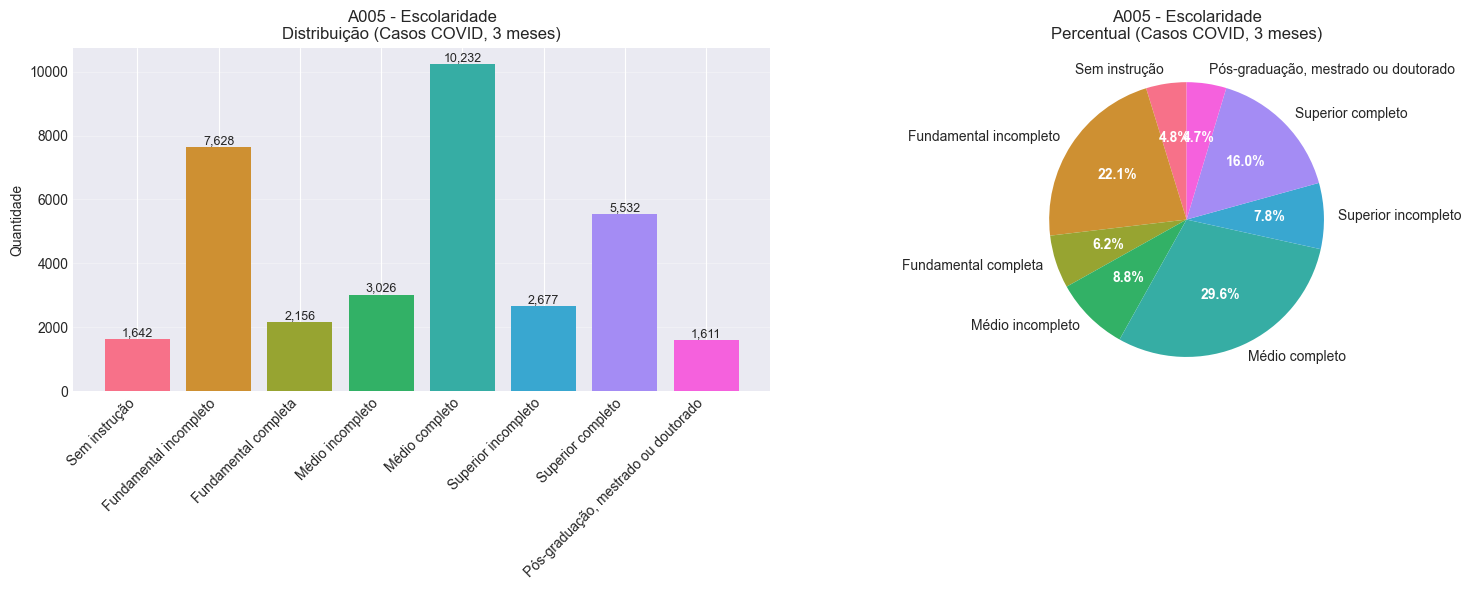

                               Label  Quantidade  Percentual
                       Sem instrução        1642        4.76
              Fundamental incompleto        7628       22.11
                Fundamental completa        2156        6.25
                    Médio incompleto        3026        8.77
                      Médio completo       10232       29.65
                 Superior incompleto        2677        7.76
                   Superior completo        5532       16.03
Pós-graduação, mestrado ou doutorado        1611        4.67

################################################################################
Item 2/53: B0011
################################################################################


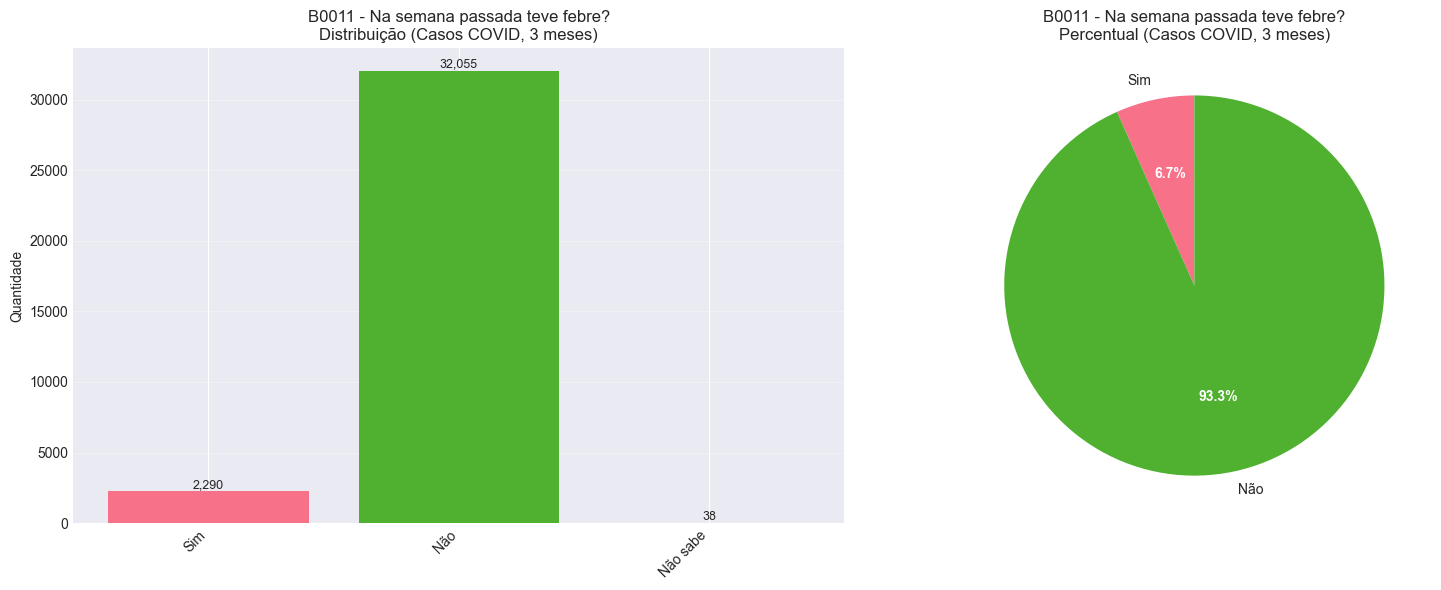

   Label  Quantidade  Percentual
     Sim        2290        6.64
     Não       32055       92.90
Não sabe          38        0.11

################################################################################
Item 3/53: B0012
################################################################################


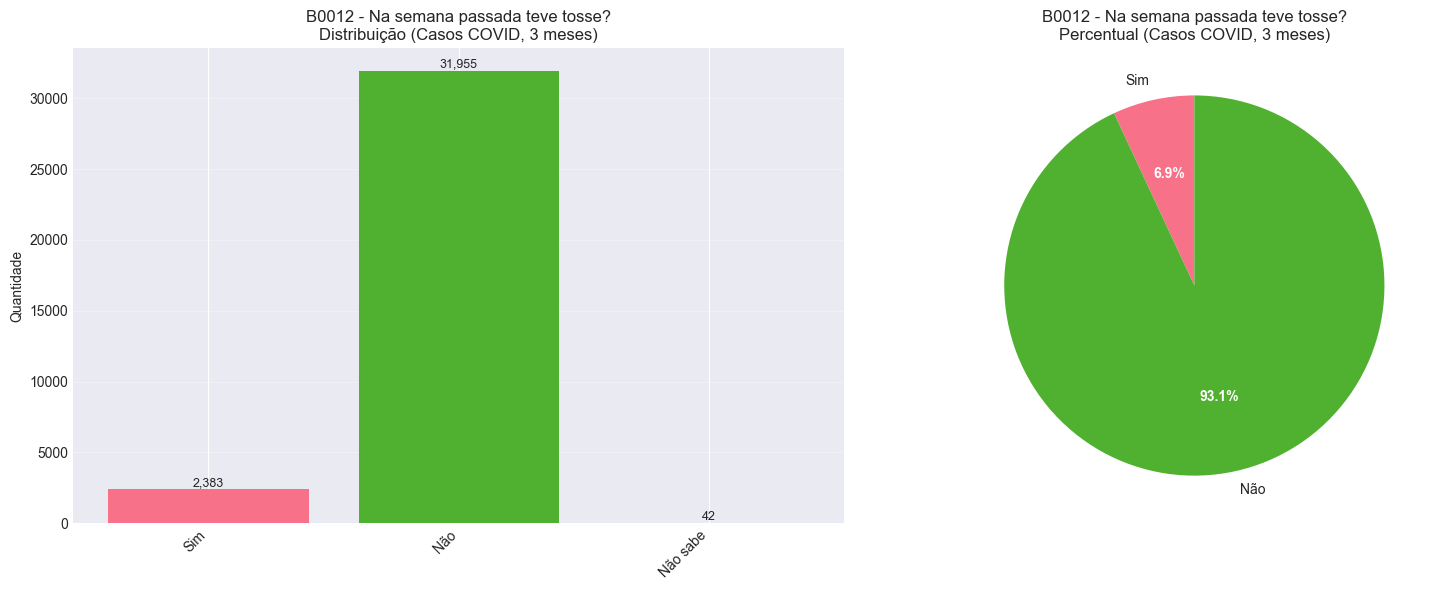

   Label  Quantidade  Percentual
     Sim        2383        6.91
     Não       31955       92.61
Não sabe          42        0.12

################################################################################
Item 4/53: B0013
################################################################################


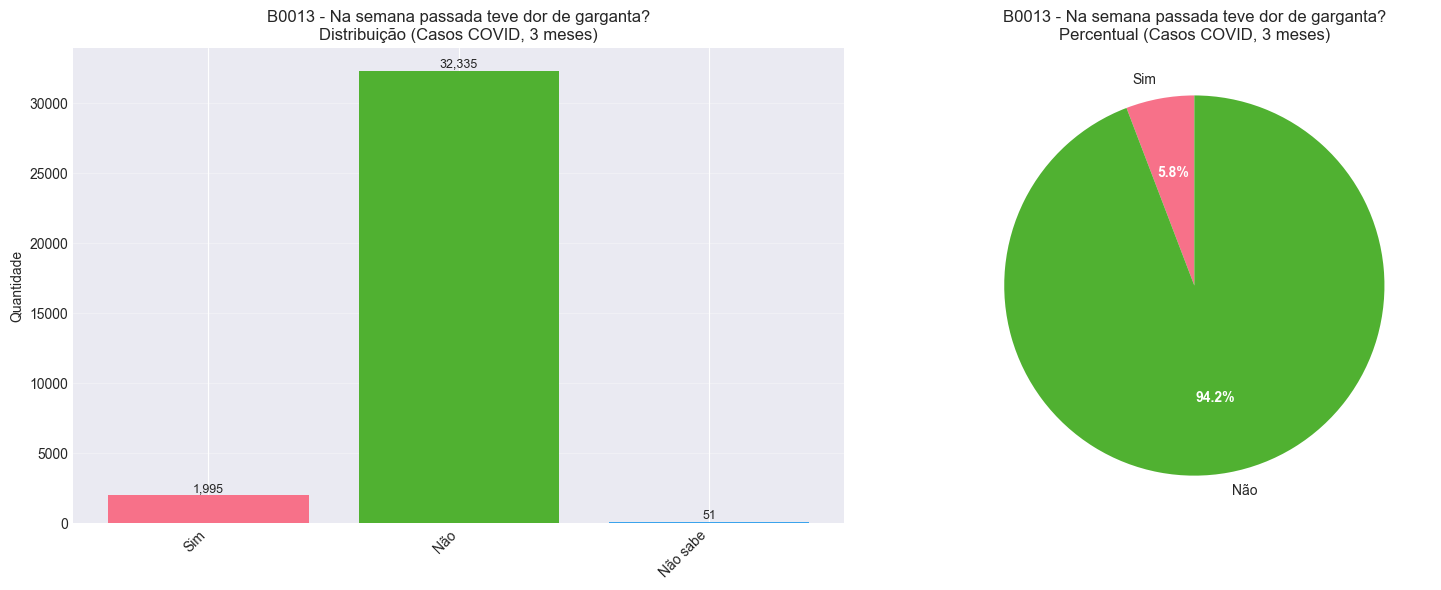

   Label  Quantidade  Percentual
     Sim        1995        5.78
     Não       32335       93.71
Não sabe          51        0.15

################################################################################
Item 5/53: B0014
################################################################################


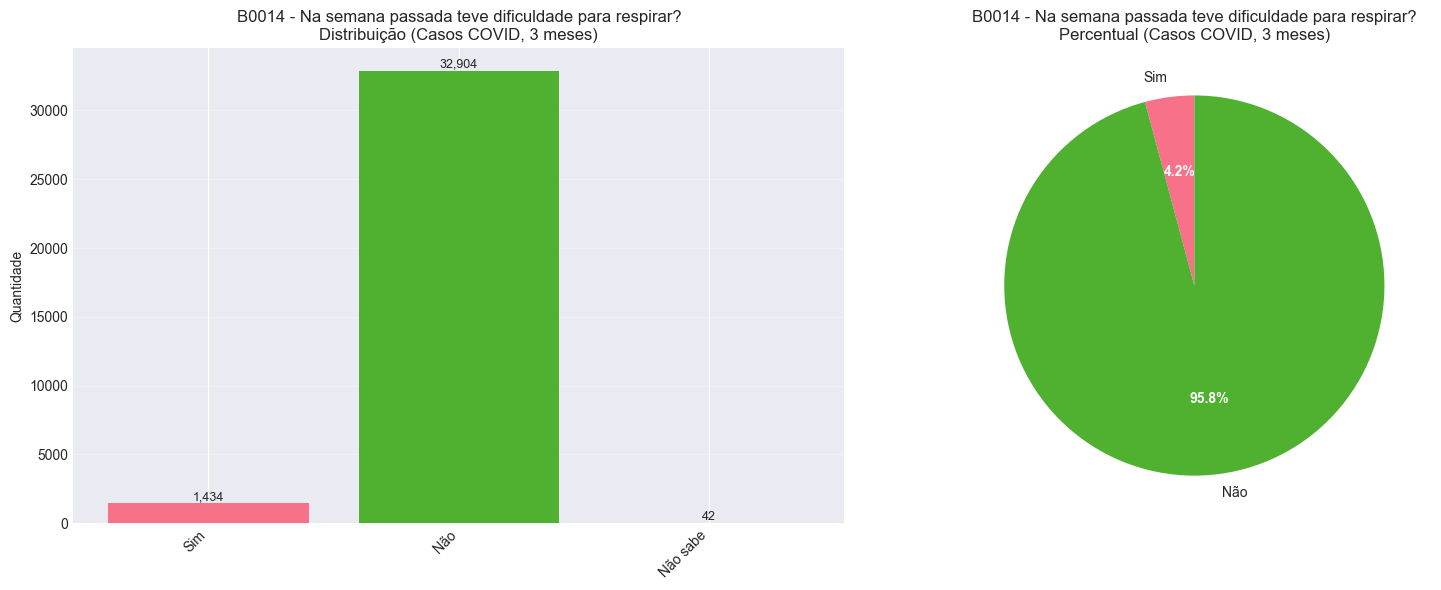

   Label  Quantidade  Percentual
     Sim        1434        4.16
     Não       32904       95.36
Não sabe          42        0.12

################################################################################
Item 6/53: B0015
################################################################################


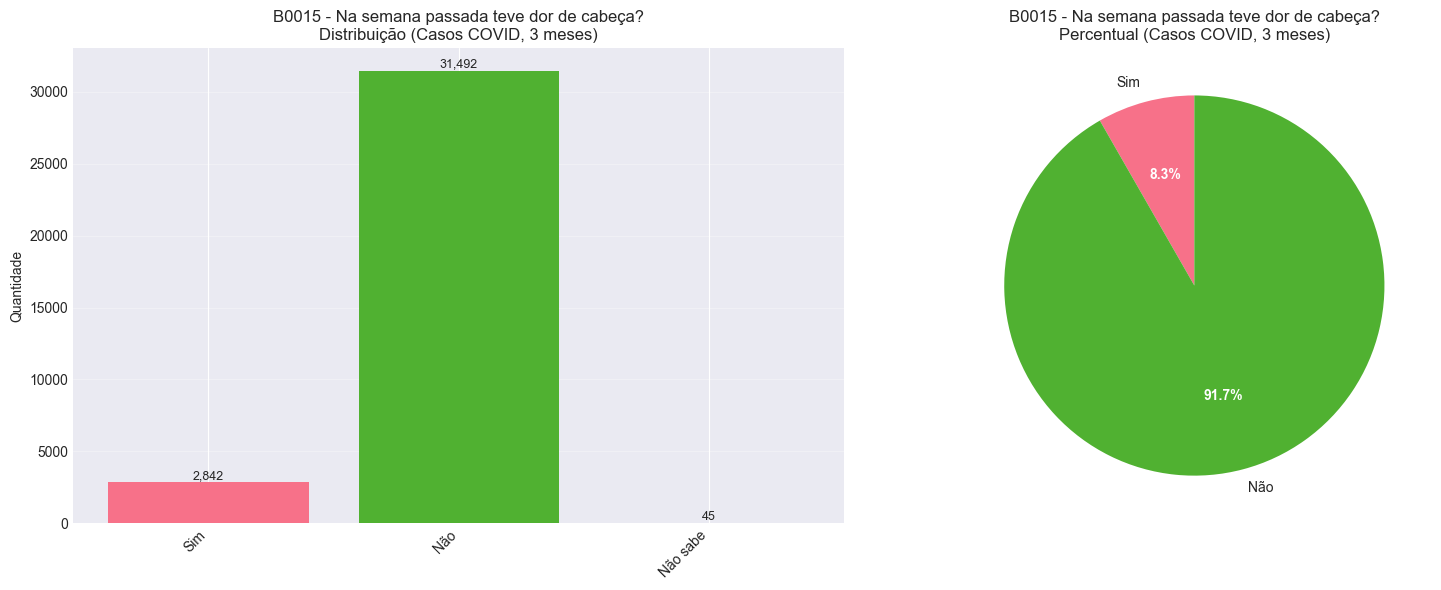

   Label  Quantidade  Percentual
     Sim        2842        8.24
     Não       31492       91.27
Não sabe          45        0.13

################################################################################
Item 7/53: B0016
################################################################################


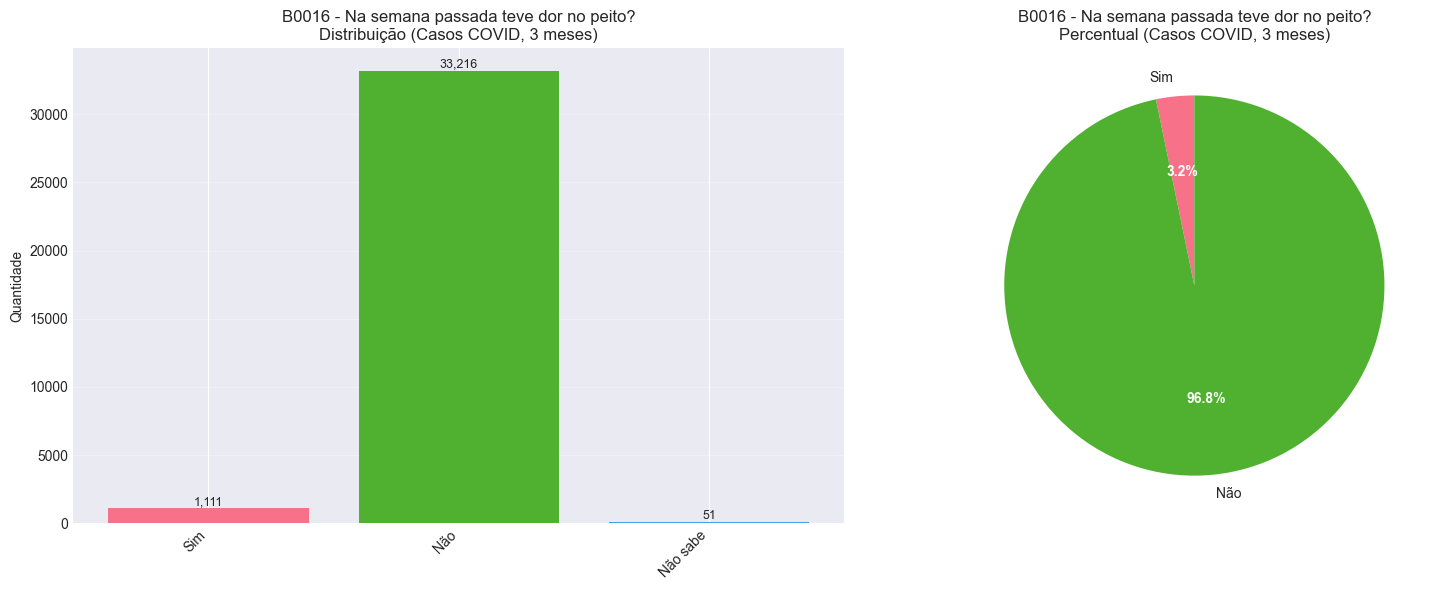

   Label  Quantidade  Percentual
     Sim        1111        3.22
     Não       33216       96.27
Não sabe          51        0.15

################################################################################
Item 8/53: B0017
################################################################################


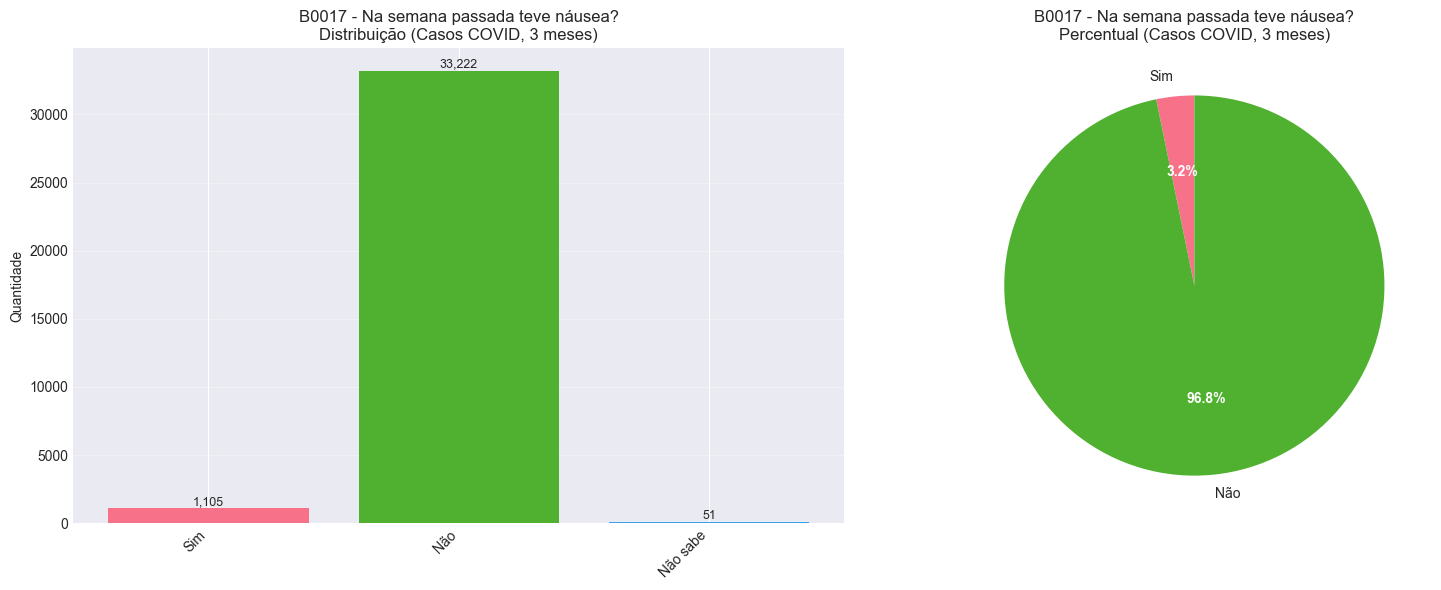

   Label  Quantidade  Percentual
     Sim        1105        3.20
     Não       33222       96.28
Não sabe          51        0.15

################################################################################
Item 9/53: B0018
################################################################################


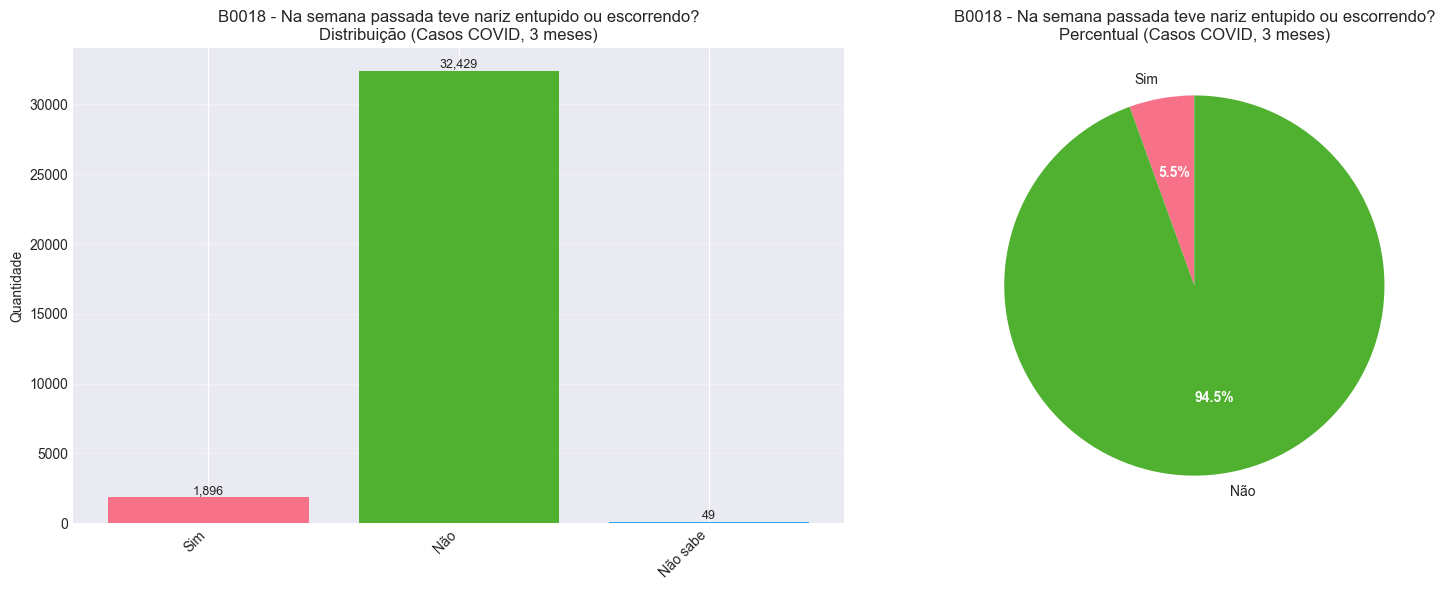

   Label  Quantidade  Percentual
     Sim        1896        5.50
     Não       32429       93.99
Não sabe          49        0.14

################################################################################
Item 10/53: B0019
################################################################################


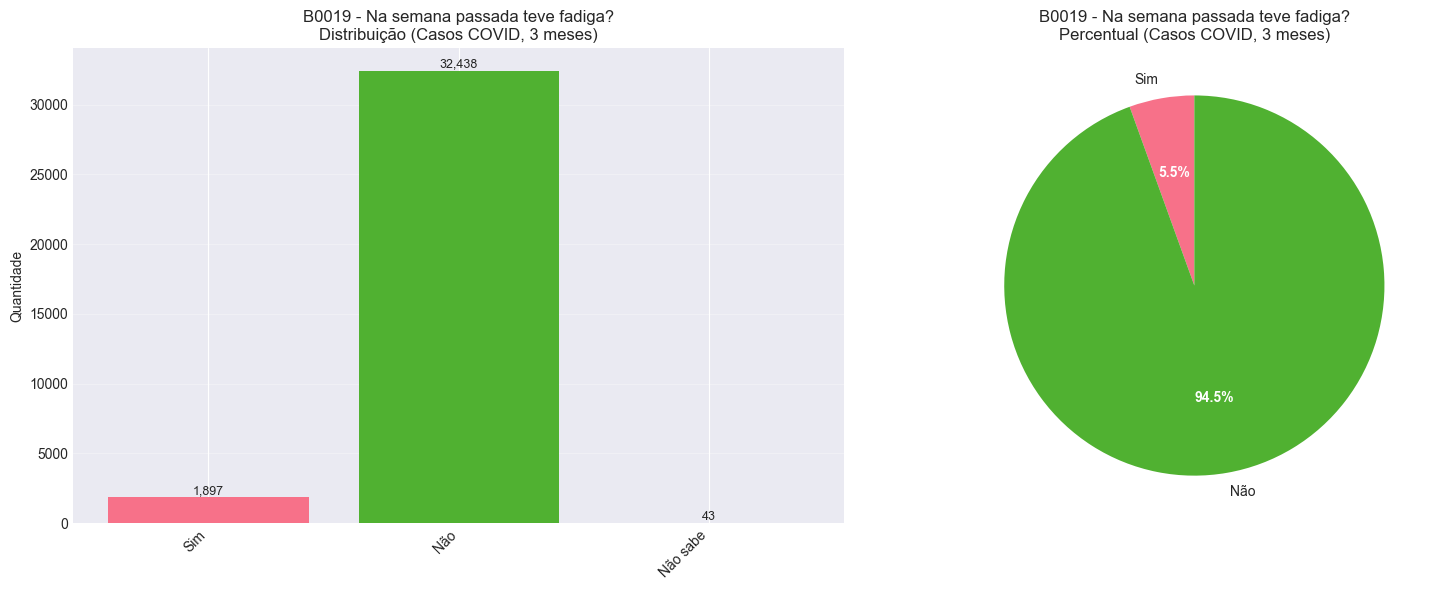

   Label  Quantidade  Percentual
     Sim        1897        5.50
     Não       32438       94.01
Não sabe          43        0.12

################################################################################
Item 11/53: B00110
################################################################################


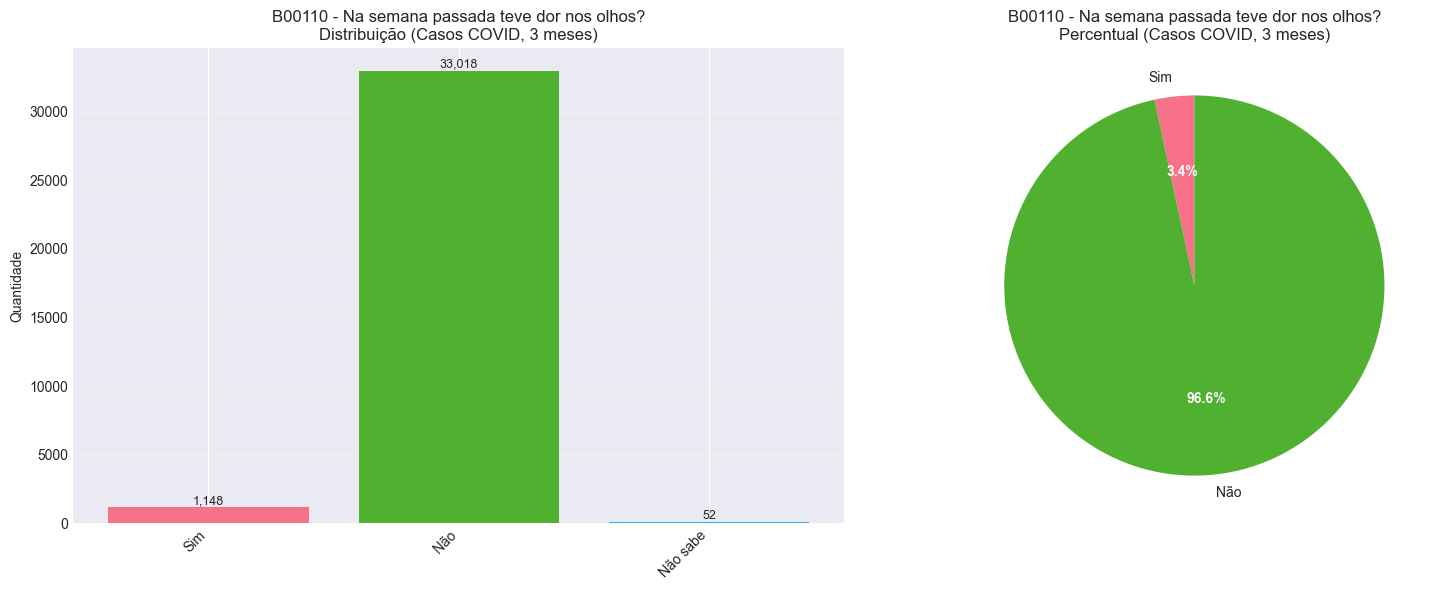

   Label  Quantidade  Percentual
     Sim        1148        3.33
     Não       33018       95.69
Não sabe          52        0.15

################################################################################
Item 12/53: B00111
################################################################################


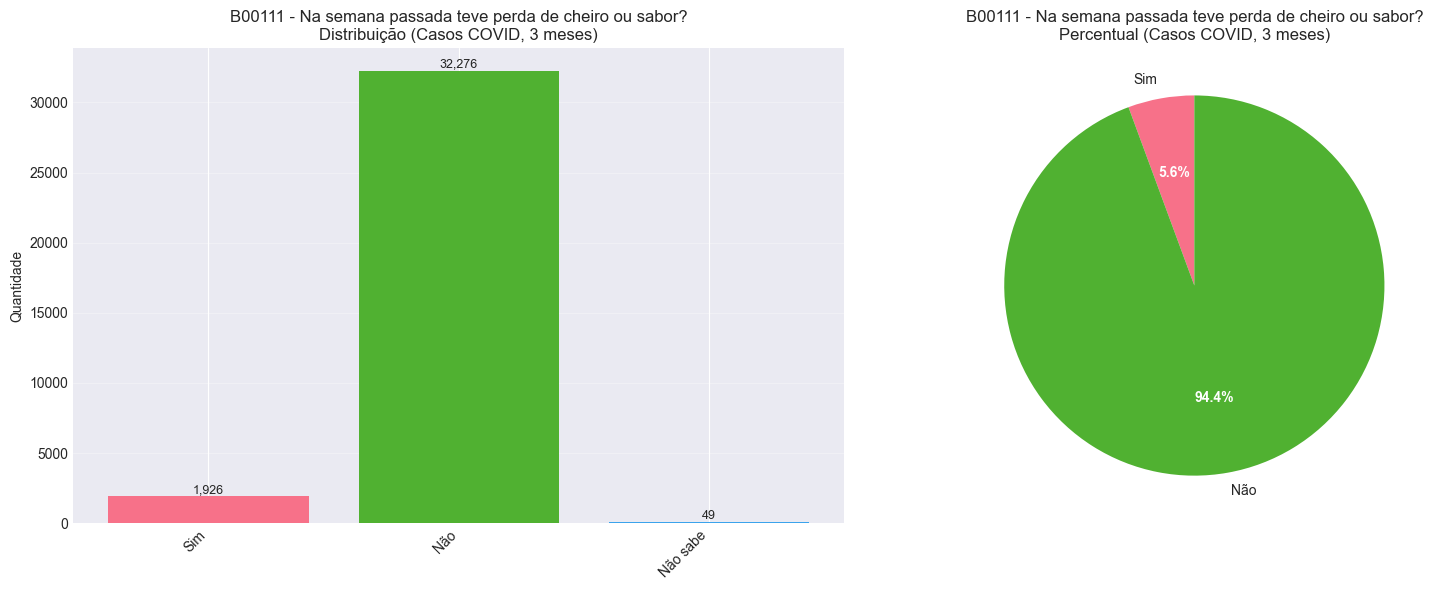

   Label  Quantidade  Percentual
     Sim        1926        5.58
     Não       32276       93.54
Não sabe          49        0.14

################################################################################
Item 13/53: B00112
################################################################################


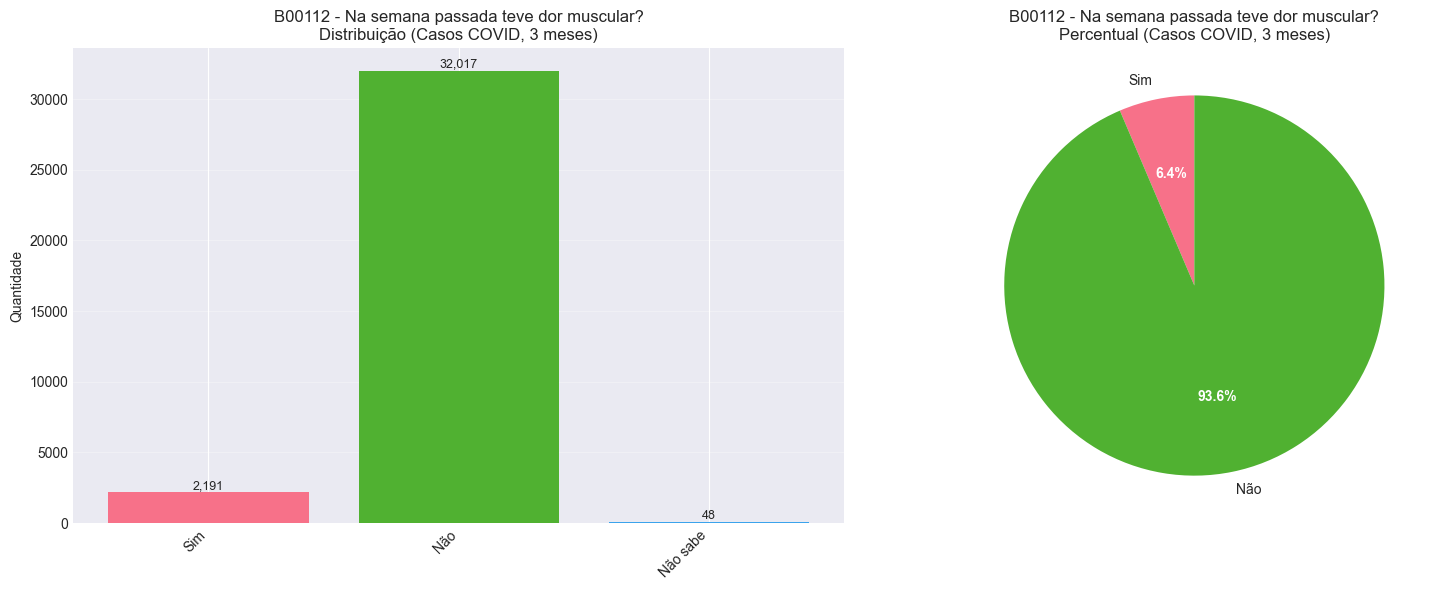

   Label  Quantidade  Percentual
     Sim        2191        6.35
     Não       32017       92.79
Não sabe          48        0.14

################################################################################
Item 14/53: B00113
################################################################################


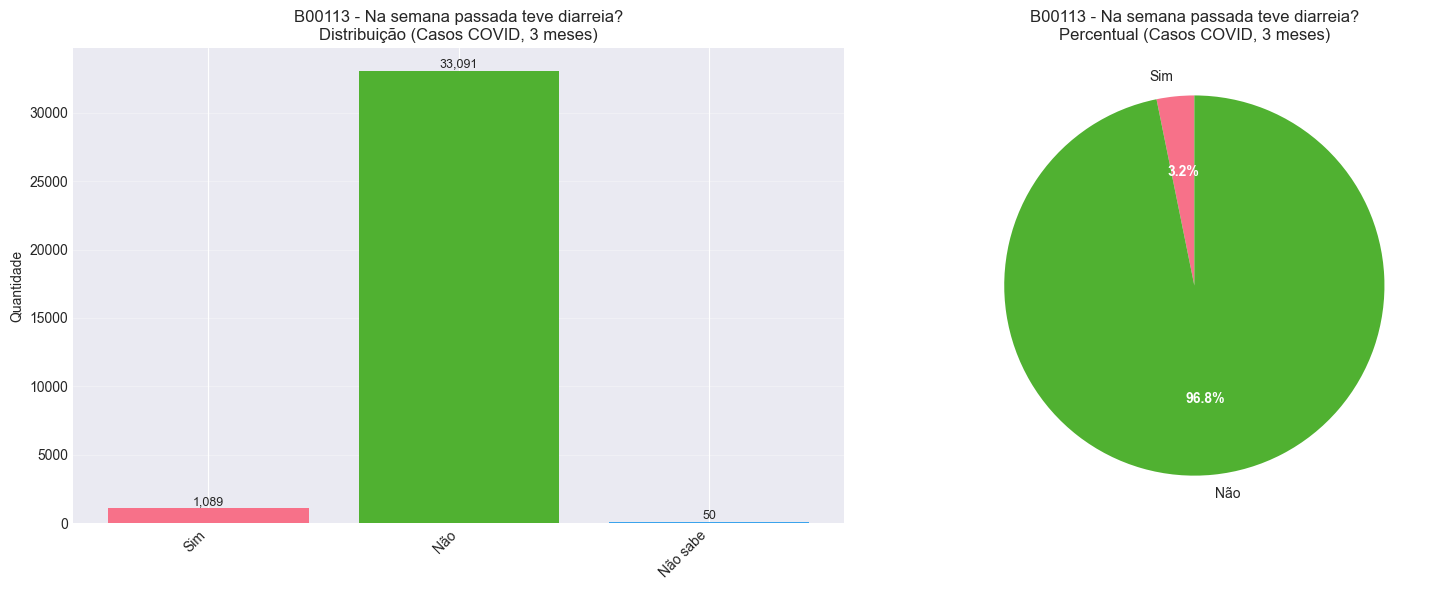

   Label  Quantidade  Percentual
     Sim        1089        3.16
     Não       33091       95.90
Não sabe          50        0.14

################################################################################
Item 15/53: B002
################################################################################


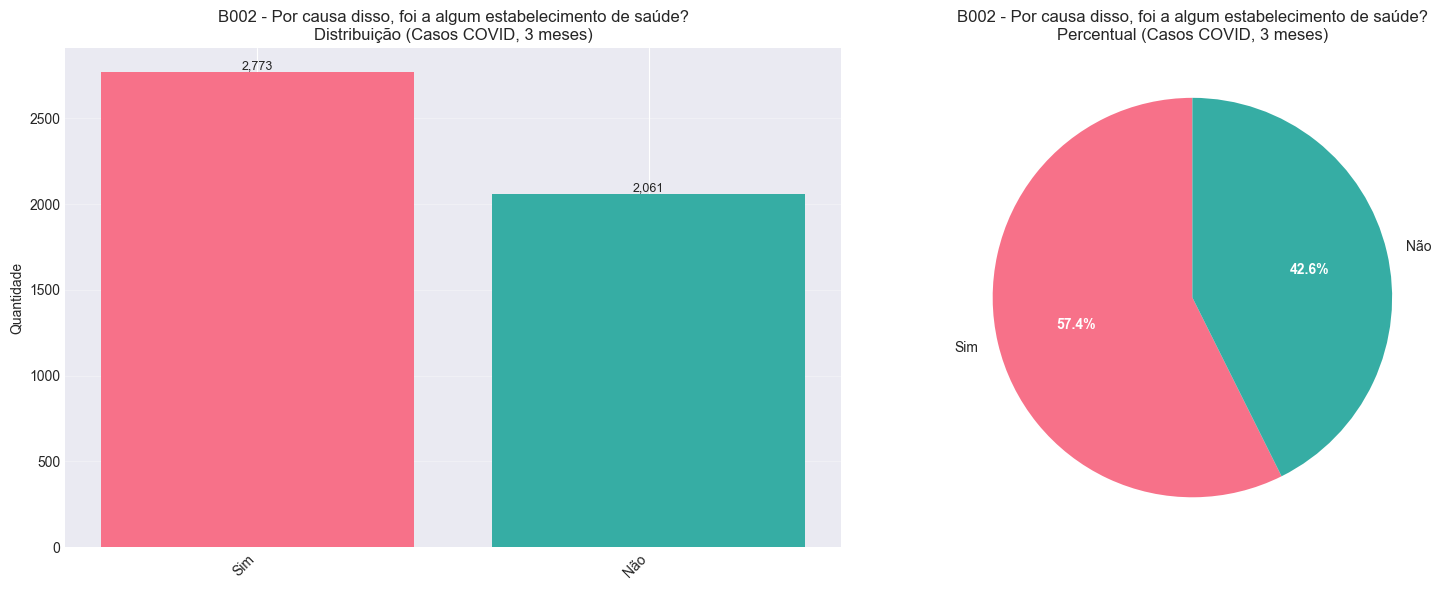

Label  Quantidade  Percentual
  Sim        2773       57.28
  Não        2061       42.57

################################################################################
Item 16/53: B0031
################################################################################


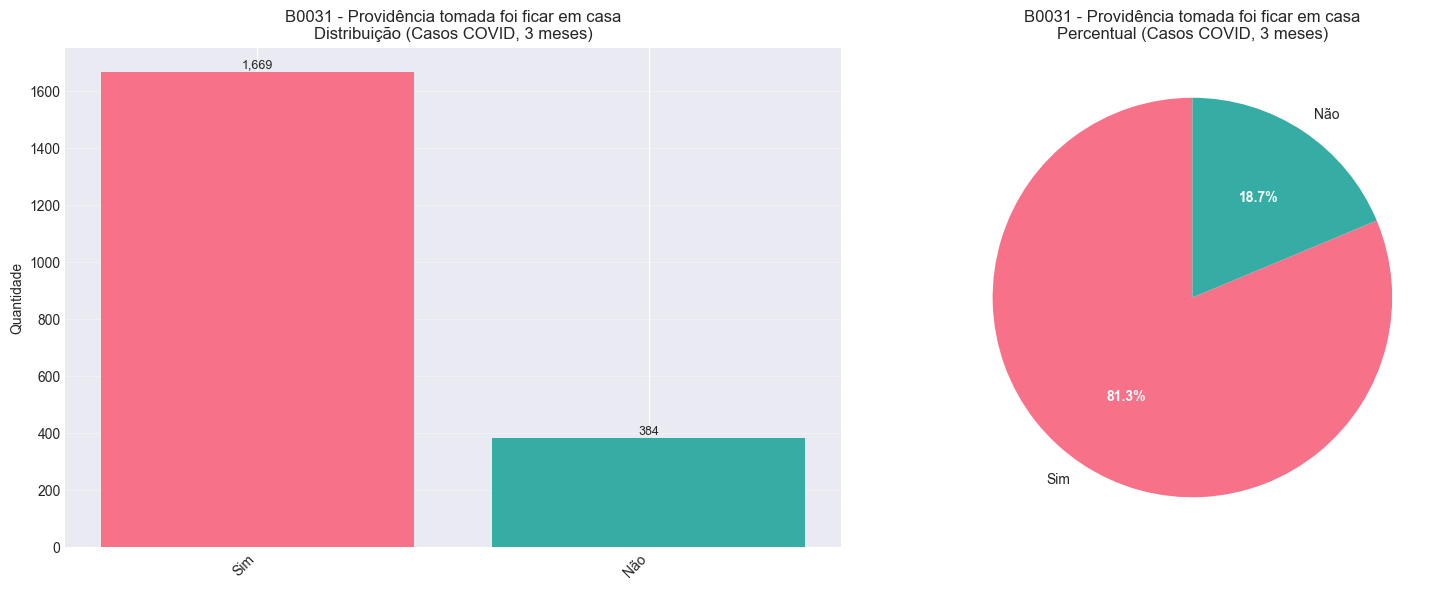

Label  Quantidade  Percentual
  Sim        1669       80.98
  Não         384       18.63

################################################################################
Item 17/53: B0041
################################################################################


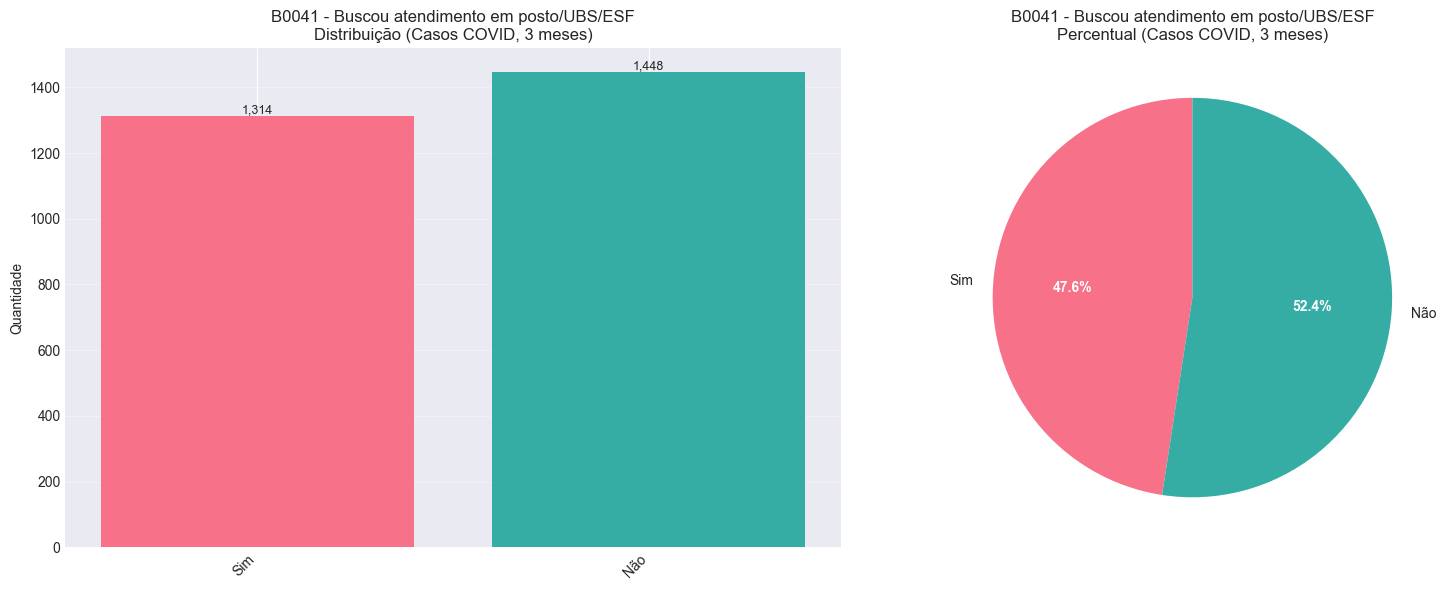

Label  Quantidade  Percentual
  Sim        1314       47.39
  Não        1448       52.22

################################################################################
Item 18/53: B0042
################################################################################


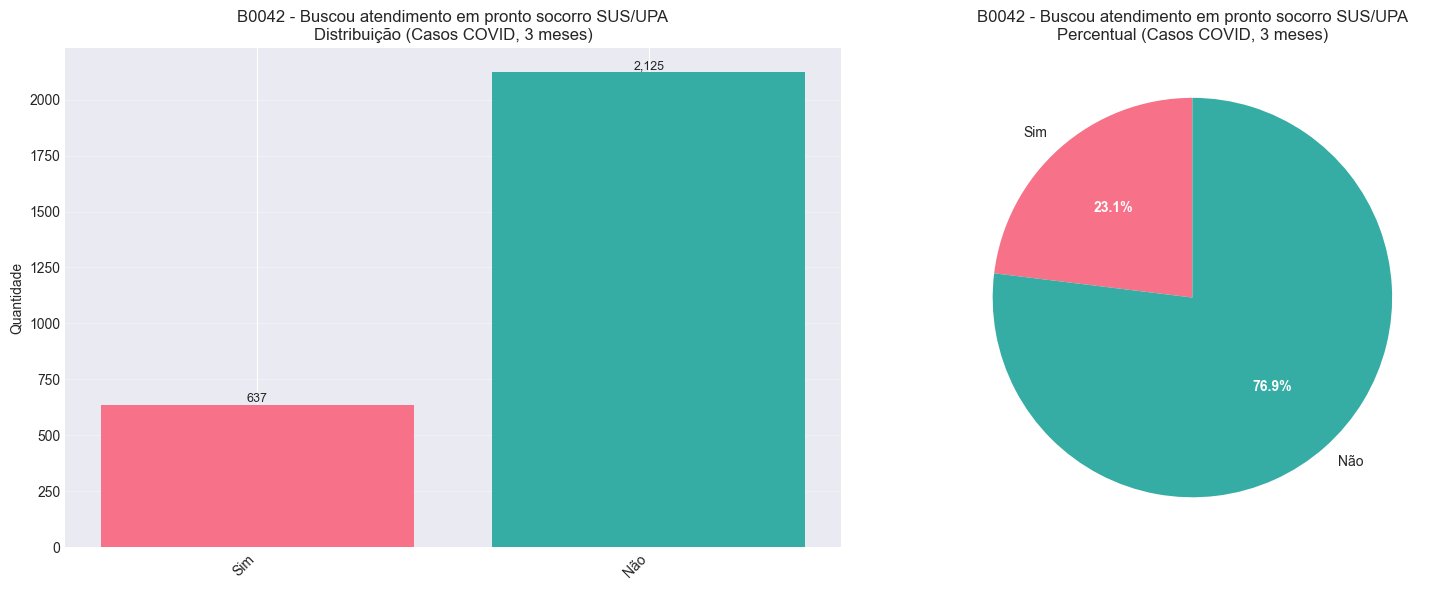

Label  Quantidade  Percentual
  Sim         637       22.97
  Não        2125       76.63

################################################################################
Item 19/53: B0043
################################################################################


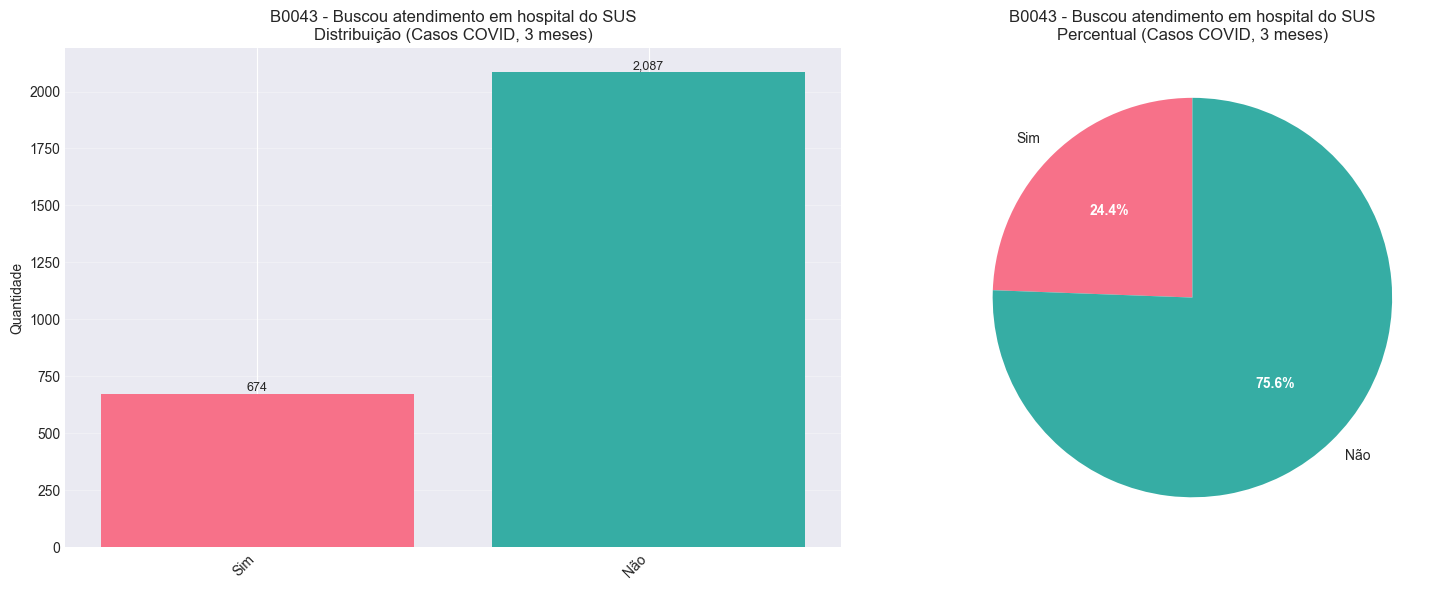

Label  Quantidade  Percentual
  Sim         674       24.31
  Não        2087       75.26

################################################################################
Item 20/53: B0044
################################################################################


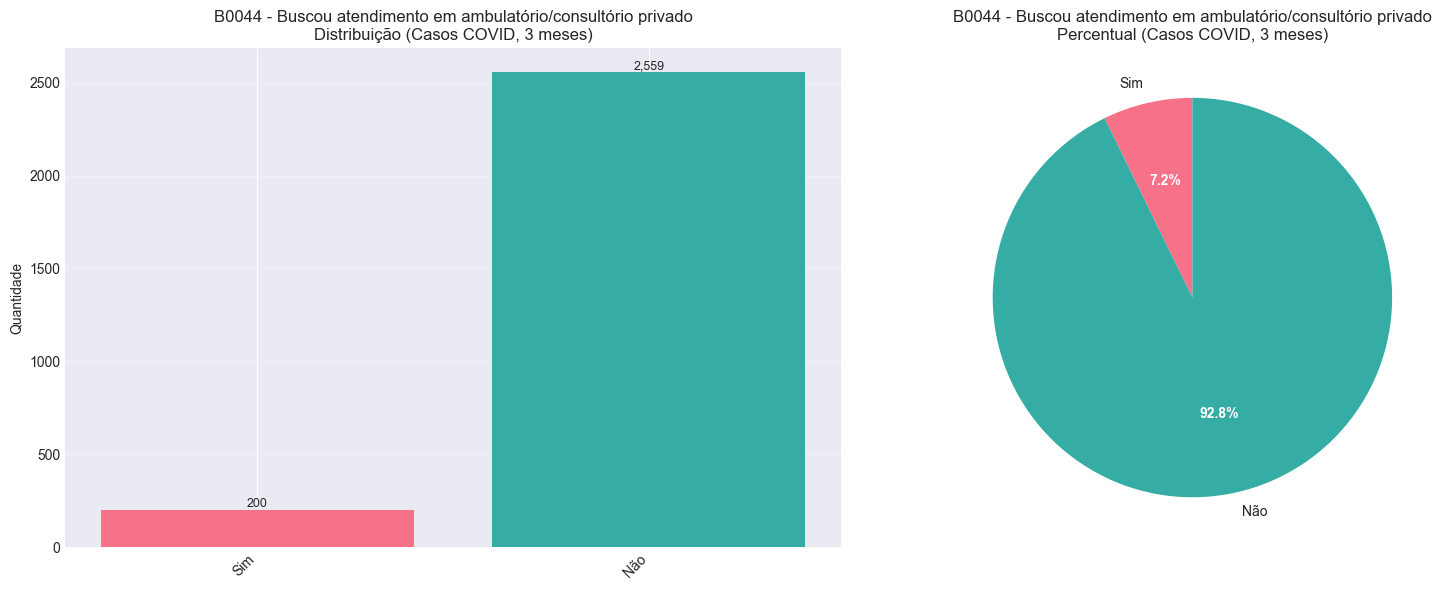

Label  Quantidade  Percentual
  Sim         200        7.21
  Não        2559       92.28

################################################################################
Item 21/53: B0045
################################################################################


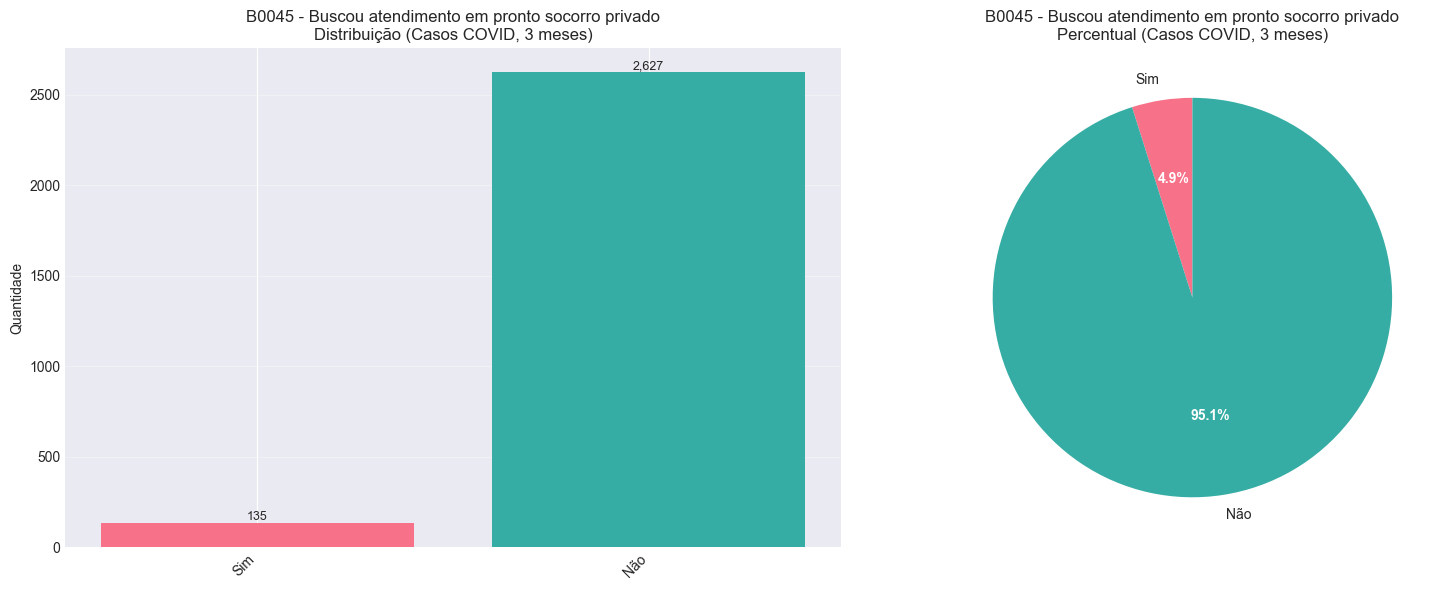

Label  Quantidade  Percentual
  Sim         135        4.87
  Não        2627       94.73

################################################################################
Item 22/53: B0046
################################################################################


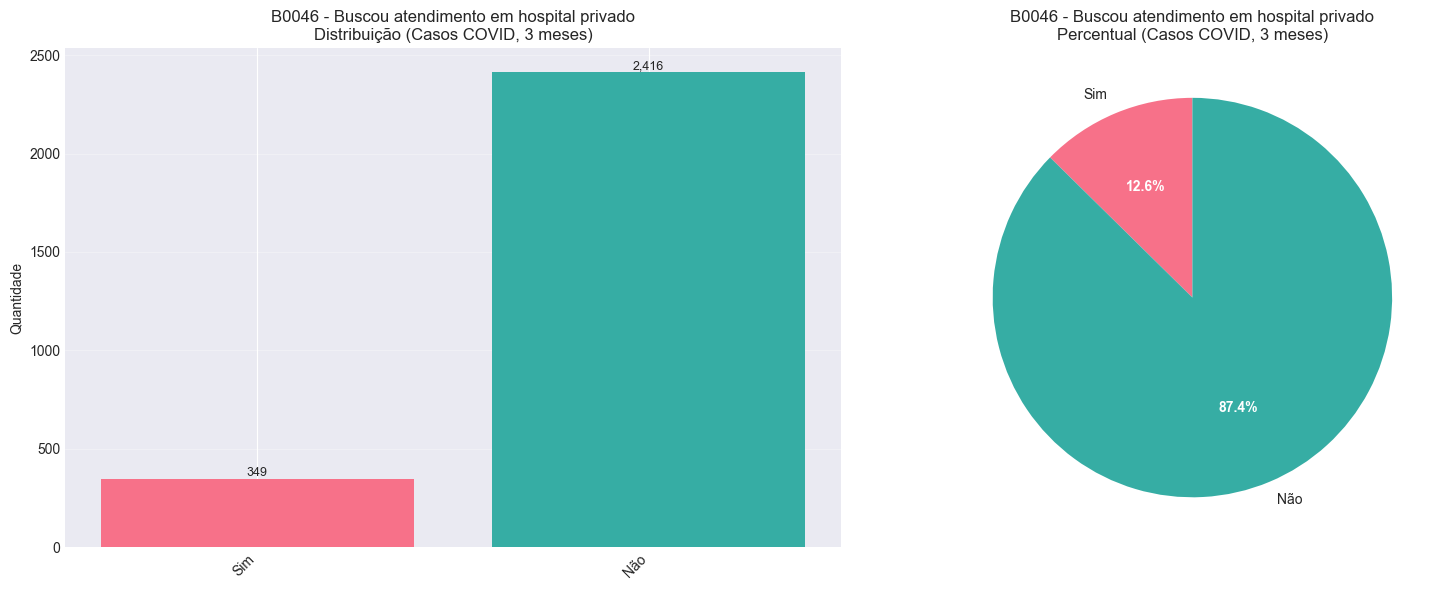

Label  Quantidade  Percentual
  Sim         349       12.59
  Não        2416       87.13

################################################################################
Item 23/53: B005
################################################################################


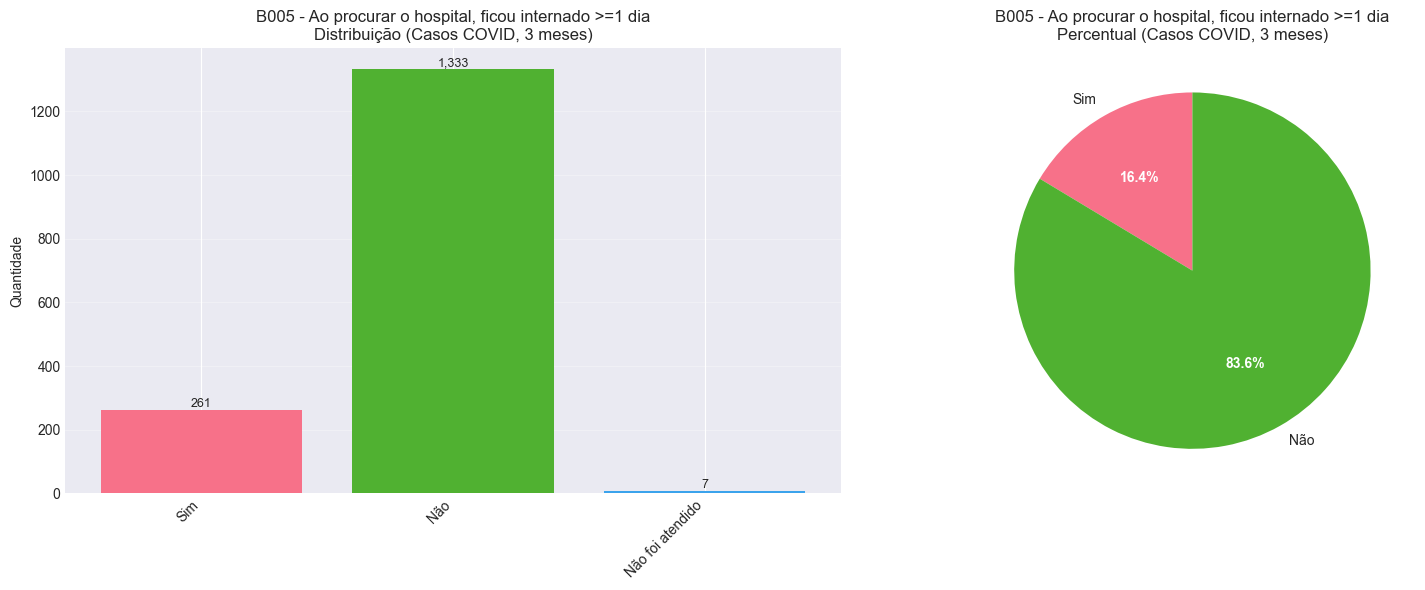

           Label  Quantidade  Percentual
             Sim         261       16.29
             Não        1333       83.21
Não foi atendido           7        0.44

################################################################################
Item 24/53: B006
################################################################################


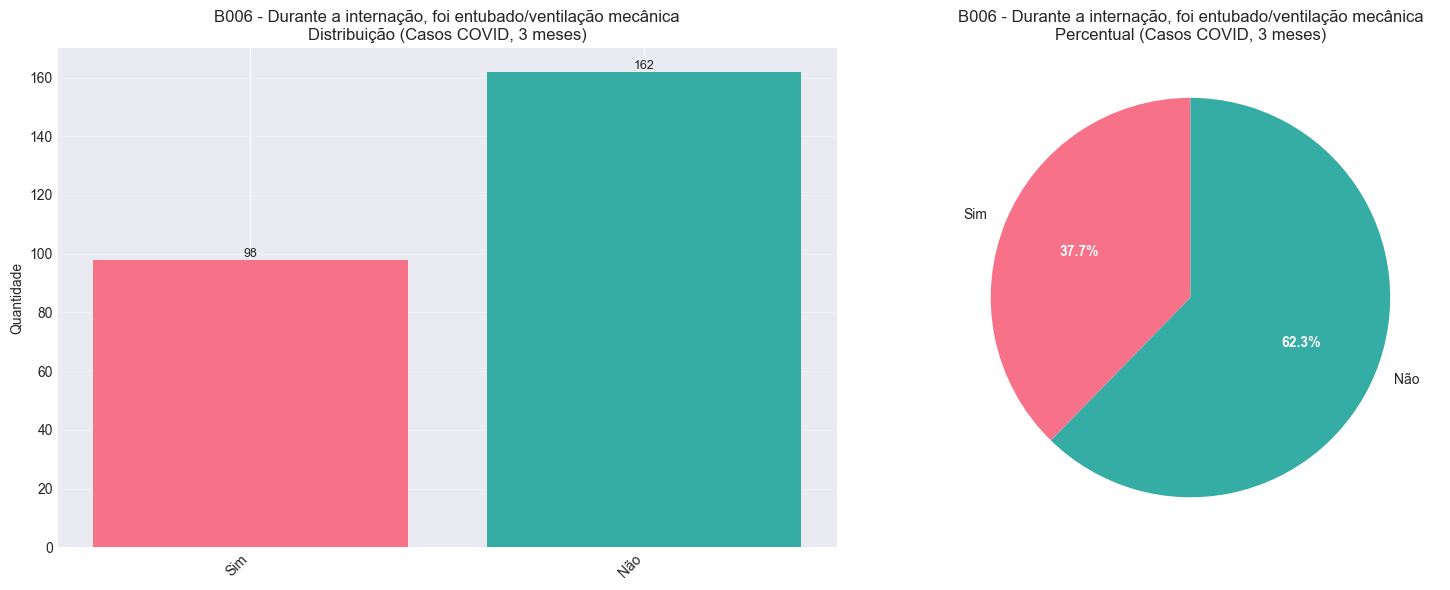

Label  Quantidade  Percentual
  Sim          98       37.55
  Não         162       62.07

################################################################################
Item 25/53: B008
################################################################################


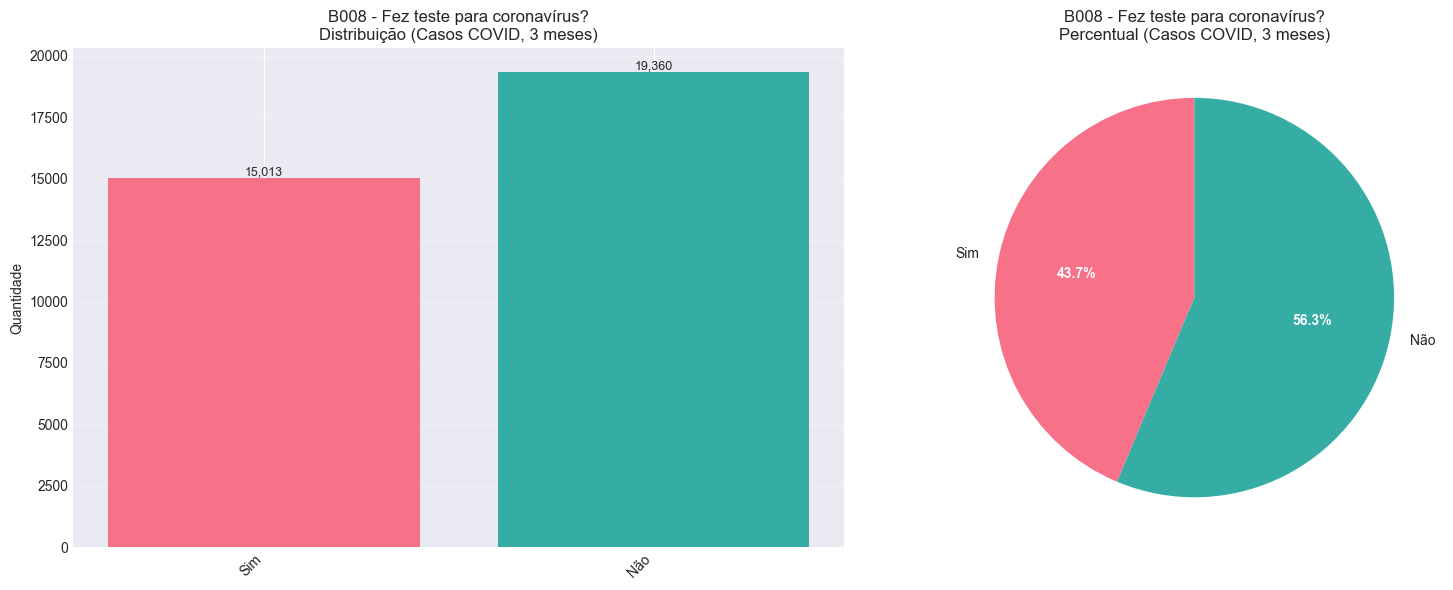

Label  Quantidade  Percentual
  Sim       15013       43.51
  Não       19360       56.11

################################################################################
Item 26/53: B0101
################################################################################


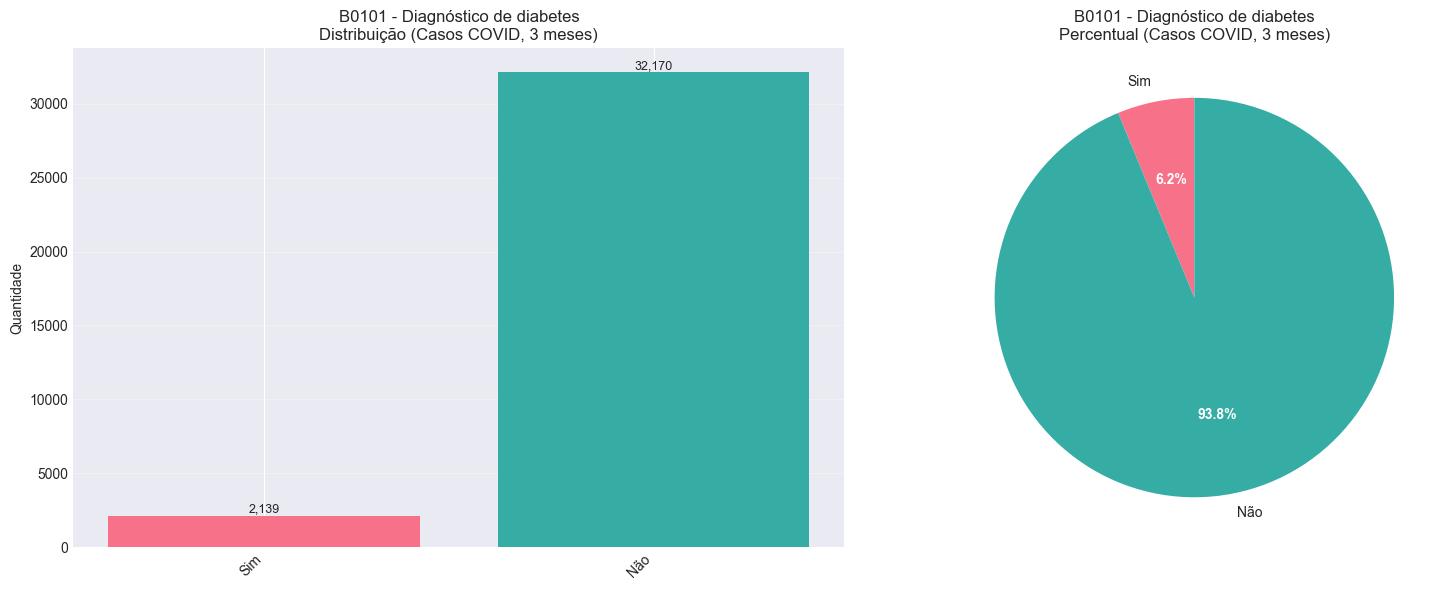

Label  Quantidade  Percentual
  Sim        2139        6.20
  Não       32170       93.24

################################################################################
Item 27/53: B0102
################################################################################


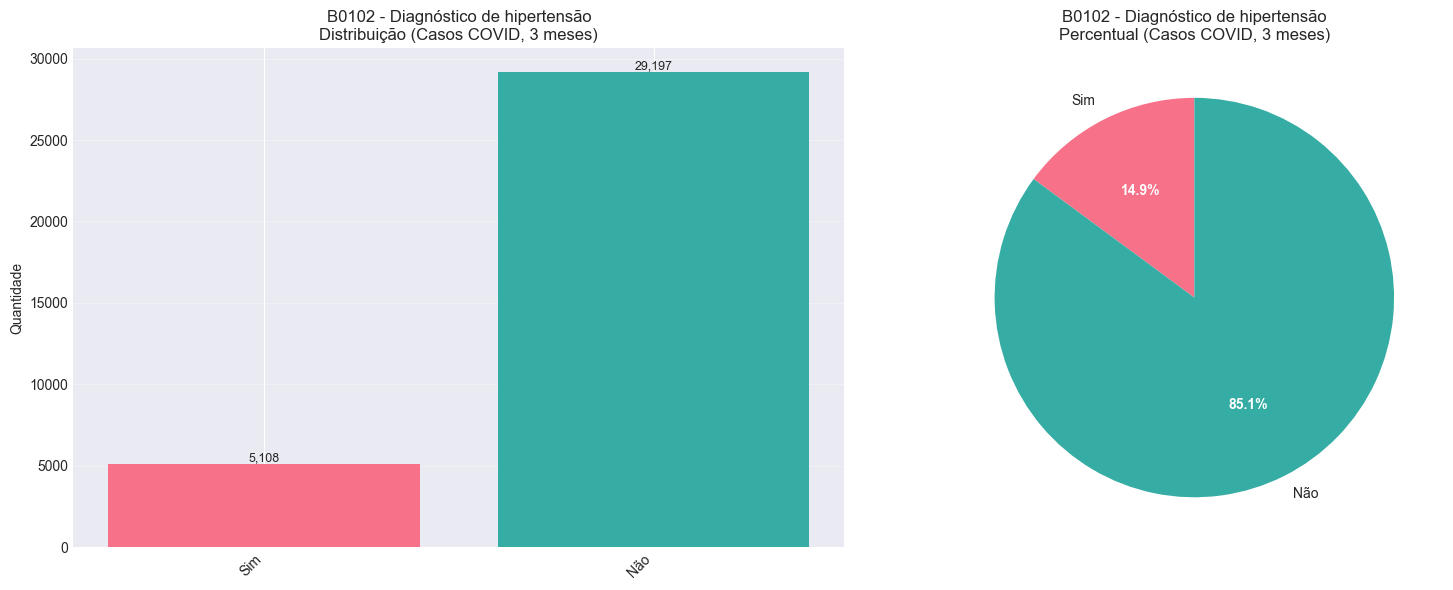

Label  Quantidade  Percentual
  Sim        5108       14.80
  Não       29197       84.62

################################################################################
Item 28/53: B0103
################################################################################


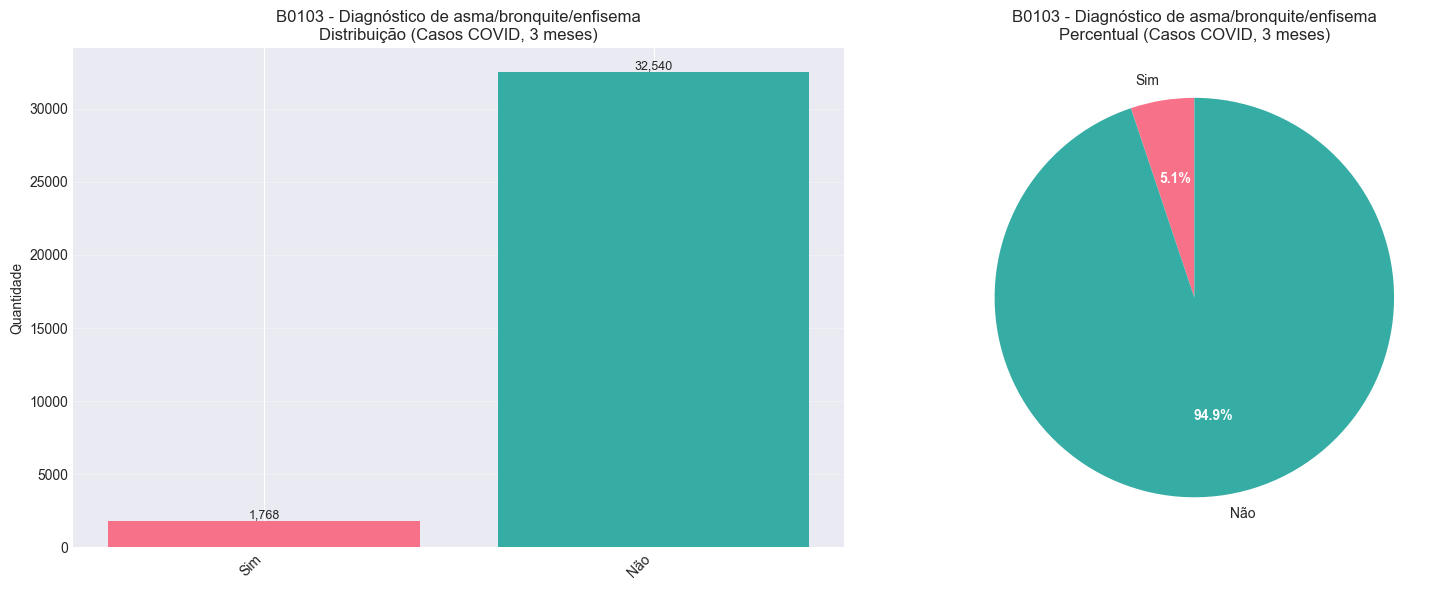

Label  Quantidade  Percentual
  Sim        1768        5.12
  Não       32540       94.31

################################################################################
Item 29/53: B0104
################################################################################


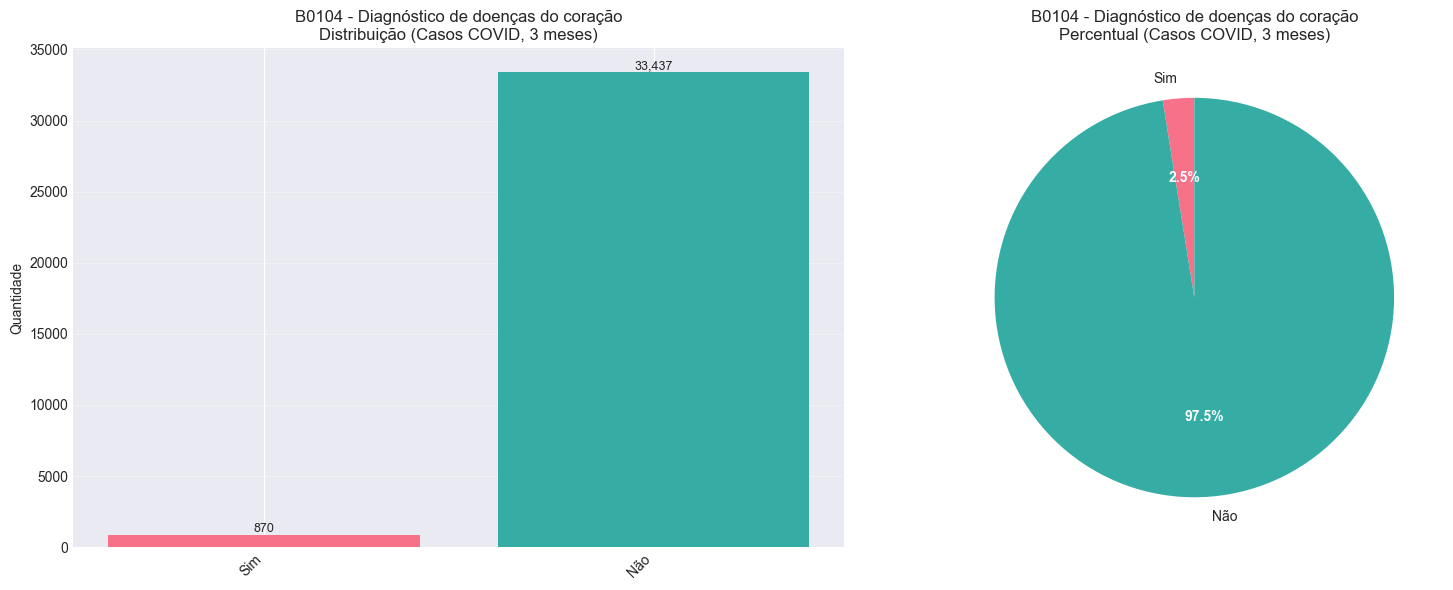

Label  Quantidade  Percentual
  Sim         870        2.52
  Não       33437       96.91

################################################################################
Item 30/53: B0105
################################################################################


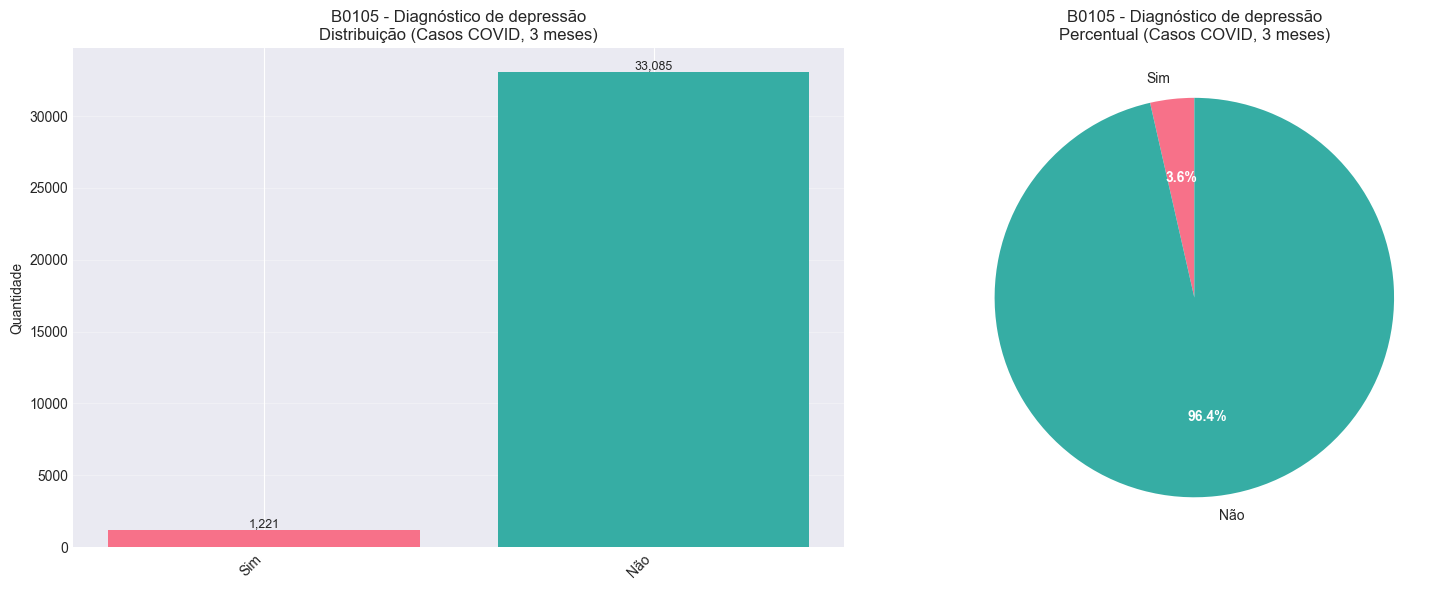

Label  Quantidade  Percentual
  Sim        1221        3.54
  Não       33085       95.89

################################################################################
Item 31/53: B0106
################################################################################


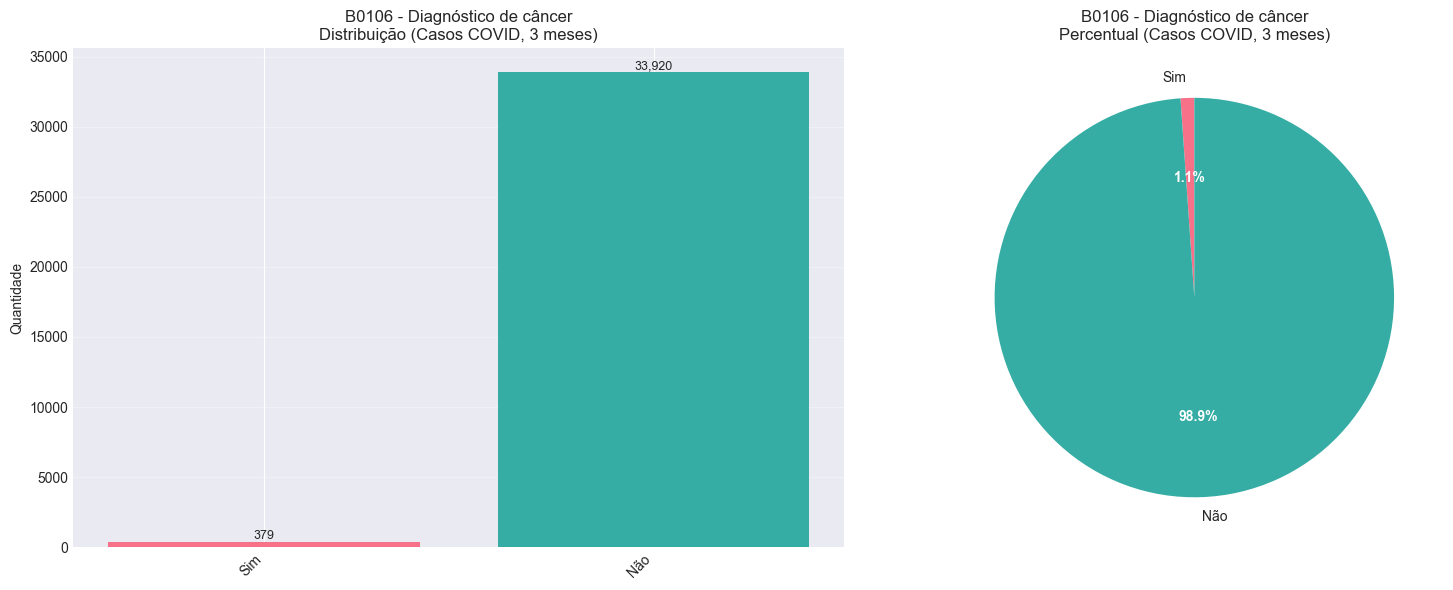

Label  Quantidade  Percentual
  Sim         379        1.10
  Não       33920       98.31

################################################################################
Item 32/53: B011
################################################################################


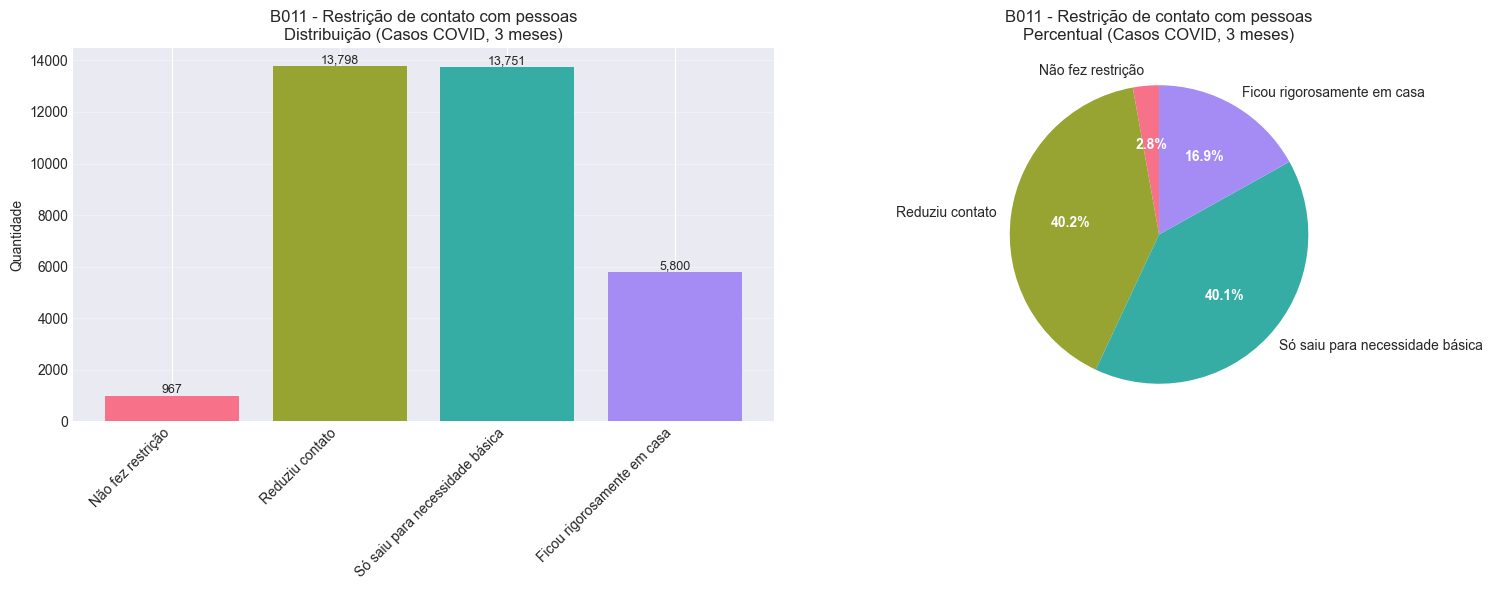

                          Label  Quantidade  Percentual
              Não fez restrição         967        2.80
                Reduziu contato       13798       39.99
Só saiu para necessidade básica       13751       39.85
    Ficou rigorosamente em casa        5800       16.81

################################################################################
Item 33/53: C001
################################################################################


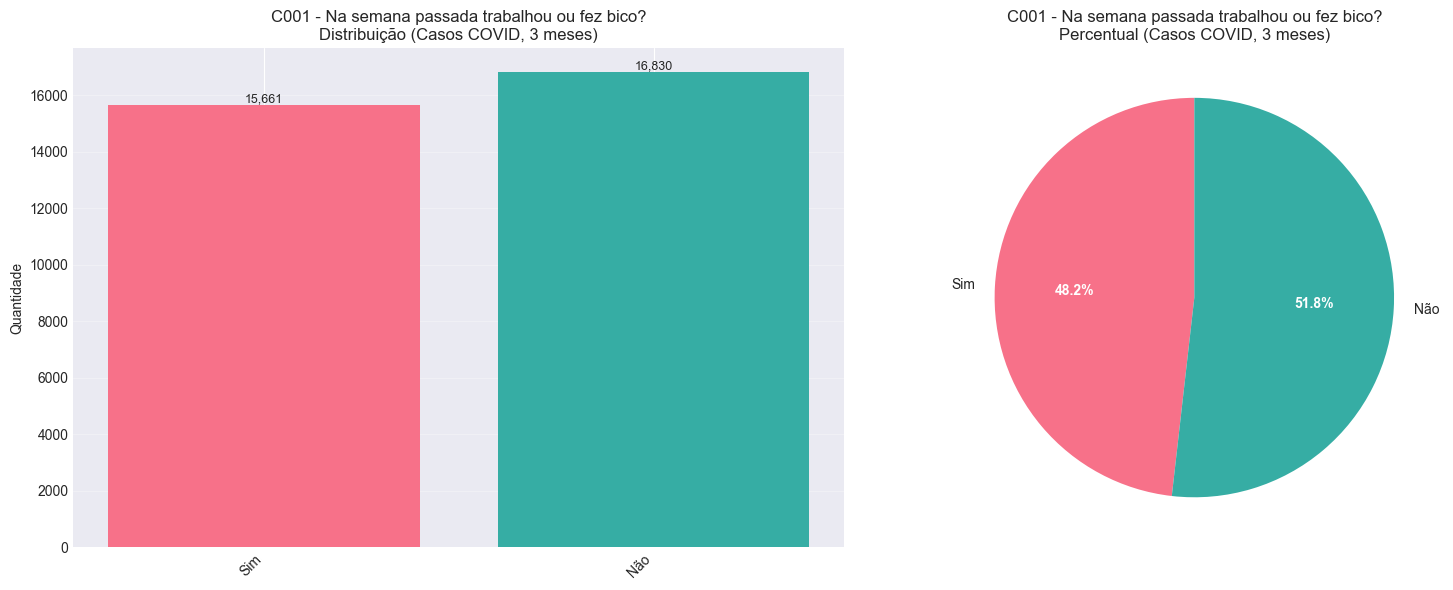

Label  Quantidade  Percentual
  Sim       15661        48.2
  Não       16830        51.8

################################################################################
Item 34/53: C01012
################################################################################


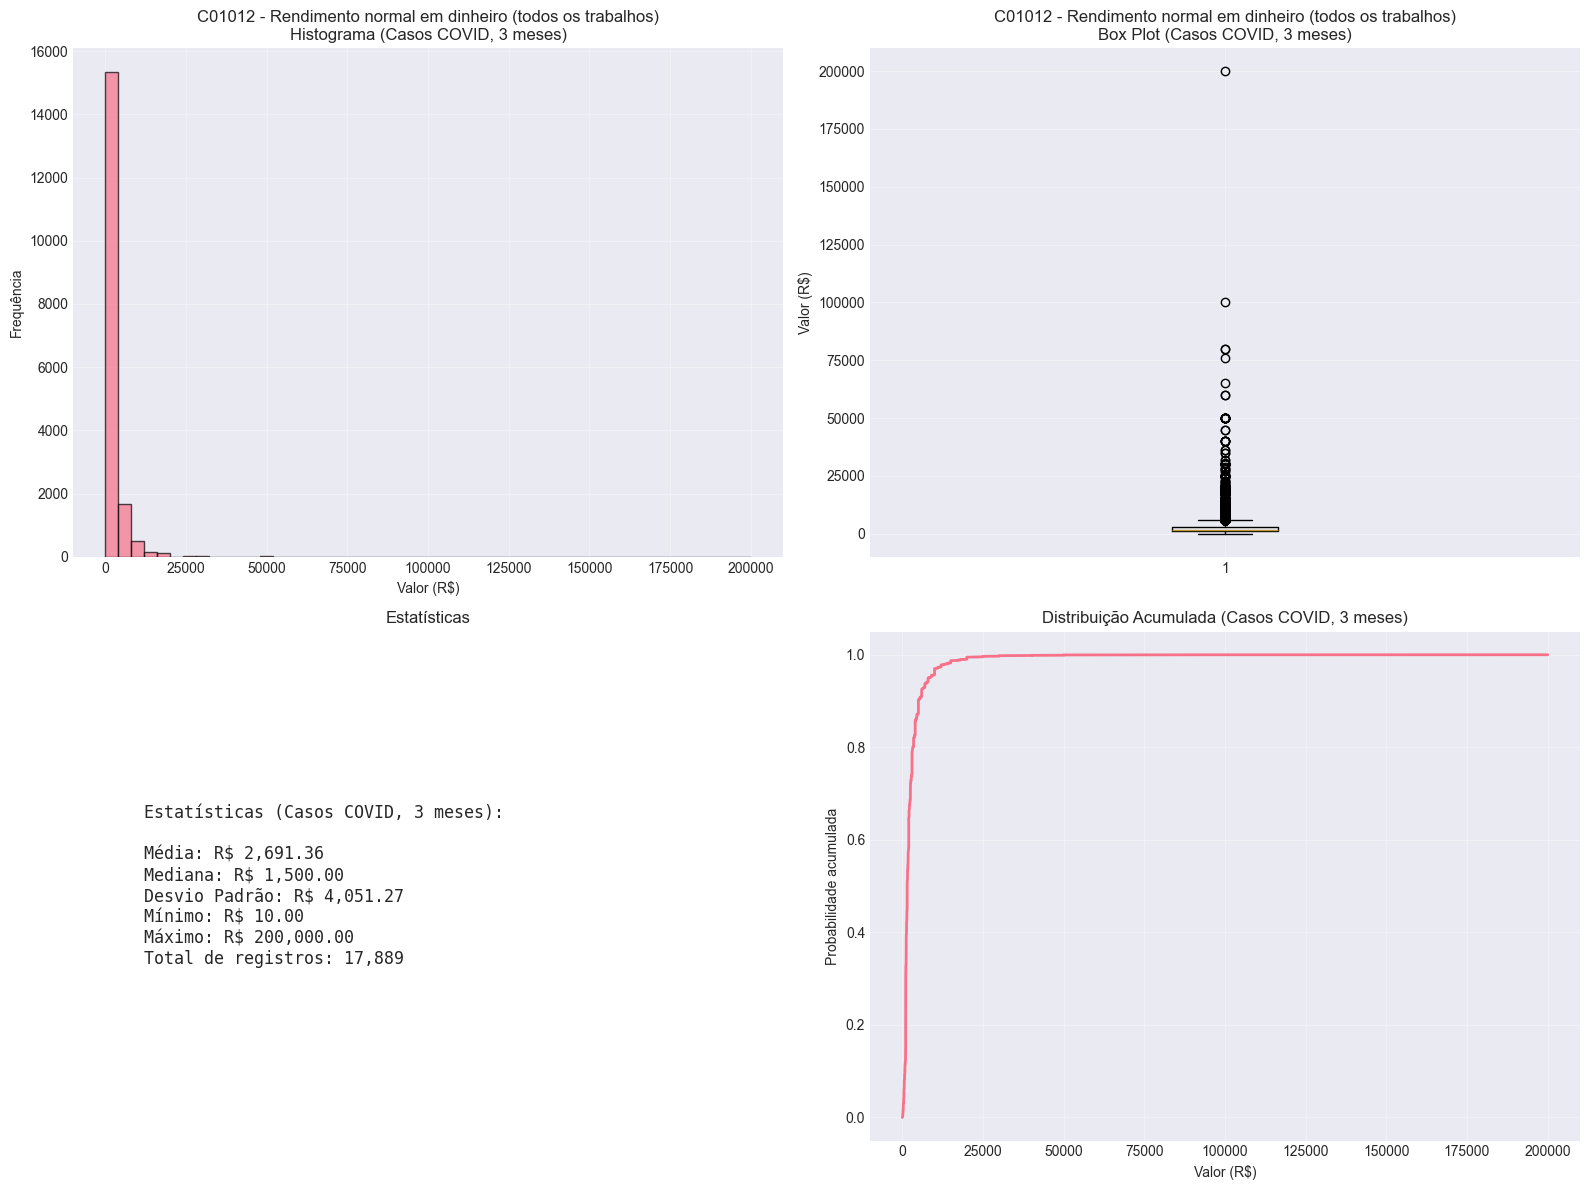

Estatísticas (Casos COVID, 3 meses):

Média: R$ 2,691.36
Mediana: R$ 1,500.00
Desvio Padrão: R$ 4,051.27
Mínimo: R$ 10.00
Máximo: R$ 200,000.00
Total de registros: 17,889

################################################################################
Item 35/53: C01022
################################################################################


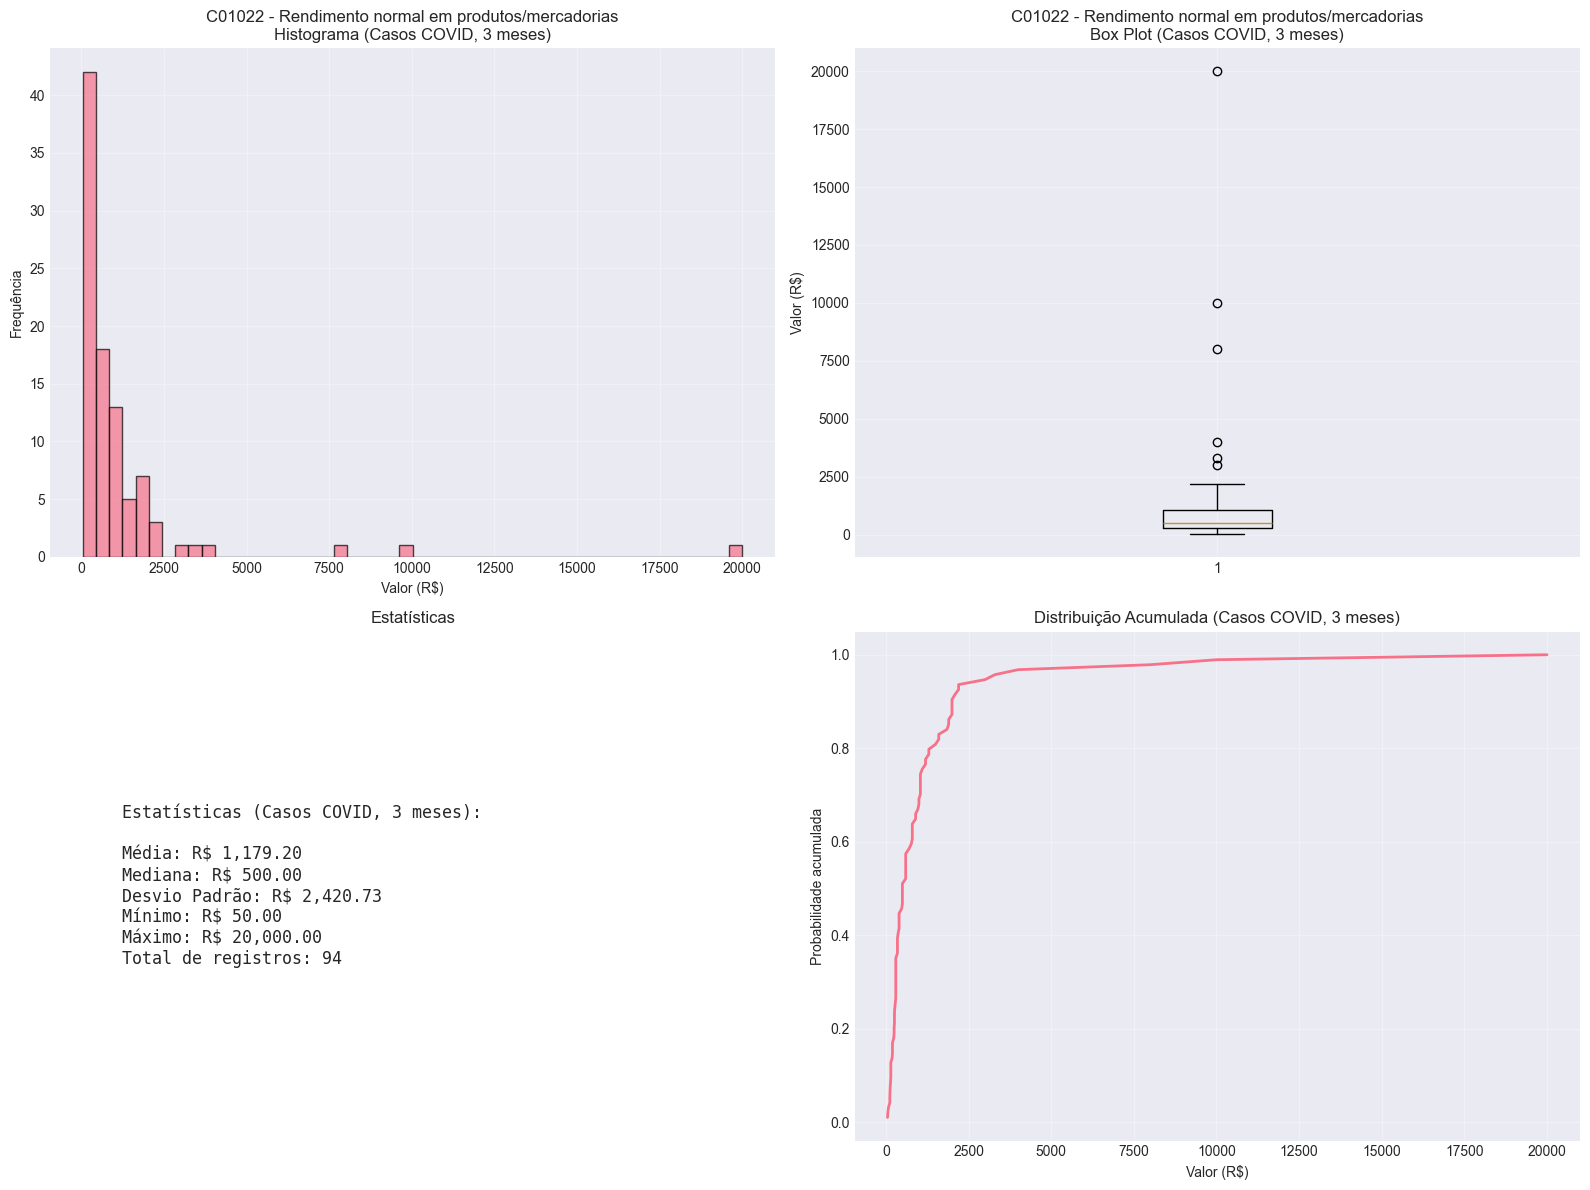

Estatísticas (Casos COVID, 3 meses):

Média: R$ 1,179.20
Mediana: R$ 500.00
Desvio Padrão: R$ 2,420.73
Mínimo: R$ 50.00
Máximo: R$ 20,000.00
Total de registros: 94

################################################################################
Item 36/53: C011A12
################################################################################


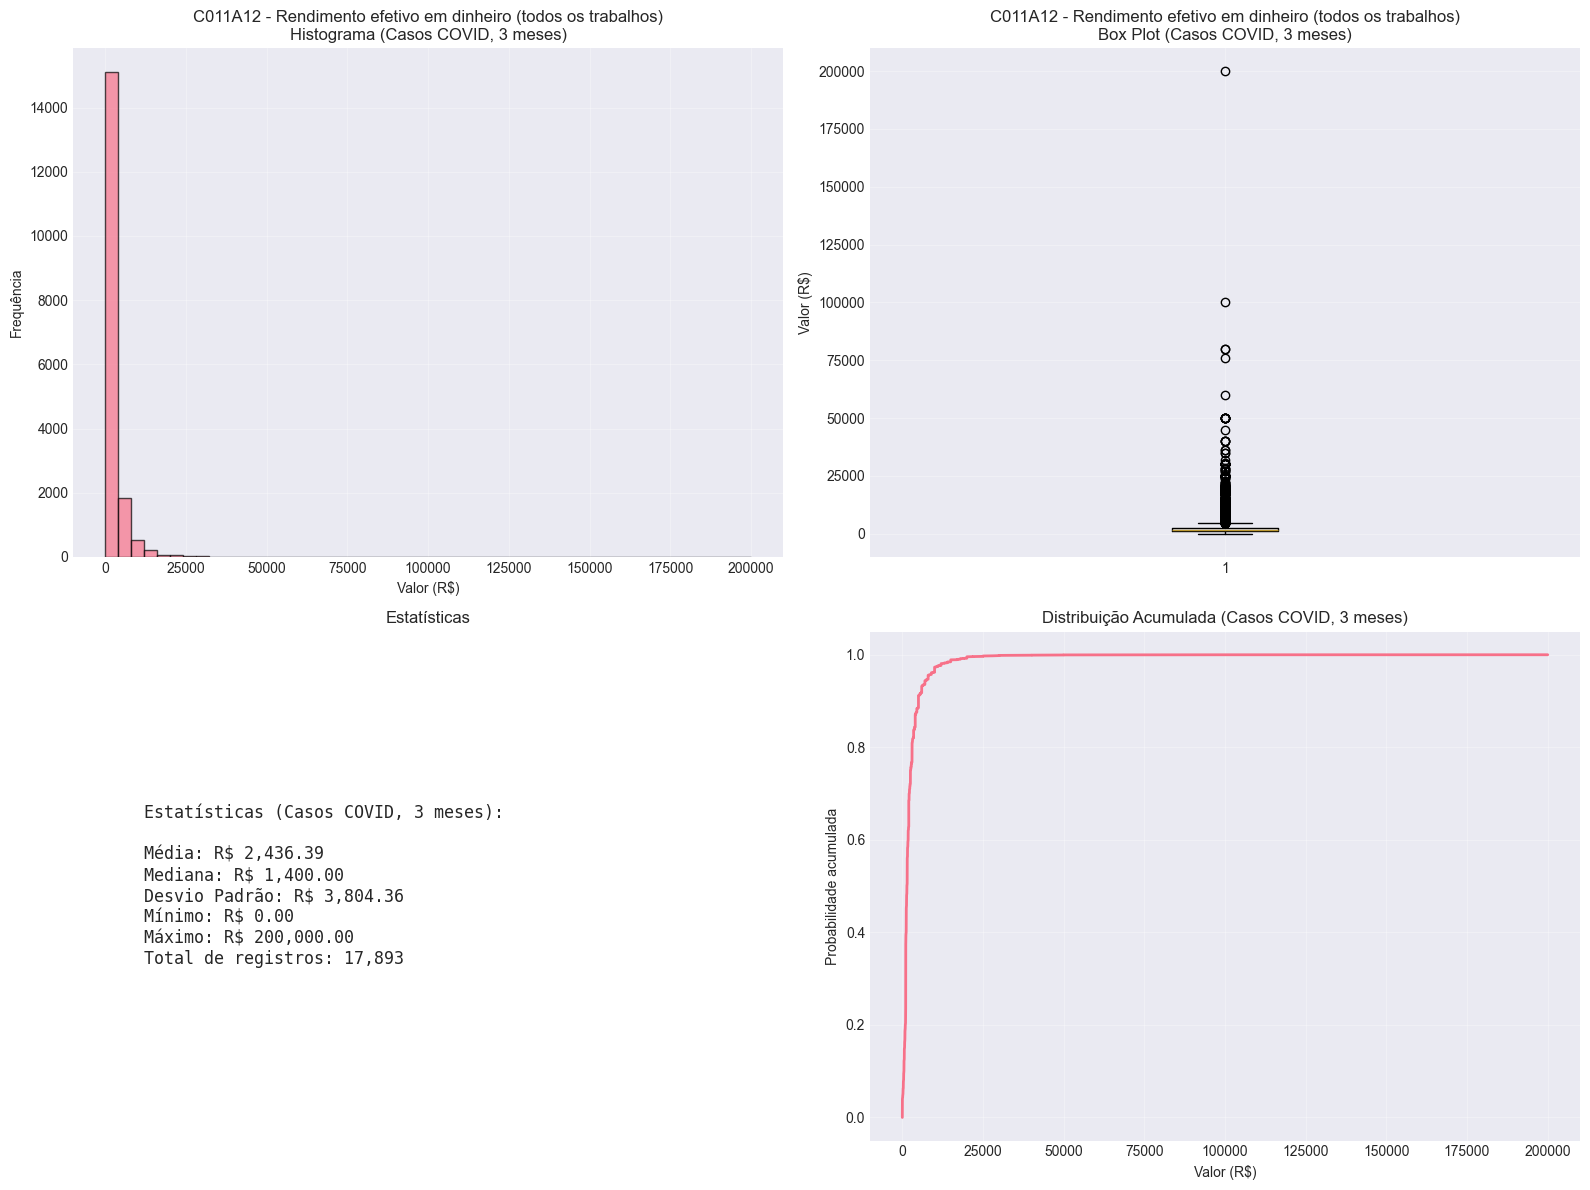

Estatísticas (Casos COVID, 3 meses):

Média: R$ 2,436.39
Mediana: R$ 1,400.00
Desvio Padrão: R$ 3,804.36
Mínimo: R$ 0.00
Máximo: R$ 200,000.00
Total de registros: 17,893

################################################################################
Item 37/53: C011A22
################################################################################


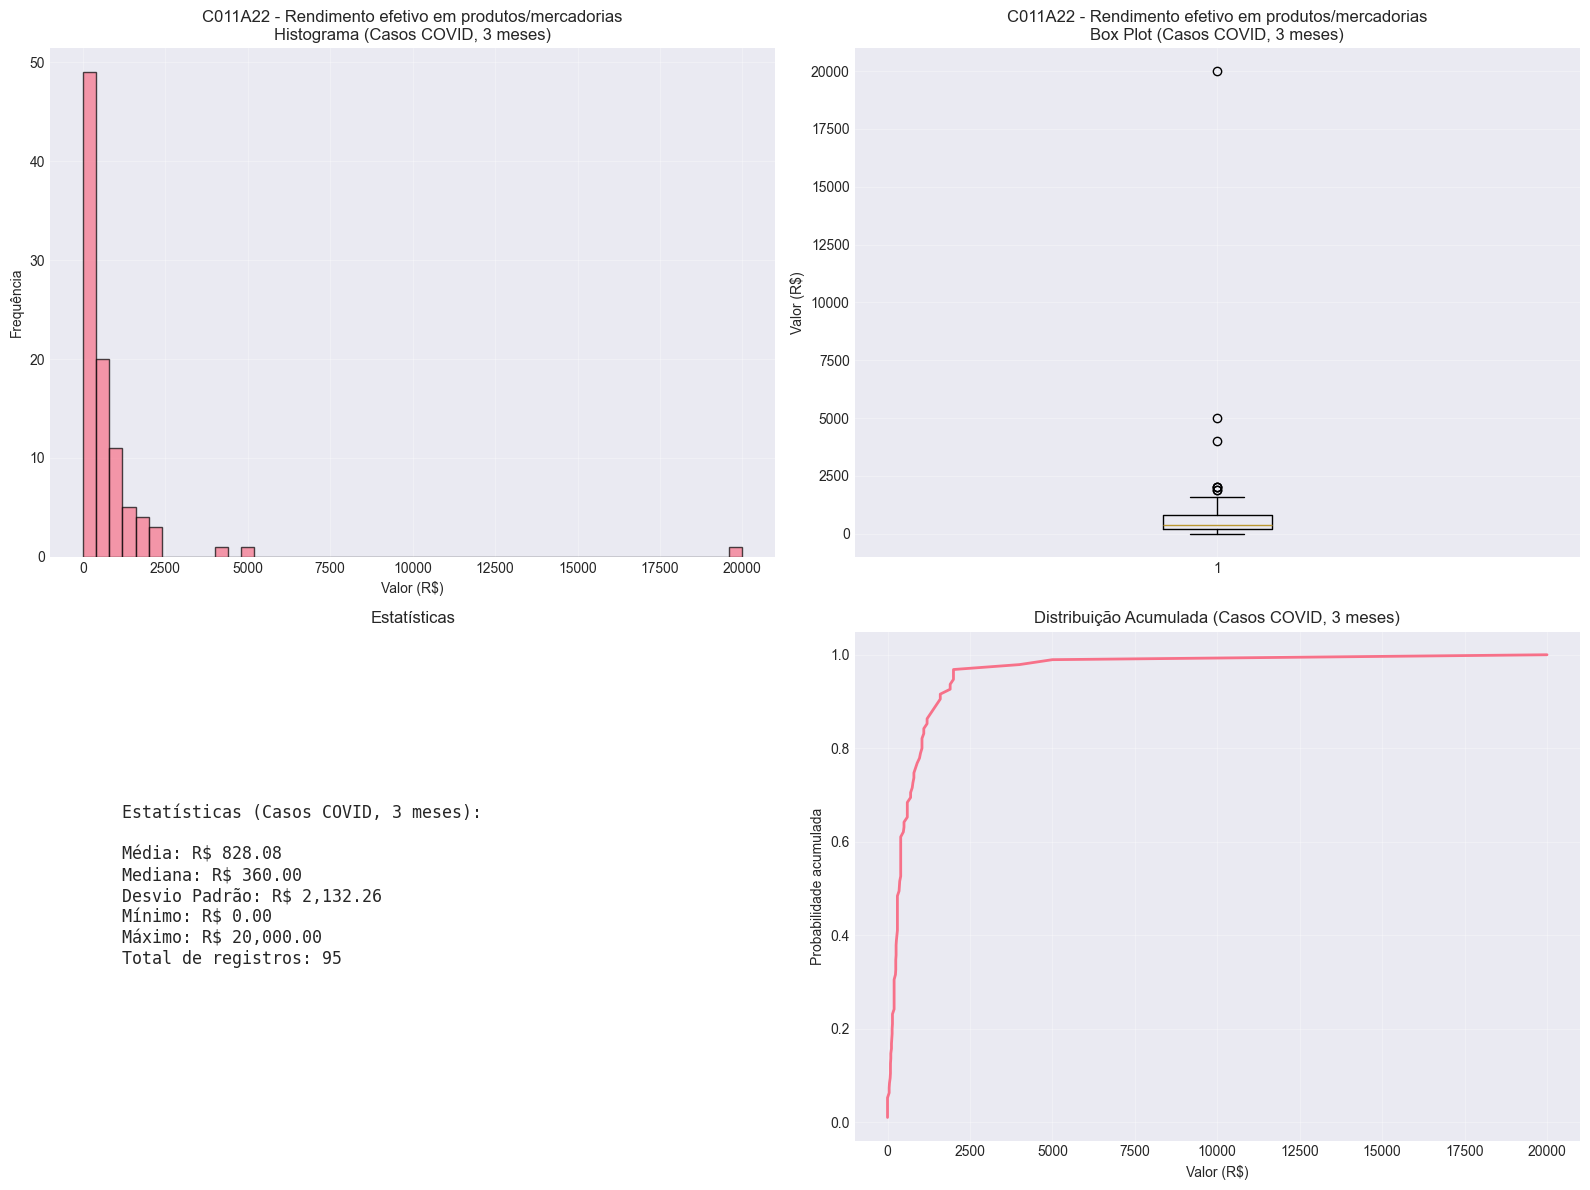

Estatísticas (Casos COVID, 3 meses):

Média: R$ 828.08
Mediana: R$ 360.00
Desvio Padrão: R$ 2,132.26
Mínimo: R$ 0.00
Máximo: R$ 20,000.00
Total de registros: 95

################################################################################
Item 38/53: C012
################################################################################


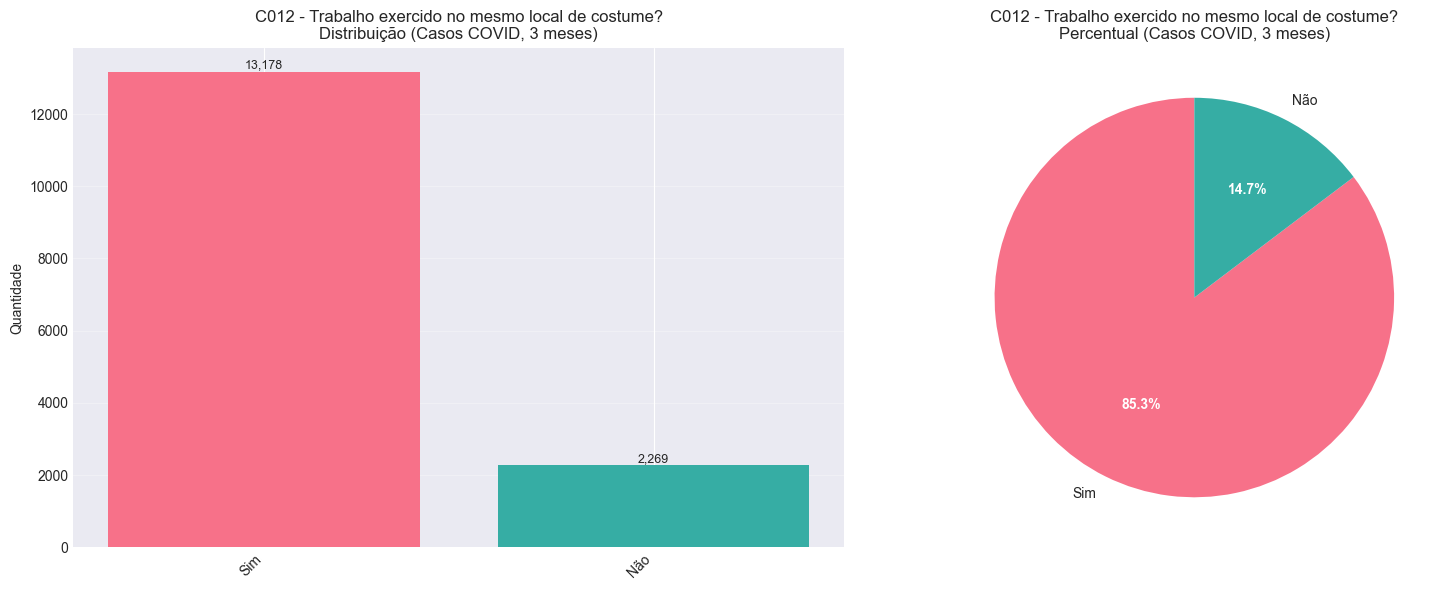

Label  Quantidade  Percentual
  Sim       13178       85.31
  Não        2269       14.69

################################################################################
Item 39/53: C013
################################################################################


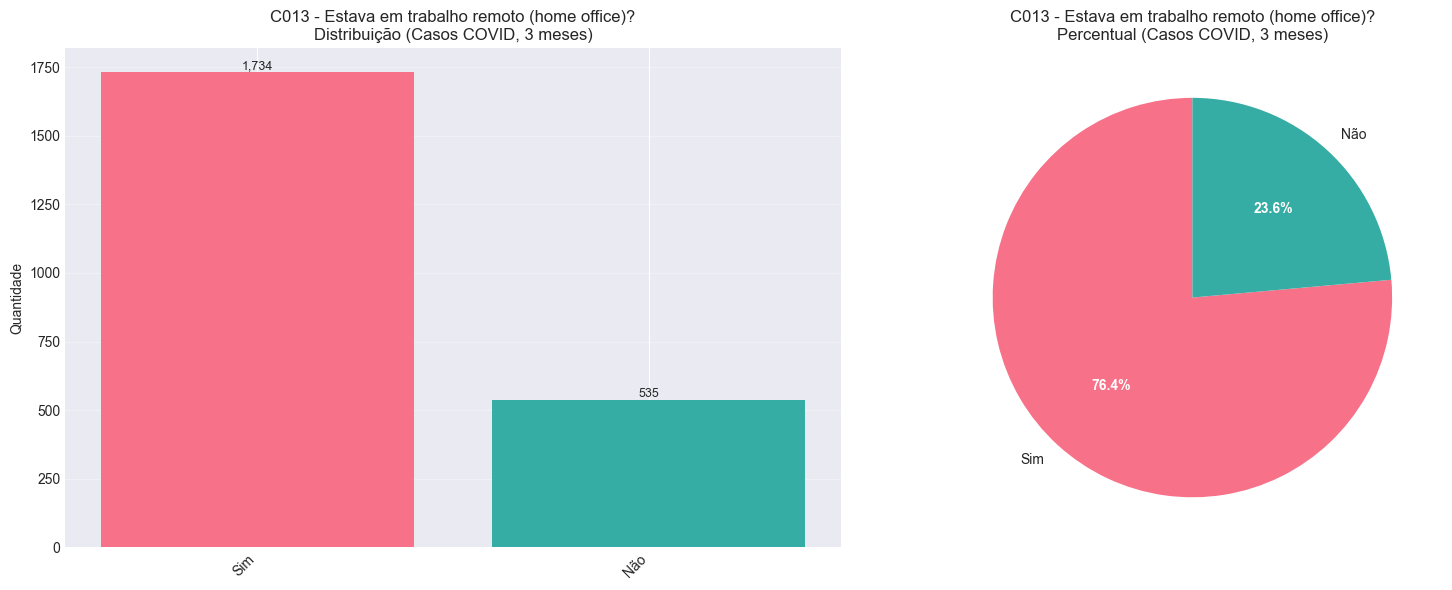

Label  Quantidade  Percentual
  Sim        1734       76.42
  Não         535       23.58

################################################################################
Item 40/53: D0013
################################################################################


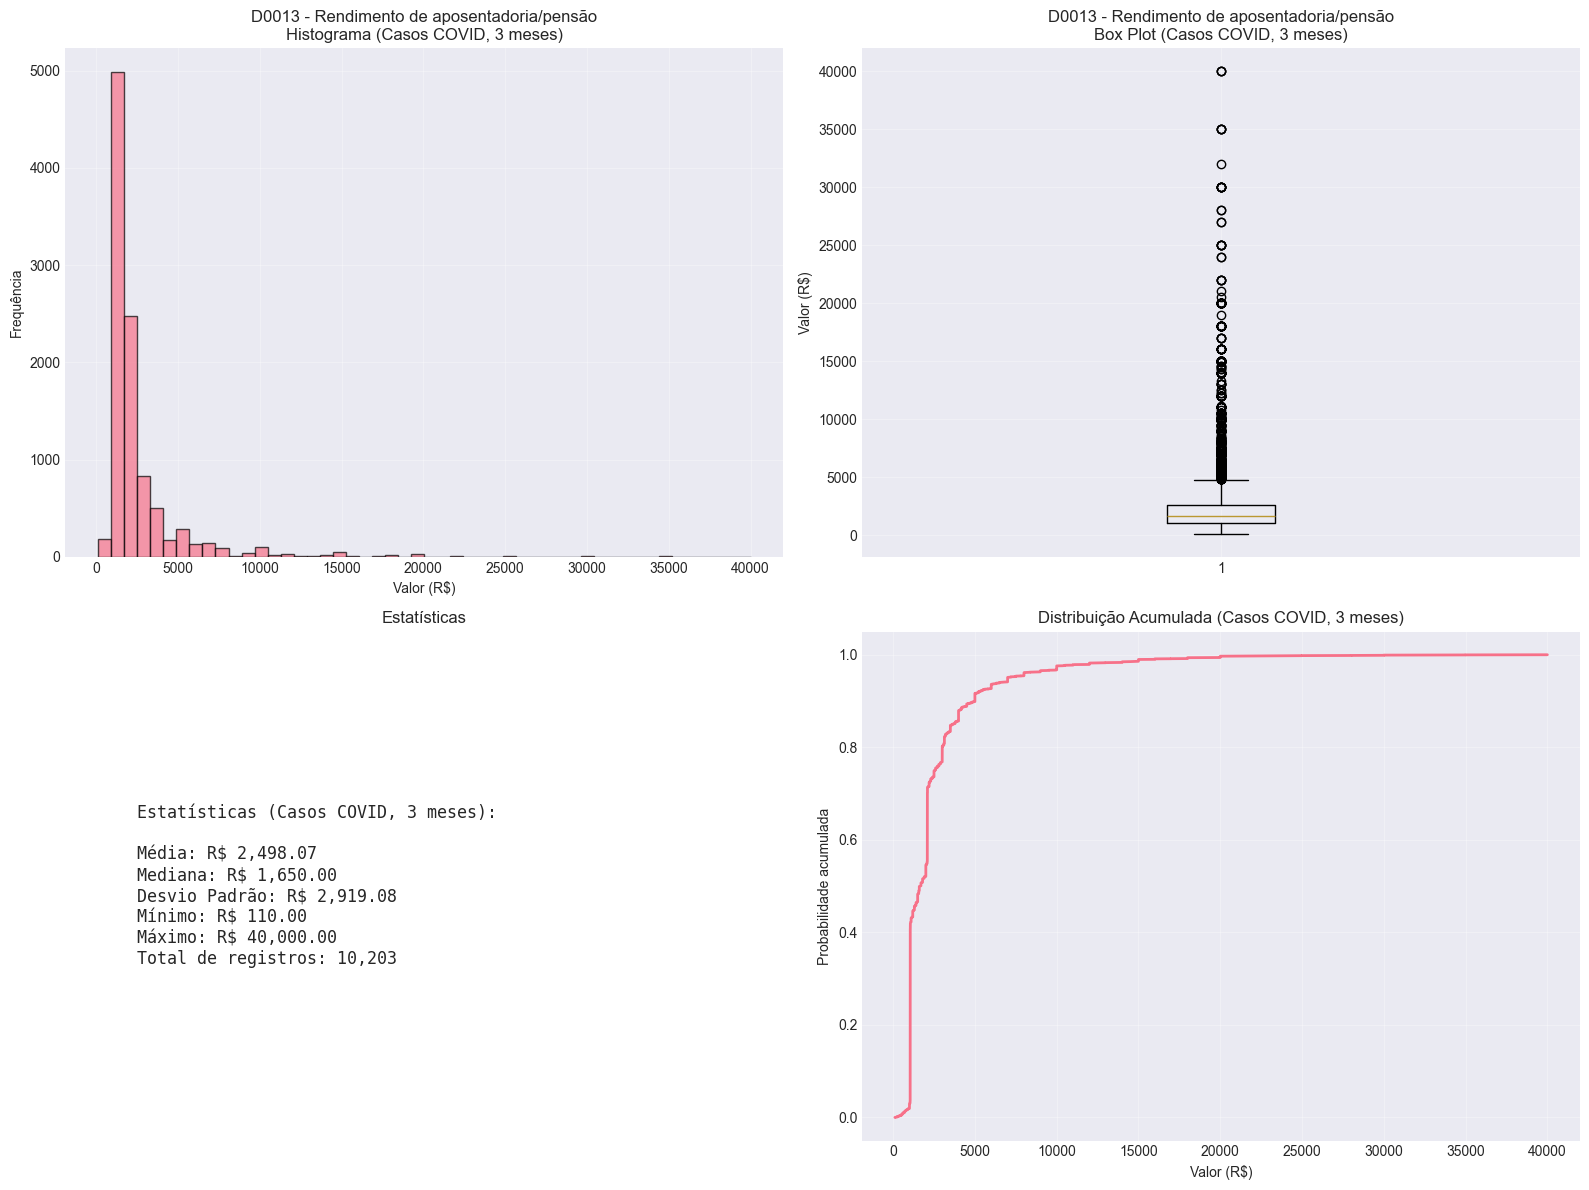

Estatísticas (Casos COVID, 3 meses):

Média: R$ 2,498.07
Mediana: R$ 1,650.00
Desvio Padrão: R$ 2,919.08
Mínimo: R$ 110.00
Máximo: R$ 40,000.00
Total de registros: 10,203

################################################################################
Item 41/53: D0023
################################################################################


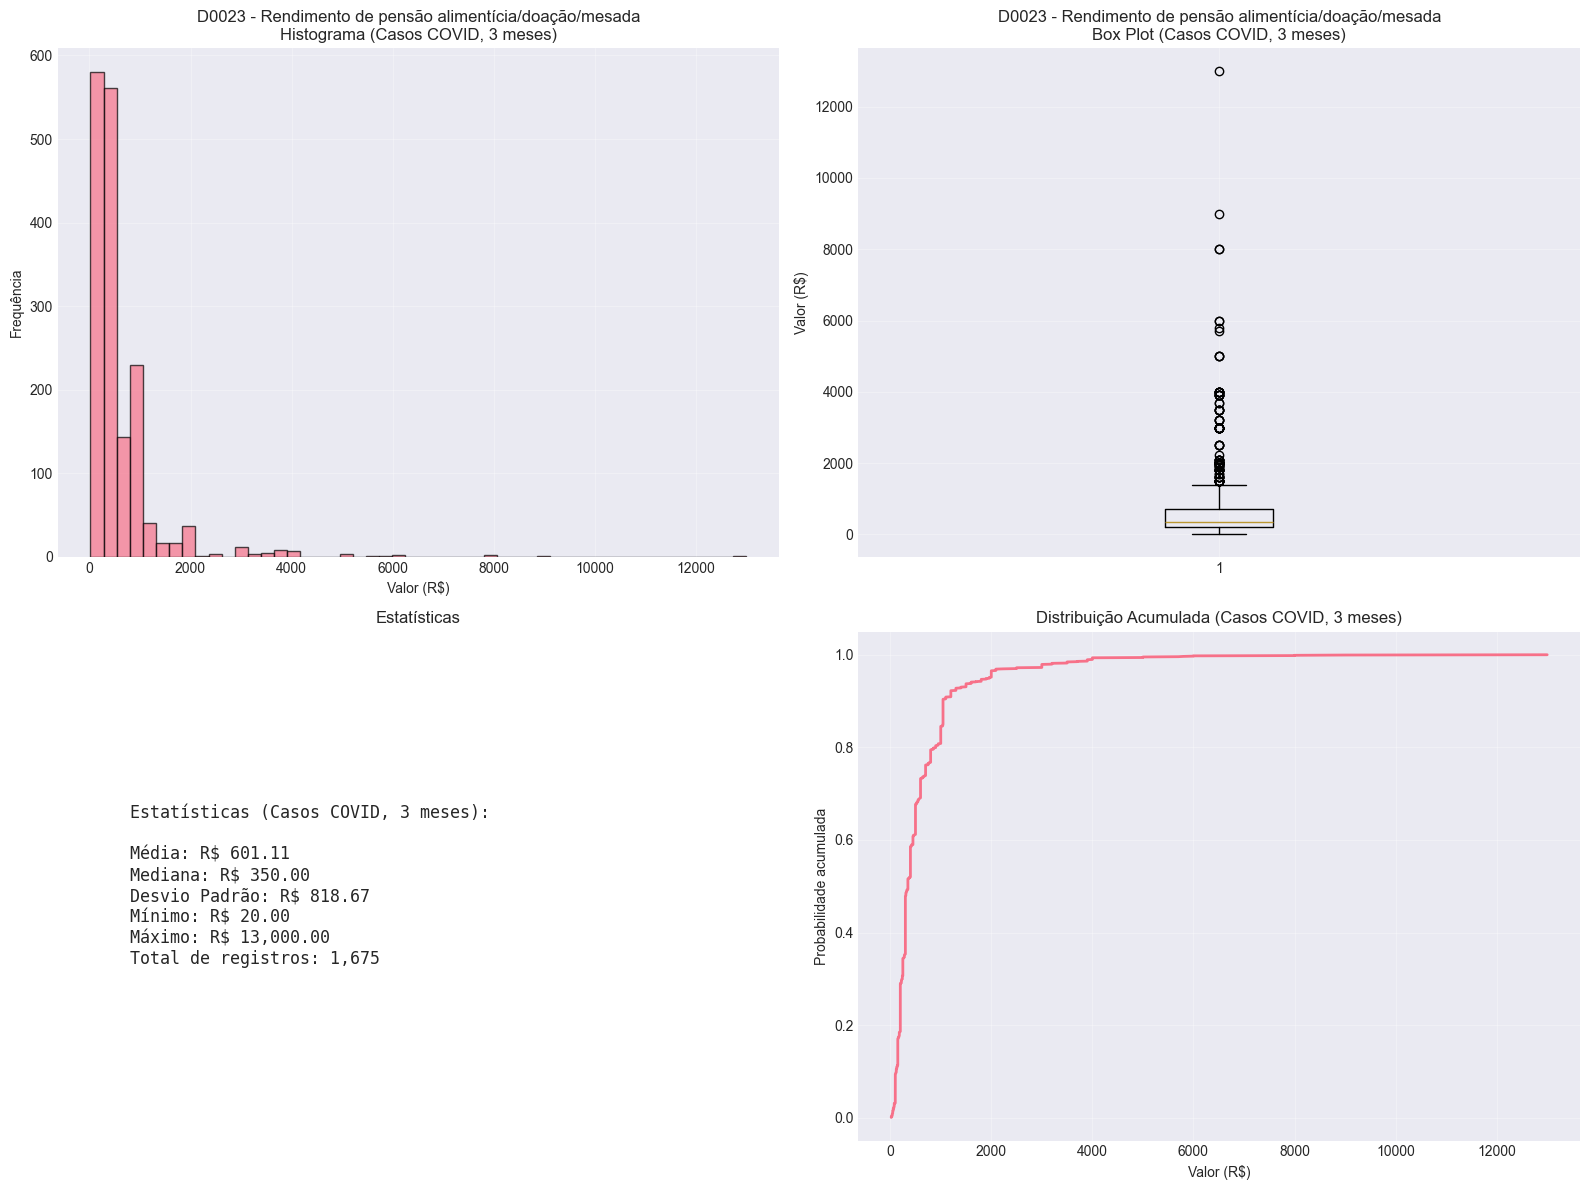

Estatísticas (Casos COVID, 3 meses):

Média: R$ 601.11
Mediana: R$ 350.00
Desvio Padrão: R$ 818.67
Mínimo: R$ 20.00
Máximo: R$ 13,000.00
Total de registros: 1,675

################################################################################
Item 42/53: D0033
################################################################################


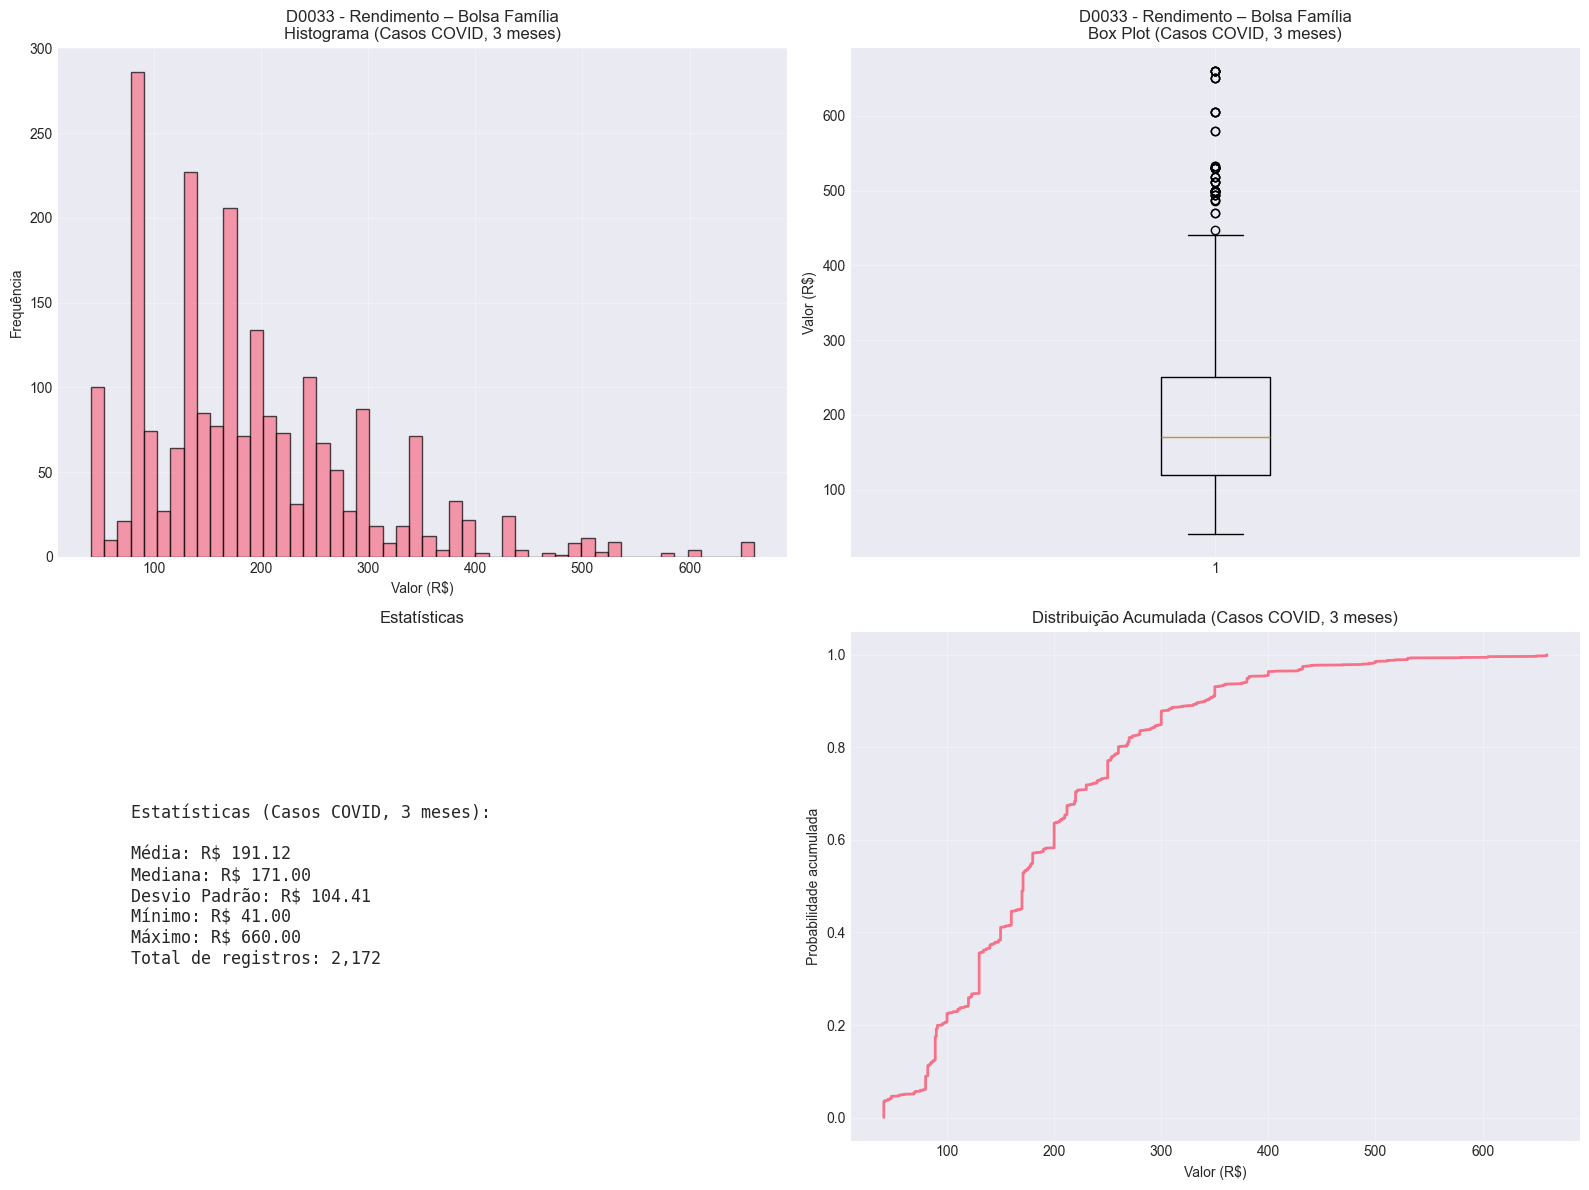

Estatísticas (Casos COVID, 3 meses):

Média: R$ 191.12
Mediana: R$ 171.00
Desvio Padrão: R$ 104.41
Mínimo: R$ 41.00
Máximo: R$ 660.00
Total de registros: 2,172

################################################################################
Item 43/53: D0043
################################################################################


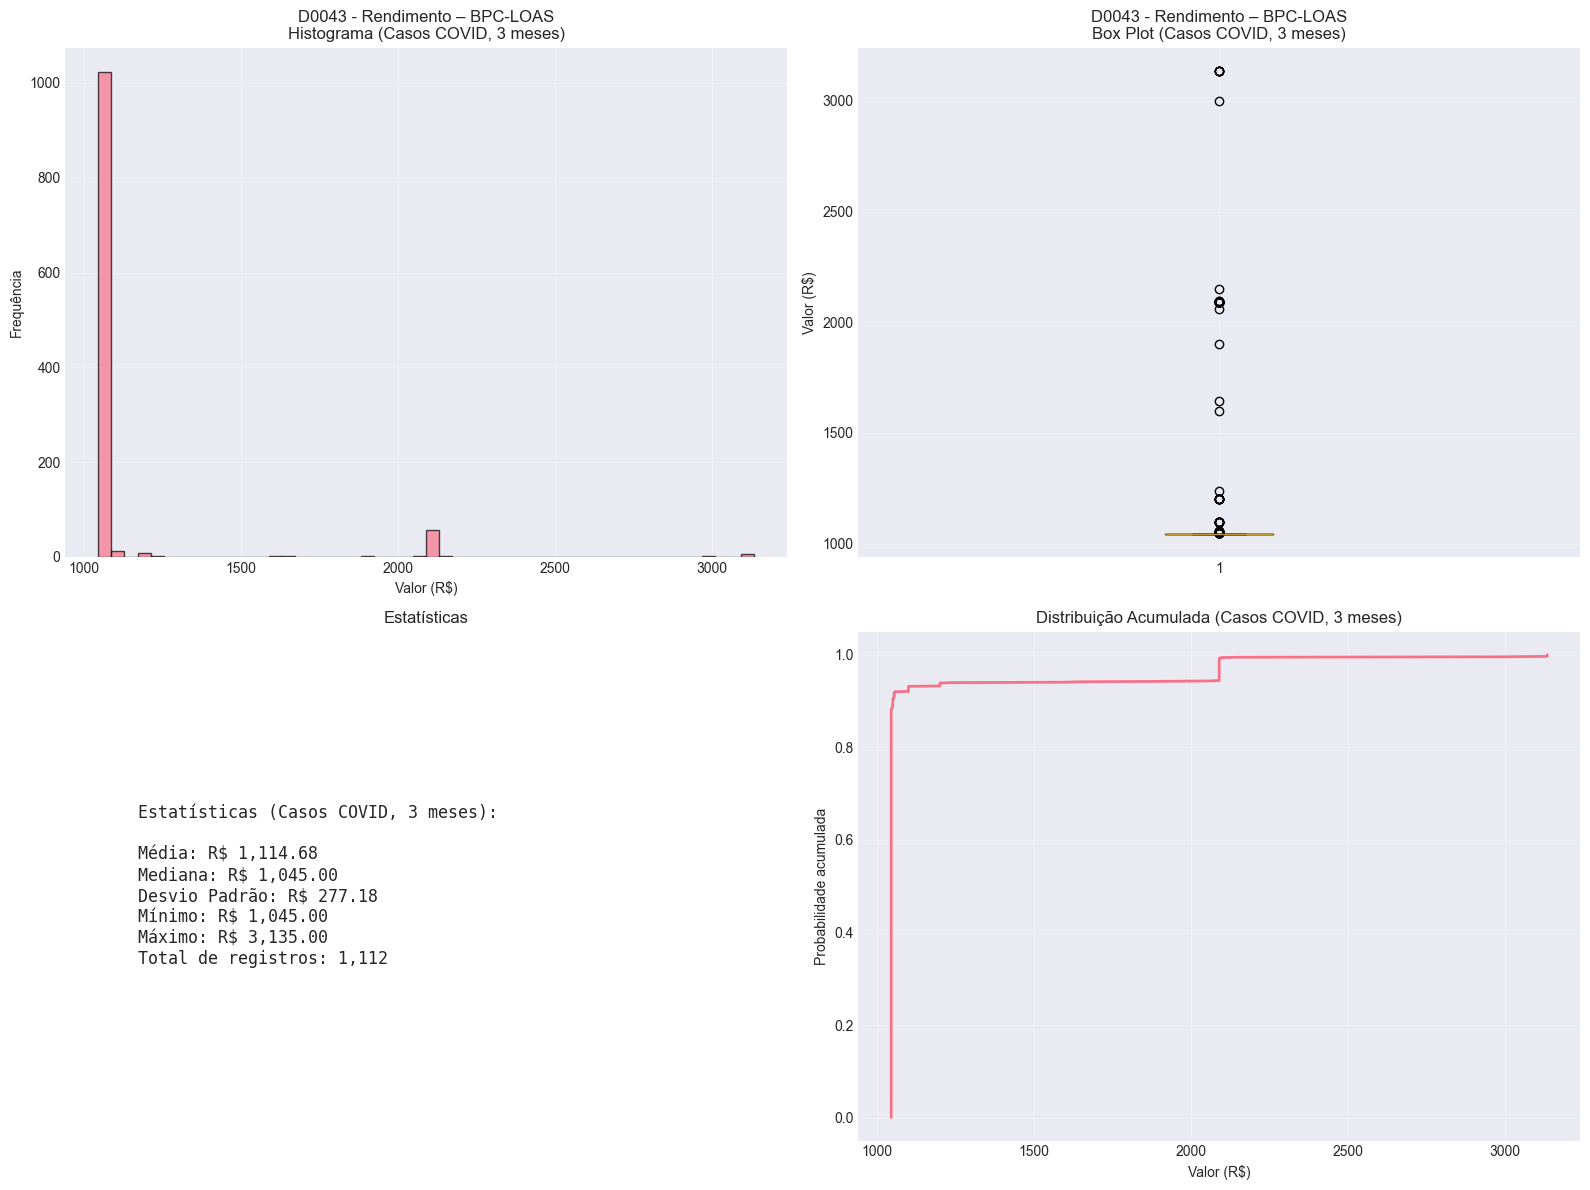

Estatísticas (Casos COVID, 3 meses):

Média: R$ 1,114.68
Mediana: R$ 1,045.00
Desvio Padrão: R$ 277.18
Mínimo: R$ 1,045.00
Máximo: R$ 3,135.00
Total de registros: 1,112

################################################################################
Item 44/53: D0053
################################################################################


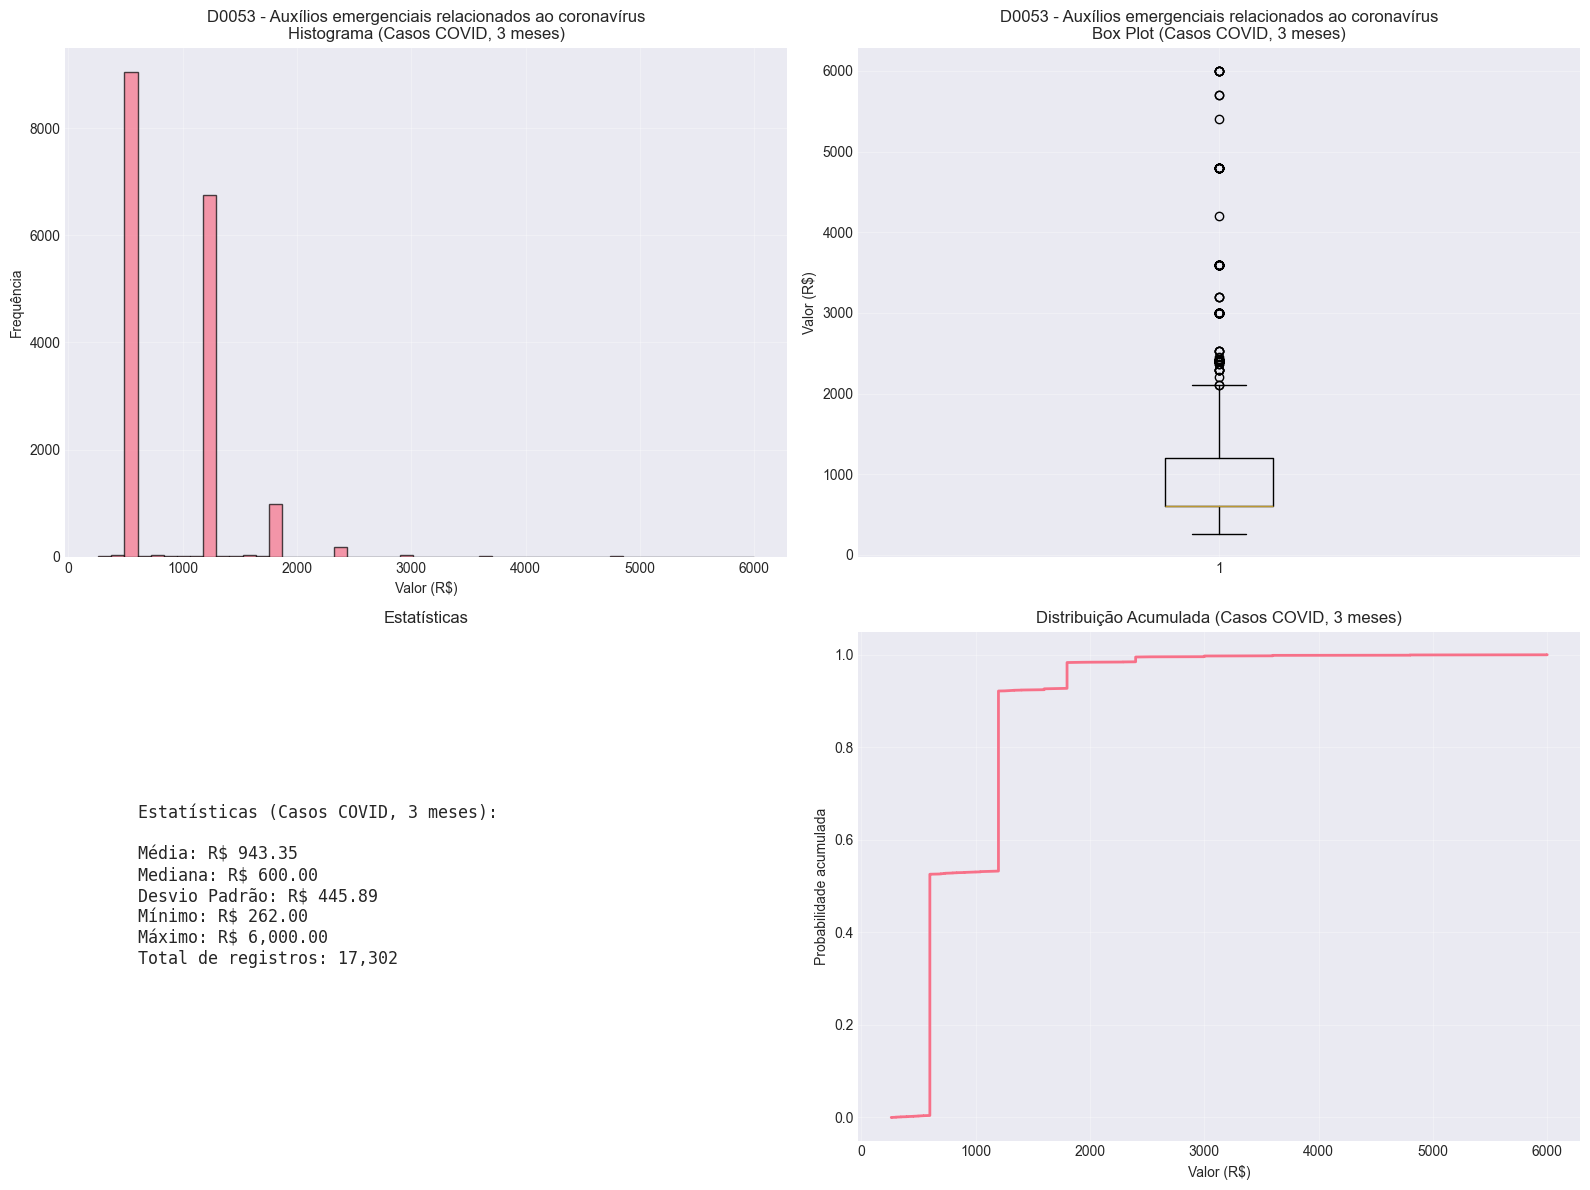

Estatísticas (Casos COVID, 3 meses):

Média: R$ 943.35
Mediana: R$ 600.00
Desvio Padrão: R$ 445.89
Mínimo: R$ 262.00
Máximo: R$ 6,000.00
Total de registros: 17,302

################################################################################
Item 45/53: D0063
################################################################################


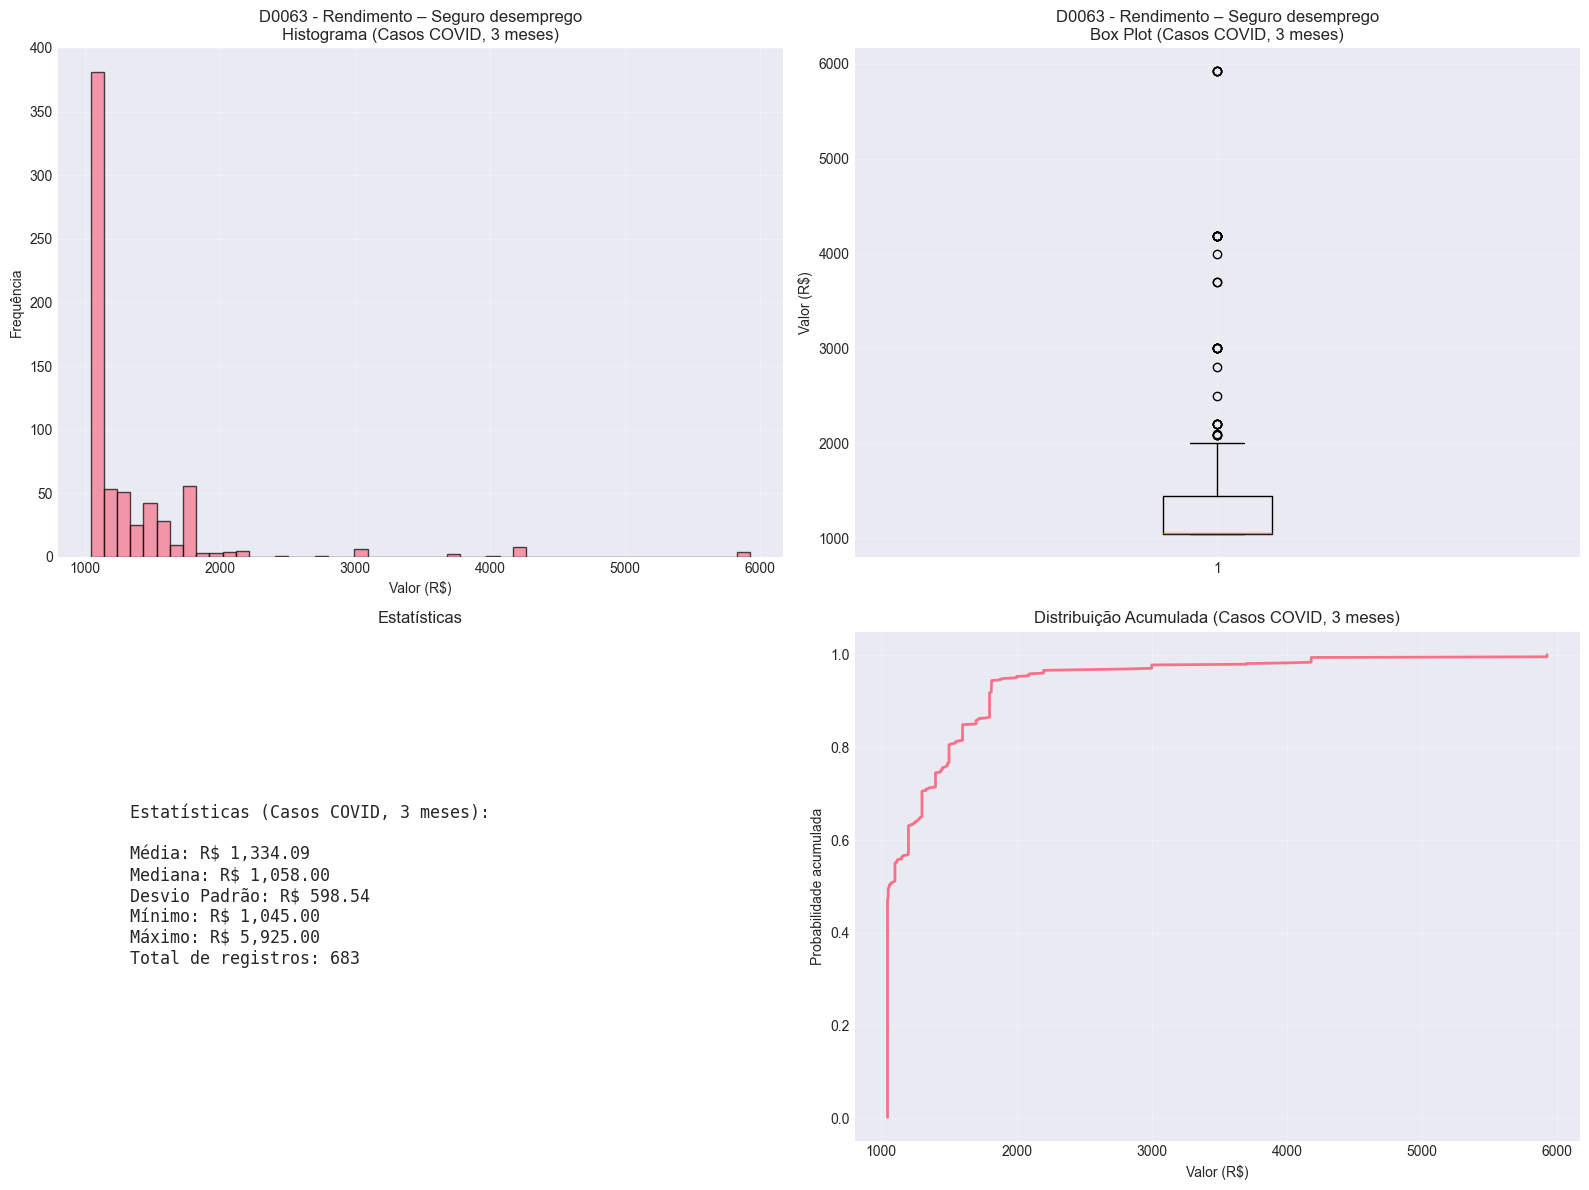

Estatísticas (Casos COVID, 3 meses):

Média: R$ 1,334.09
Mediana: R$ 1,058.00
Desvio Padrão: R$ 598.54
Mínimo: R$ 1,045.00
Máximo: R$ 5,925.00
Total de registros: 683

################################################################################
Item 46/53: E001
################################################################################


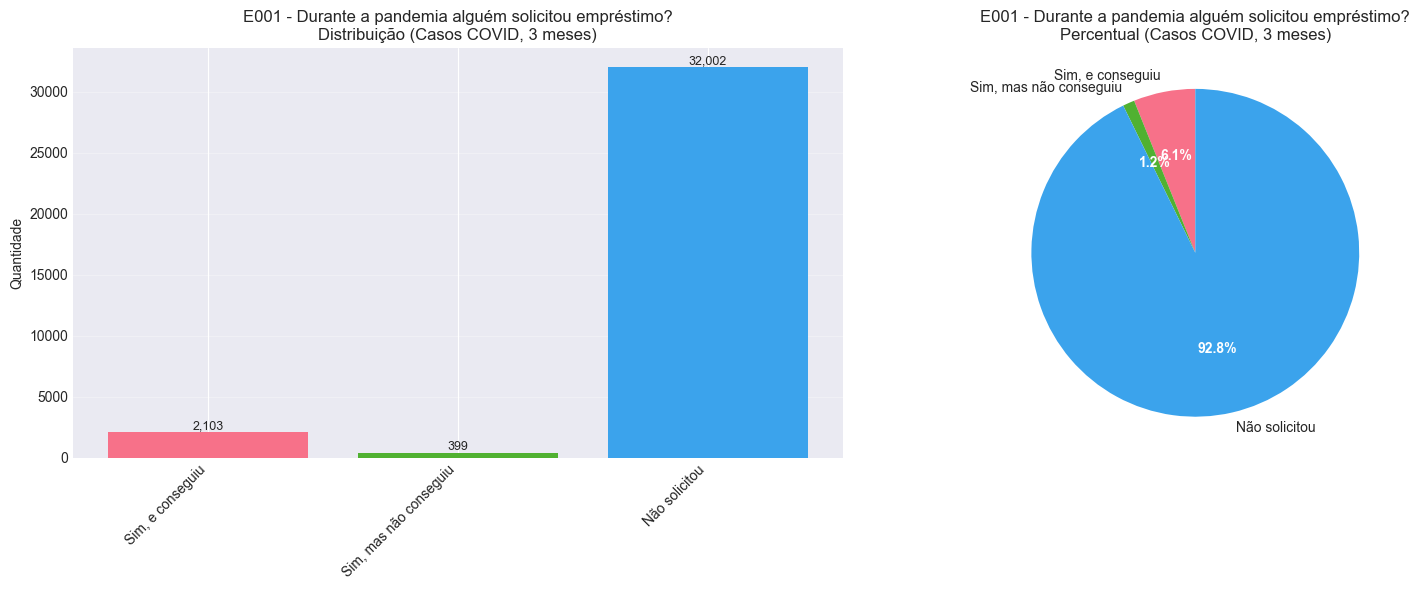

                 Label  Quantidade  Percentual
      Sim, e conseguiu        2103        6.09
Sim, mas não conseguiu         399        1.16
         Não solicitou       32002       92.75

################################################################################
Item 47/53: F001
################################################################################


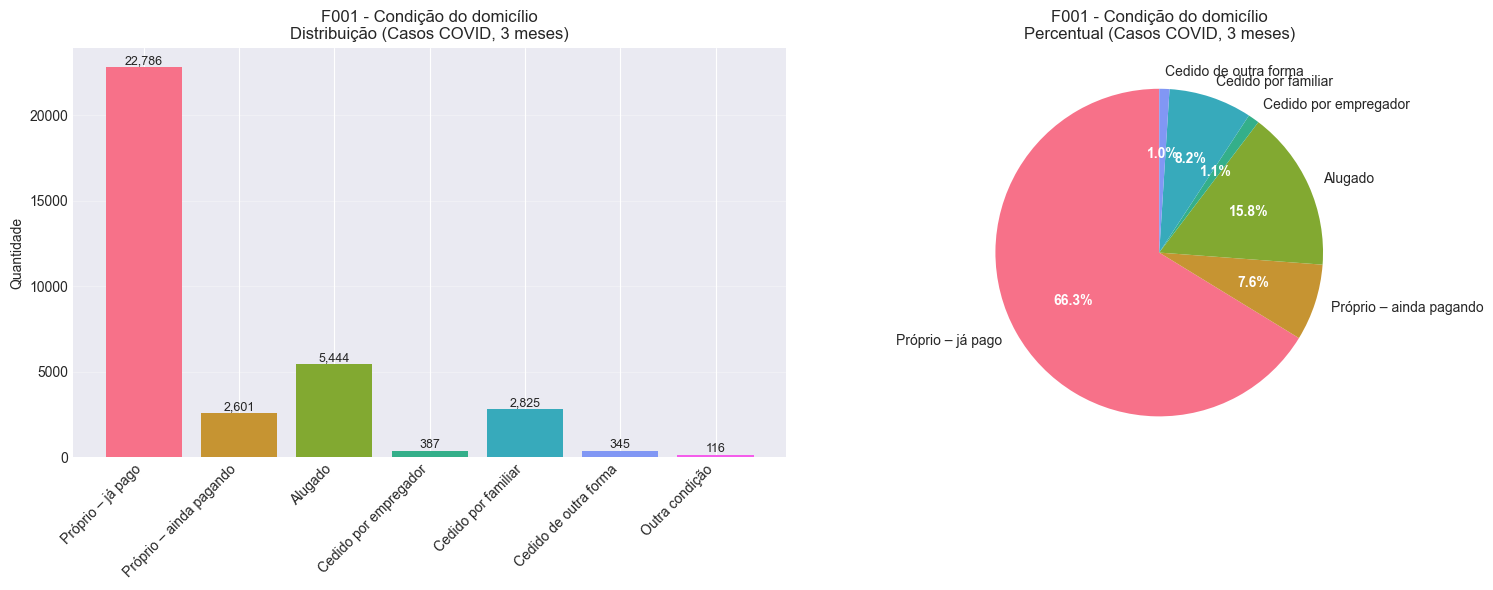

                  Label  Quantidade  Percentual
      Próprio – já pago       22786       66.04
Próprio – ainda pagando        2601        7.54
                Alugado        5444       15.78
  Cedido por empregador         387        1.12
    Cedido por familiar        2825        8.19
  Cedido de outra forma         345        1.00
         Outra condição         116        0.34

################################################################################
Item 48/53: F0021
################################################################################


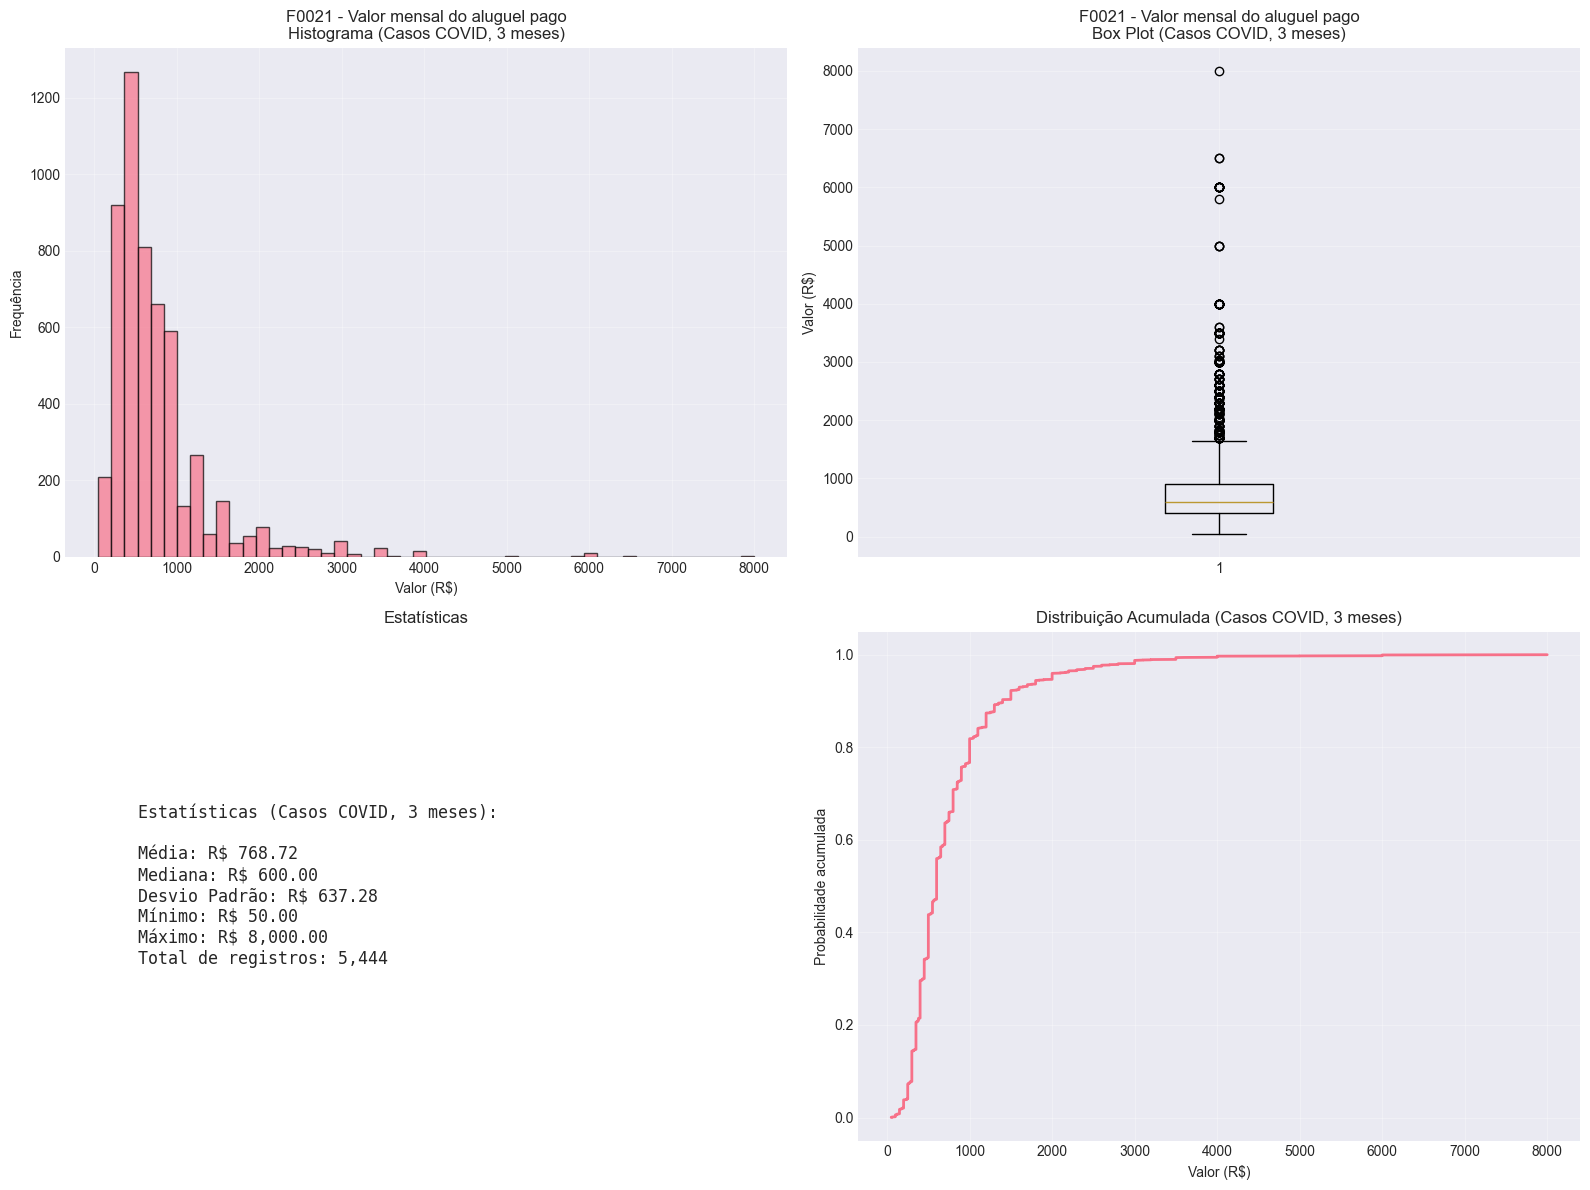

Estatísticas (Casos COVID, 3 meses):

Média: R$ 768.72
Mediana: R$ 600.00
Desvio Padrão: R$ 637.28
Mínimo: R$ 50.00
Máximo: R$ 8,000.00
Total de registros: 5,444

################################################################################
Item 49/53: F002A1
################################################################################


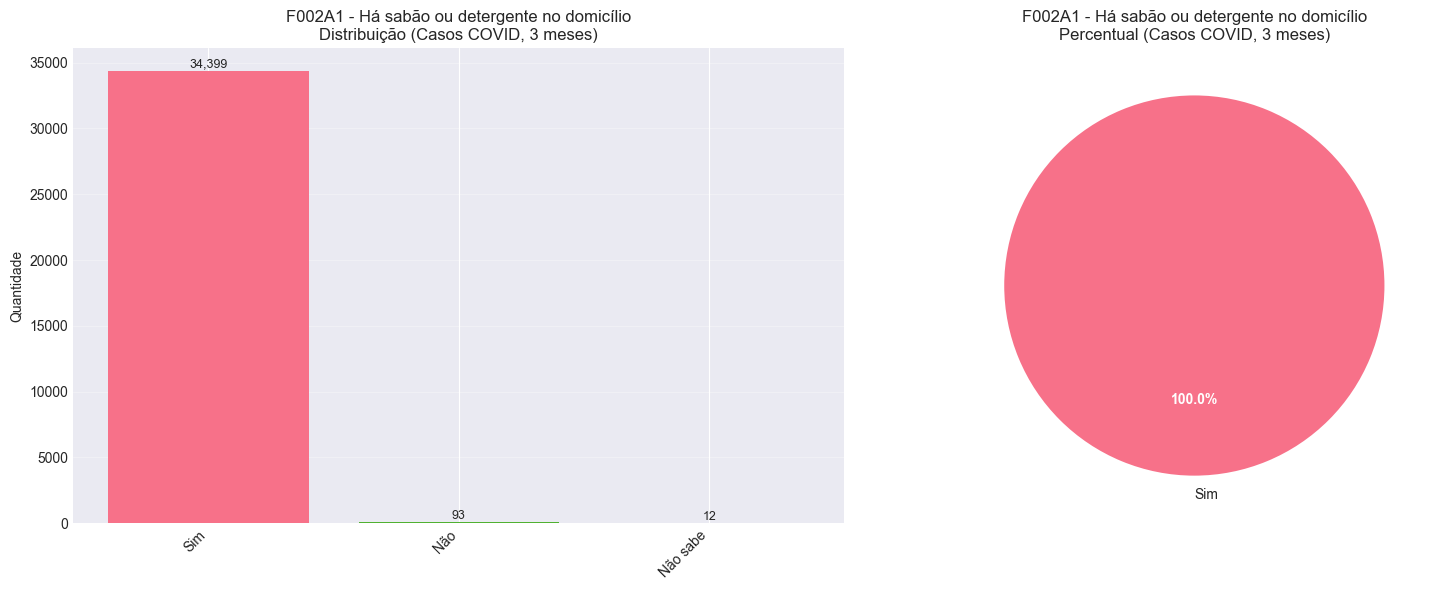

   Label  Quantidade  Percentual
     Sim       34399       99.70
     Não          93        0.27
Não sabe          12        0.03

################################################################################
Item 50/53: F002A2
################################################################################


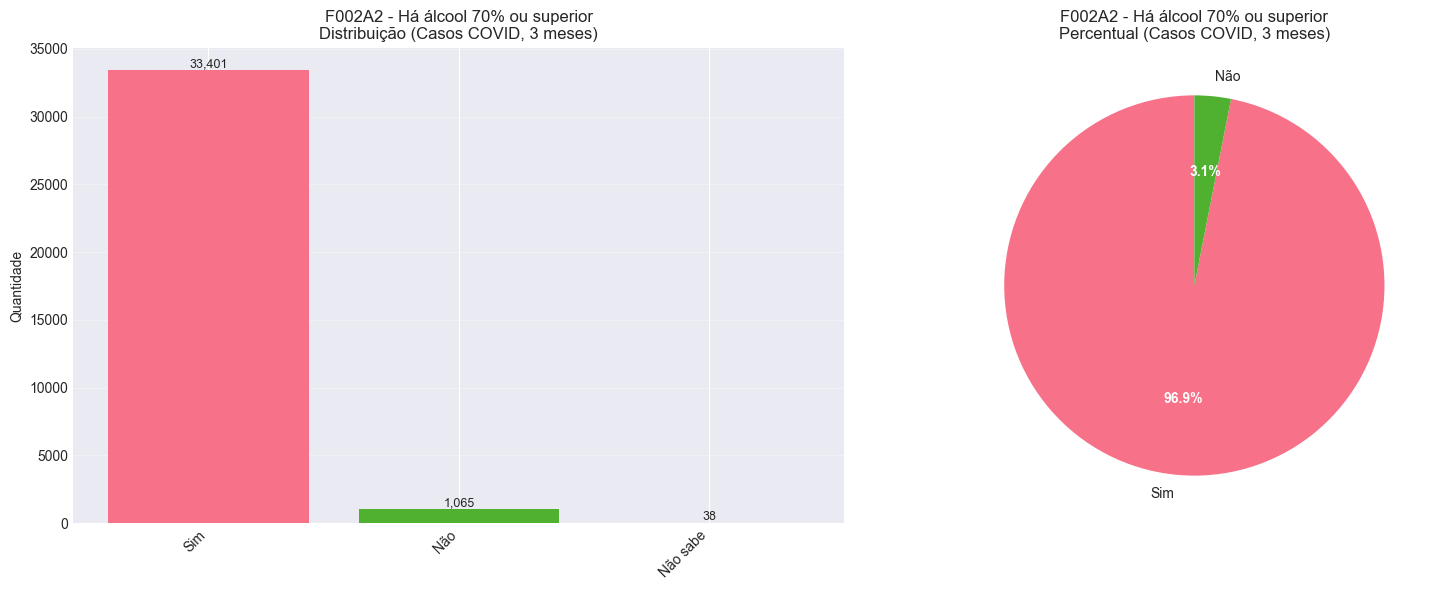

   Label  Quantidade  Percentual
     Sim       33401       96.80
     Não        1065        3.09
Não sabe          38        0.11

################################################################################
Item 51/53: F002A3
################################################################################


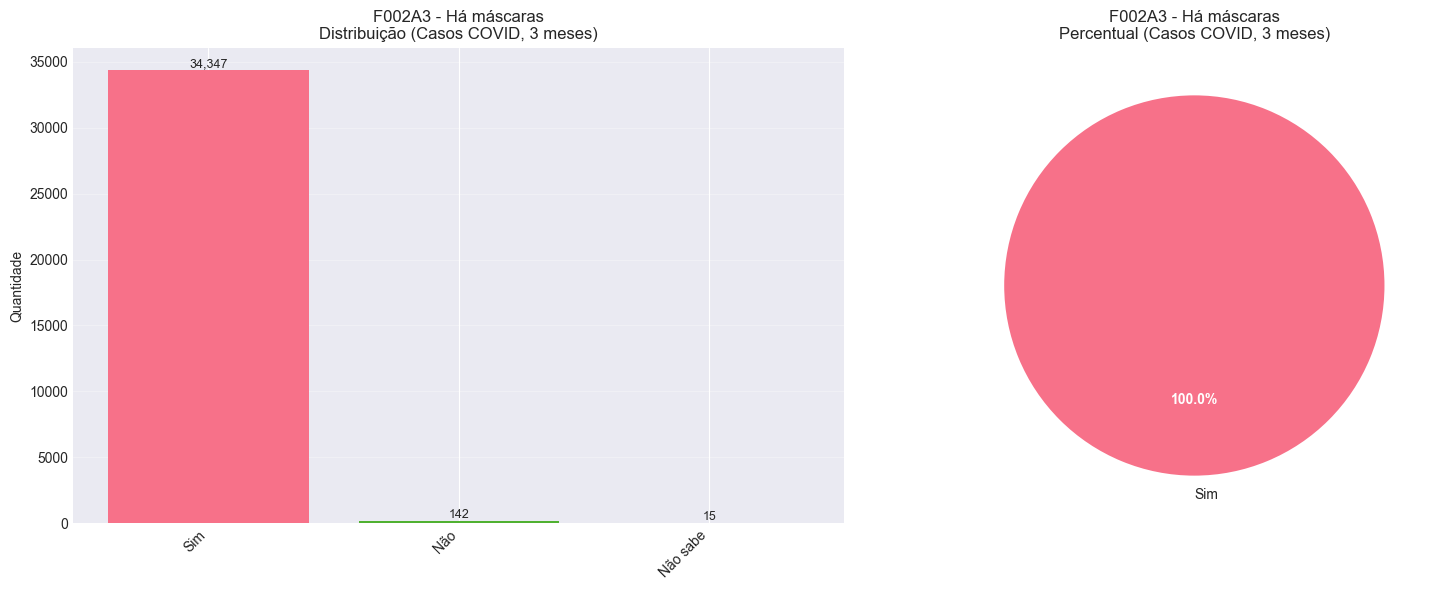

   Label  Quantidade  Percentual
     Sim       34347       99.54
     Não         142        0.41
Não sabe          15        0.04

################################################################################
Item 52/53: F002A4
################################################################################


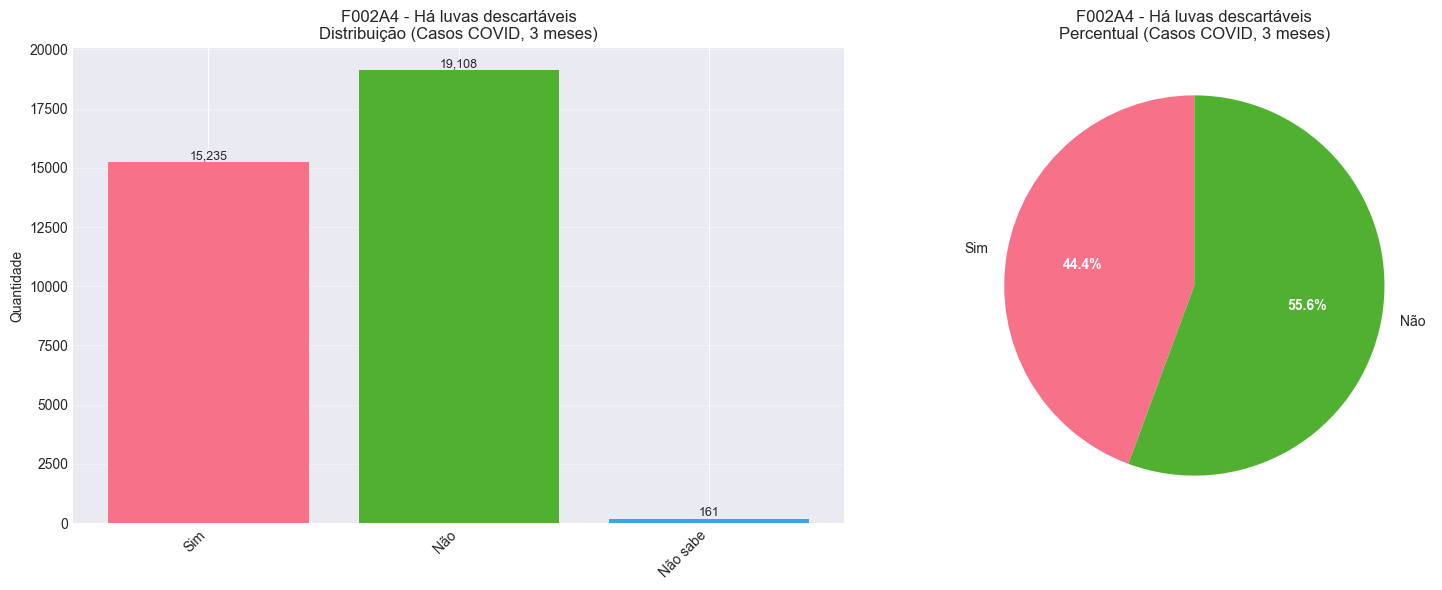

   Label  Quantidade  Percentual
     Sim       15235       44.15
     Não       19108       55.38
Não sabe         161        0.47

################################################################################
Item 53/53: F002A5
################################################################################


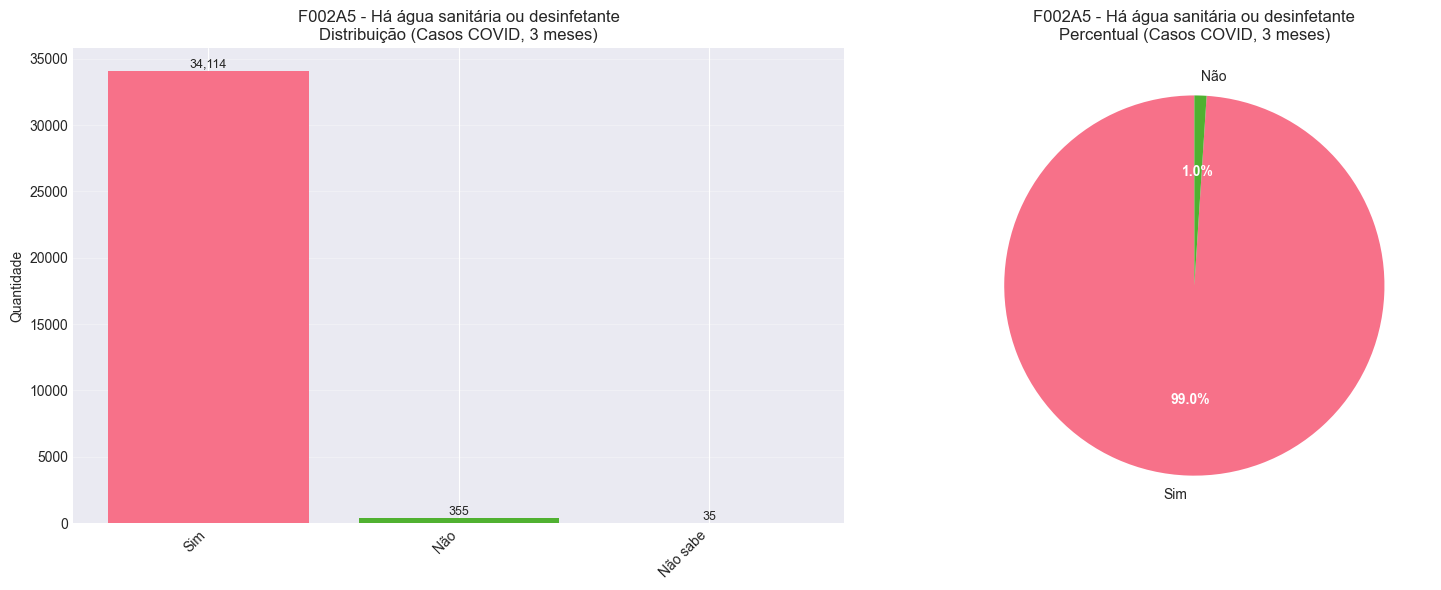

   Label  Quantidade  Percentual
     Sim       34114       98.87
     Não         355        1.03
Não sabe          35        0.10

✓ Análise concluída para casos COVID.


In [7]:
# Gerar gráficos para TODOS os itens, apenas casos COVID (3 meses)

if df_transformado is not None and 'df_transformado_covid' in globals() and df_transformado_covid is not None:
    total_itens = len(itens_analise)
    print(f"Gerando gráficos para TODOS os {total_itens} itens (apenas casos COVID, 3 meses)...\n")
    for idx, (item_codigo, item_info) in enumerate(itens_analise.items(), start=1):
        print(f"\n{'#'*80}")
        print(f"Item {idx}/{total_itens}: {item_codigo}")
        print(f"{'#'*80}")
        criar_grafico_item(df_transformado_covid, item_codigo, item_info)
    print("\n✓ Análise concluída para casos COVID.")
else:
    print("Erro: df_transformado ou df_transformado_covid não está disponível.")


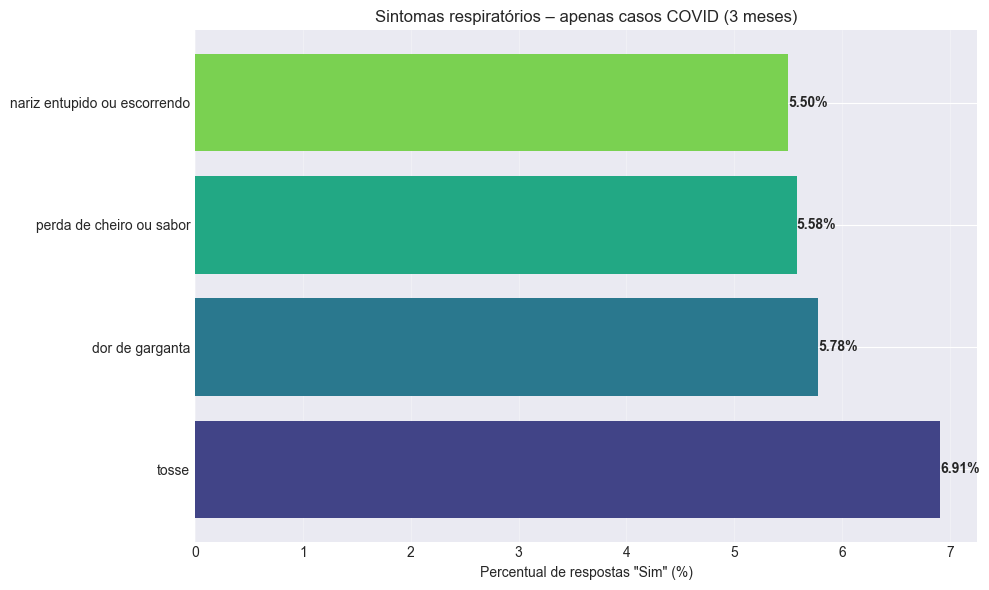


Tabela – Sintomas respiratórios (casos COVID):
Codigo                      Sintoma  Percentual_Sim  Quantidade_Sim
 B0012                        tosse            6.91            2383
 B0013              dor de garganta            5.78            1995
B00111     perda de cheiro ou sabor            5.58            1926
 B0018 nariz entupido ou escorrendo            5.50            1896


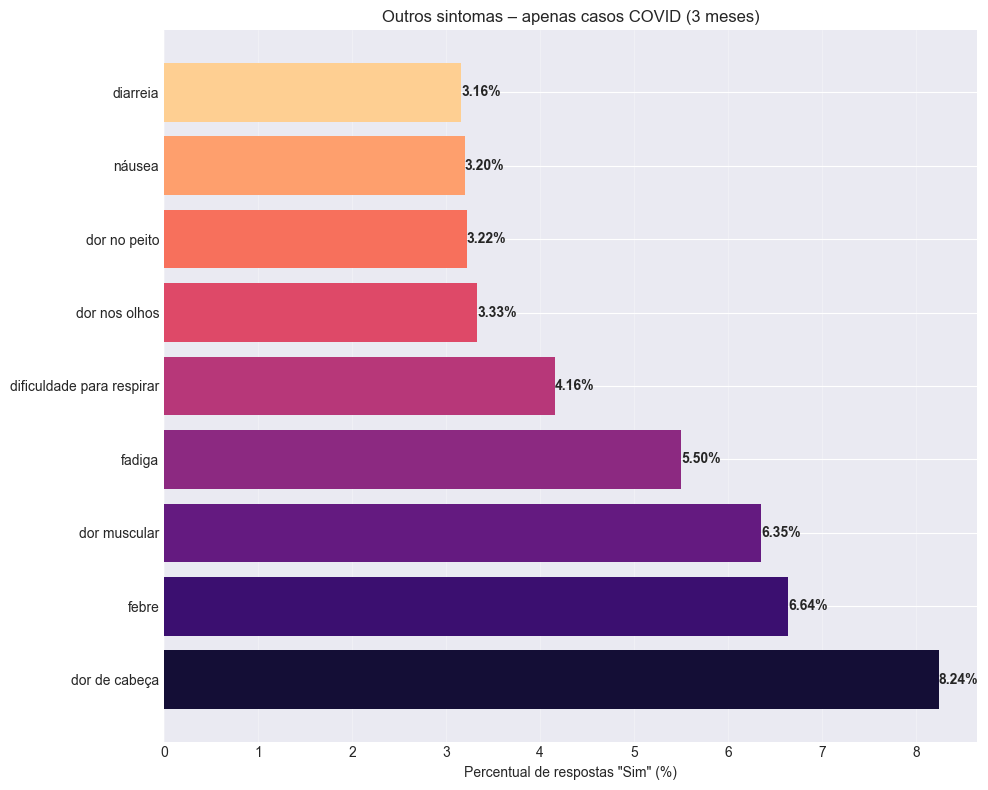


Tabela – Outros sintomas (casos COVID):
Codigo                   Sintoma  Percentual_Sim  Quantidade_Sim
 B0015             dor de cabeça            8.24            2842
 B0011                     febre            6.64            2290
B00112              dor muscular            6.35            2191
 B0019                    fadiga            5.50            1897
 B0014 dificuldade para respirar            4.16            1434
B00110             dor nos olhos            3.33            1148
 B0016              dor no peito            3.22            1111
 B0017                    náusea            3.20            1105
B00113                  diarreia            3.16            1089


In [8]:
# Análise comparativa de sintomas – respiratórios vs outros (apenas casos COVID)

if 'df_transformado_covid' in globals() and df_transformado_covid is not None:
    todos_sintomas = [
        'B0011', 'B0012', 'B0013', 'B0014', 'B0015', 'B0016',
        'B0017', 'B0018', 'B0019', 'B00110', 'B00111', 'B00112', 'B00113',
    ]

    # Grupo 1 – respiratórios: coriza, olfato, tosse, dor de garganta
    sintomas_respiratorios = ['B0012', 'B0013', 'B0018', 'B00111']
    sintomas_outros = [c for c in todos_sintomas if c not in sintomas_respiratorios]

    def montar_df_comparativo(df_base, codigos):
        linhas = []
        for cod in codigos:
            if cod in itens_analise:
                df_sint = preparar_dados_analise(df_base, cod, itens_analise[cod])
                if df_sint is not None and not isinstance(df_sint, dict):
                    sim_row = df_sint[df_sint['Codigo'] == 1]
                    if len(sim_row) > 0:
                        linhas.append(
                            {
                                'Codigo': cod,
                                'Sintoma': itens_analise[cod]['nome']
                                .replace('Na semana passada teve ', '')
                                .replace('?', ''),
                                'Percentual_Sim': sim_row.iloc[0]['Percentual'],
                                'Quantidade_Sim': sim_row.iloc[0]['Quantidade'],
                            }
                        )
        if not linhas:
            return None
        return pd.DataFrame(linhas).sort_values('Percentual_Sim', ascending=False)

    df_resp = montar_df_comparativo(df_transformado_covid, sintomas_respiratorios)
    df_outros = montar_df_comparativo(df_transformado_covid, sintomas_outros)

    # Gráfico – respiratórios
    if df_resp is not None:
        fig, ax = plt.subplots(figsize=(10, 6))
        cores = sns.color_palette('viridis', len(df_resp))
        bars = ax.barh(df_resp['Sintoma'], df_resp['Percentual_Sim'], color=cores)
        ax.set_xlabel('Percentual de respostas "Sim" (%)')
        ax.set_title('Sintomas respiratórios – apenas casos COVID (3 meses)')
        ax.grid(axis='x', alpha=0.3)
        for bar, pct in zip(bars, df_resp['Percentual_Sim']):
            width = bar.get_width()
            ax.text(width, bar.get_y() + bar.get_height() / 2.0, f'{pct:.2f}%',
                    ha='left', va='center', fontsize=10, fontweight='bold')
        plt.tight_layout()
        plt.show()
        print('\nTabela – Sintomas respiratórios (casos COVID):')
        print(df_resp.to_string(index=False))

    # Gráfico – outros sintomas
    if df_outros is not None:
        fig, ax = plt.subplots(figsize=(10, 8))
        cores = sns.color_palette('magma', len(df_outros))
        bars = ax.barh(df_outros['Sintoma'], df_outros['Percentual_Sim'], color=cores)
        ax.set_xlabel('Percentual de respostas "Sim" (%)')
        ax.set_title('Outros sintomas – apenas casos COVID (3 meses)')
        ax.grid(axis='x', alpha=0.3)
        for bar, pct in zip(bars, df_outros['Percentual_Sim']):
            width = bar.get_width()
            ax.text(width, bar.get_y() + bar.get_height() / 2.0, f'{pct:.2f}%',
                    ha='left', va='center', fontsize=10, fontweight='bold')
        plt.tight_layout()
        plt.show()
        print('\nTabela – Outros sintomas (casos COVID):')
        print(df_outros.to_string(index=False))
else:
    print('Erro: df_transformado_covid não está disponível.')
